In [1]:
import pandas as pd
import os
import joblib
import torch
import sys
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import seaborn as sns
from scipy.interpolate import griddata
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy.stats import norm
from scipy.stats import chi2
from matplotlib import gridspec
import pickle
import pyhf
import matplotlib.ticker as ticker




hep.style.use(hep.style.ROOT)

helpers_path = os.path.join('/home/aegis/aslan/NRAD_Project/NRAD_OpenData/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## SETTINGS and LOADING EVENTS

In [14]:
selection = "ATLAS"
LUMI = 25.3845 # fb^-1
N_GEN_SIG = 100_000

SIGNAL_DIR = "/home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2"
SCALER_PATH = f"Final_Dataset_{selection}/minmax_scaler.joblib"
MODELS_DIR = f"Eval_CWoLa_SR_{selection}_ver2/"
model_path = f"Models_Extrapolation_{selection}_ver2"

METADATA_LIST = [
    {"Mass": 1000, "Rinv": 2, "XS": 9551.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 4, "XS": 9540.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 6, "XS": 9552.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 8, "XS": 9554.0, "TheoryUnc": 0.52},
    {"Mass": 2000, "Rinv": 2, "XS": 146.3, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 4, "XS": 146.8, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 6, "XS": 146.1, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 8, "XS": 145.3, "TheoryUnc": 0.53},
    {"Mass": 3000, "Rinv": 2, "XS": 14.24, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 4, "XS": 14.20, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 6, "XS": 14.21, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 8, "XS": 14.26, "TheoryUnc": 0.48},
]
DF_META = pd.DataFrame(METADATA_LIST)

DEVICE = "cpu"
N_ENSEMBLE = 10
context_vars = ['met_recalc_pt', 'ht']
features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']

scaler = joblib.load(SCALER_PATH)
device = torch.device("cpu")

SIGNAL_MODES = ["1000_2", "1000_4", "1000_6", "1000_8", "2000_2", "2000_4", "2000_6", "2000_8", "3000_2", "3000_4", "3000_6", "3000_8"]

RW_WEIGHT_COL = "rw_median_weights"
GEN_WEIGHT_COL = "total_weight"

In [3]:
def load_signal(mode_str, detector_mode,  base_path=SIGNAL_DIR):

    file_path = os.path.join(base_path, "SR", f"bsm_{mode_str}_{detector_mode}.parquet")
    if not os.path.exists(file_path):
        print(f"Error: Signal file {file_path} not found.")
        return None

    sig_pre_cols = [
        "tau21_j1", "tau32_j1", "tau21_j2", "tau32_j2", 
        "ht", "met_recalc_pt", "mjj"
    ]
    df_sim = pd.read_parquet(file_path, columns=sig_pre_cols)
    row = DF_META[(DF_META['Mass'] == int(mode_str.split("_")[0])) & (DF_META['Rinv'] == int(mode_str.split("_")[1]))]
    xs_eff, theory_unc = row.iloc[0]['XS'], row.iloc[0]['TheoryUnc']
    norm_factor = (xs_eff * LUMI) / N_GEN_SIG

    df_sim['weight'] = norm_factor
    
    rename_mapping = {
        "m_jj": "mjj",
        "tau21_j1": "ljet1_tau21",
        "tau32_j1": "ljet1_tau32",
        "tau21_j2": "ljet2_tau21",
        "tau32_j2": "ljet2_tau32",
        "met": "met_recalc_pt",
        "weight": "final_weight"
    }
    df_sim = df_sim.rename(columns=rename_mapping)
    
    return df_sim


In [4]:
def apply_sr_cuts(df):
    return df[
        (df["ht"] > 600) & 
        (df["met_recalc_pt"] > 600) & 
        (df["met_recalc_pt"] < 2000) & 
        (df["mjj"] < 10000) & 
        (df["ht"] < 4000)
    ]

def transform(df, scale=True):
    # 1. Create a copy immediately so the original remains untouched
    df_transformed = df.copy()
    
    # Order of the variables 
    features_to_scale = [
        'met_recalc_pt', 'ht', 
        'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
    ]

    # 2. Apply transformations to the COPY
    if scale:
        df_transformed.loc[:, features_to_scale] = scaler.transform(df_transformed[features_to_scale].values).astype('float32')
    else:
        df_transformed.loc[:, features_to_scale] = scaler.inverse_transform(df_transformed[features_to_scale].values).astype('float32')
        
    # 3. Return the modified copy
    return df_transformed

def score_BSM(df, bkg_type, k = 5):
    features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']

    sig_events_to_score = df[features_vars].values

    all_scores = []
    for i in range(k):
        model_name = f"model_Data_vs_{bkg_type}_ATLAS_fold{i + 1}.pt"
        NN = torch.load(f"{MODELS_DIR}/kfold/{model_name}", map_location=DEVICE, weights_only=False)
        NN.model.eval()

        scores_sig = NN.evaluation(sig_events_to_score).flatten()
        all_scores.append(scores_sig)

    df[f"bsm_score_{bkg_type}"] = np.median(all_scores, axis = 0)
    return df


def process_bsm_signal(sig_id, mode):
    """Loads and processes a single signal dataset."""
    df = load_signal(sig_id, mode)
    df = apply_sr_cuts(df)
    df = transform(df)
    df = score_BSM(df, "Nom")
    df = score_BSM(df, "Reweight_Median")
    df = score_BSM(df, "Generate_Combined")
    return df

In [ ]:
# Load SR Data and Background (Nomnial, Reweight, and Generate)

df_data = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/DATA_SR_scored.parquet")
df_mc_rw = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/MC_SR_RW_scored.parquet")
df_mc_gen = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/MC_SR_GEN_scored.parquet")


In [6]:
detector_modes = ["default", "pu", "run2", "pu_run2"]
sig_dfs = {mode: {} for mode in detector_modes}

for mode in detector_modes:
    for sig_id in SIGNAL_MODES:
        # This runs your pipeline and stores it perfectly organized
        sig_dfs[mode][sig_id] = process_bsm_signal(sig_id, mode)

detector_type = "default" # default, pu, run2, pu_run2
df_sig_def = sig_dfs[detector_type]

# Invert Scores for Signal DataFrames
for sig_id in SIGNAL_MODES:
    df_sig_def[sig_id]['bsm_score_Nom'] = df_sig_def[sig_id]['bsm_score_Nom']
    df_sig_def[sig_id]['bsm_score_Reweight_Median'] = df_sig_def[sig_id]['bsm_score_Reweight_Median']
    df_sig_def[sig_id]['bsm_score_Generate_Combined'] = df_sig_def[sig_id]['bsm_score_Generate_Combined']

In [11]:
# Unscale back to physical values for analysis
df_data_unscaled = transform(df_data, scale=False)
df_mc_rw_unscaled = transform(df_mc_rw, scale=False)
df_mc_gen_unscaled = transform(df_mc_gen, scale=False)

df_sig_def_unscaled = {}

for sig_id in SIGNAL_MODES:
    df_sig_def_unscaled[sig_id] = transform(df_sig_def[sig_id], scale=False)

### Check Background Modelling

In [12]:
## Check for unphysical modelling

def check_unphysical(df, name):
    print('='*20, f"Checking {name} for unphysical events", '='*20)
    print("Events with Missing Energy less than 0:", (df['met_recalc_pt'] < 0).sum() + (df['met_recalc_pt'] > 13_000).sum())
    print("Events with HT less than 0:", (df['ht'] < 0).sum() + (df['ht'] > 13_000).sum())
    print("Events with mjj less than 0:", (df['mjj'] < 0).sum() + (df['mjj'] > 13_000).sum())
    for i in ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']:
        print(f"Events with unphysical N-subjettiness ratio {i}:", ((df[i] < 0).sum() + (df[i] > 1).sum()))


def filter_and_renormalize(df, weight_col=None, name="GENERATE"):
    """
    Removes unphysical events from a DataFrame and renormalizes the weights 
    to preserve the total expected yield.
    """
    print('='*20, f"Filtering {name}", '='*20)
    
    # 1. Store the original total yield (sum of weights)

    original_yield = df[weight_col].sum()
    
    # 2. Build a boolean mask where True means the event is physically valid
    mask = (df['met_recalc_pt'] >= 0) & (df['met_recalc_pt'] <= 13_000) &\
           (df['ht'] >= 0) & (df['ht'] <= 13_000) & \
           (df['mjj'] >= 0) & (df['mjj'] <= 13_000)
    
    for tau in ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']:
        mask = mask & (df[tau] >= 0) & (df[tau] <= 1)
        
    # 3. Apply the mask to drop unphysical events
    df_clean = df[mask].copy()
    events_dropped = len(df) - len(df_clean)
    drop_percentage = (events_dropped / len(df)) * 100
    
    print(f"Total events generated: {len(df)}")
    print(f"Events dropped: {events_dropped} ({drop_percentage:.2f}%)")
    
    # 4. Renormalize the weights of the surviving events

    new_yield_before_scaling = df_clean[weight_col].sum()
    
    # Scale factor = Original Yield / Yield of surviving events
    scale_factor = original_yield / new_yield_before_scaling
    df_clean[weight_col] = df_clean[weight_col] * scale_factor
    
    print(f"Original background yield: {original_yield:.2f}")
    print(f"Yield after cuts (before scaling): {new_yield_before_scaling:.2f}")
    print(f"Applied scale factor: {scale_factor:.4f}")
    print(f"Final normalized yield: {df_clean[weight_col].sum():.2f}")
        
    return df_clean


In [15]:
check_unphysical(df_data_unscaled, "DATA")
check_unphysical(df_mc_rw_unscaled, "REWEIGHT")
check_unphysical(df_mc_gen_unscaled, "GENERATE")

df_mc_rw_clean = filter_and_renormalize(df_mc_rw_unscaled, RW_WEIGHT_COL, "REWEIGHT")
df_mc_gen_clean = filter_and_renormalize(df_mc_gen_unscaled, GEN_WEIGHT_COL, "GENERATE")

==================== Checking DATA for unphysical events ====================
Events with Missing Energy less than 0: 0
Events with HT less than 0: 0
Events with mjj less than 0: 0
Events with unphysical N-subjettiness ratio ljet1_tau21: 0
Events with unphysical N-subjettiness ratio ljet1_tau32: 0
Events with unphysical N-subjettiness ratio ljet2_tau21: 0
Events with unphysical N-subjettiness ratio ljet2_tau32: 0
==================== Checking REWEIGHT for unphysical events ====================
Events with Missing Energy less than 0: 0
Events with HT less than 0: 0
Events with mjj less than 0: 0
Events with unphysical N-subjettiness ratio ljet1_tau21: 0
Events with unphysical N-subjettiness ratio ljet1_tau32: 0
Events with unphysical N-subjettiness ratio ljet2_tau21: 0
Events with unphysical N-subjettiness ratio ljet2_tau32: 0
==================== Checking GENERATE for unphysical events ====================
Events with Missing Energy less than 0: 0
Events with HT less than 0: 0
Events w

In [16]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import wasserstein_distance

# import numpy as np

# def signed_wasserstein_distance(u_values, v_values, u_weights, v_weights):
#     """
#     Computes the 1D Wasserstein distance allowing for negative weights.
#     """
#     # 1. Sort the values and their corresponding weights
#     u_sorter = np.argsort(u_values)
#     v_sorter = np.argsort(v_values)
    
#     u_val_sorted = np.asarray(u_values)[u_sorter]
#     v_val_sorted = np.asarray(v_values)[v_sorter]
#     u_wt_sorted = np.asarray(u_weights)[u_sorter]
#     v_wt_sorted = np.asarray(v_weights)[v_sorter]

#     # 2. Combine all unique values to create the integration grid
#     all_values = np.concatenate((u_val_sorted, v_val_sorted))
#     all_values.sort(kind='mergesort')

#     # 3. Compute deltas (dx for the integral)
#     deltas = np.diff(all_values)

#     # 4. Find the positions to evaluate the CDFs
#     u_cdf_indices = np.searchsorted(u_val_sorted, all_values[:-1], side='right')
#     v_cdf_indices = np.searchsorted(v_val_sorted, all_values[:-1], side='right')

#     # 5. Compute the empirical CDFs (normalized by the total sum of weights)
#     u_cumweights = np.concatenate(([0], np.cumsum(u_wt_sorted)))
#     v_cumweights = np.concatenate(([0], np.cumsum(v_wt_sorted)))

#     # Prevent division by zero if weights sum perfectly to 0
#     u_total = u_cumweights[-1]
#     v_total = v_cumweights[-1]
#     if u_total == 0 or v_total == 0:
#         raise ValueError("Total sum of weights cannot be zero.")

#     u_cdf = u_cumweights[u_cdf_indices] / u_total
#     v_cdf = v_cumweights[v_cdf_indices] / v_total

#     # 6. Compute the integral of the absolute difference
#     return np.sum(np.abs(u_cdf - v_cdf) * deltas)

# def plot_and_test_1d(df_data, df_mc_rw, df_mc_gen, feature, bins=50, range_val=None):
#     w_data = np.ones(len(df_data))
#     w_rw = df_mc_rw[RW_WEIGHT_COL].values
#     w_gen = df_mc_gen[GEN_WEIGHT_COL].values

#     print("Number of negative weights (REWEIGHT):", (w_rw < 0).sum())
#     print("Number of negative weights (GENERATE):", (w_gen < 0).sum())
#     # 1. Compute 1D Statistical Metrics (Weighted Wasserstein Distance)
#     # wd_rw = wasserstein_distance(df_data[feature], df_mc_rw[feature], 
#     #                              u_weights=w_data, v_weights=np.abs(w_rw))
#     # wd_gen = wasserstein_distance(df_data[feature], df_mc_gen[feature], 
#     #                               u_weights=w_data, v_weights=np.abs(w_gen))

#     wd_rw_v2 = signed_wasserstein_distance(df_data[feature], df_mc_rw[feature], w_data, w_rw)
#     wd_gen_v2 = signed_wasserstein_distance(df_data[feature], df_mc_gen[feature], w_data, w_gen)
    
#     print(f"=== {feature} ===")
#     print(f"Wasserstein Dist (Data vs Reweighted): {wd_rw_v2:.3f}")
#     print(f"Wasserstein Dist (Data vs Generated): {wd_gen_v2:.3f}")
    
#     # 2. Setup standard HEP plot: Main plot (top) and Ratio plot (bottom)
#     fig, (ax_main, ax_ratio) = plt.subplots(
#         nrows=2, ncols=1, figsize=(8, 6), 
#         gridspec_kw={'height_ratios': [3, 1]}, sharex=True
#     )
#     fig.subplots_adjust(hspace=0.05)
    
#     # Get bin edges based on data
#     if range_val is None:
#         range_val = (df_data[feature].min(), df_data[feature].max())
    
#     # Compute histograms for plotting
#     counts_data, bin_edges = np.histogram(df_data[feature], bins=bins, range=range_val)
#     counts_rw, _ = np.histogram(df_mc_rw[feature], bins=bins, range=range_val, weights=w_rw)
#     counts_gen, _ = np.histogram(df_mc_gen[feature], bins=bins, range=range_val, weights=w_gen)
    
#     # Normalize yields to Data so shapes can be compared directly
#     norm_factor_rw = counts_data.sum() / counts_rw.sum()
#     norm_factor_gen = counts_data.sum() / counts_gen.sum()
#     counts_rw *= norm_factor_rw
#     counts_gen *= norm_factor_gen
    
#     bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
#     data_errors = np.sqrt(counts_data) # Poisson statistical error for data
    
#     # --- TOP PANEL: Main distributions ---
#     # Plot Data as black dots
#     ax_main.errorbar(bin_centers, counts_data, yerr=data_errors, fmt='ko', 
#                      label='Data', markersize=4, zorder=3)
    
#     # Plot MC as stepped histograms
#     ax_main.hist(bin_edges[:-1], bins=bin_edges, weights=counts_rw, 
#                  histtype='step', color='blue', label=f'MC RW (WD: {wd_rw_v2:.3f})', linewidth=1.5)
#     ax_main.hist(bin_edges[:-1], bins=bin_edges, weights=counts_gen, 
#                  histtype='step', color='red', linestyle='--', label=f'MC GEN (WD: {wd_gen_v2:.3f})', linewidth=1.5)
    
#     ax_main.set_ylabel("Events")
#     ax_main.legend(loc='upper right')
#     ax_main.set_title(f"Kinematic Validation: {feature}")
    
#     # --- BOTTOM PANEL: Ratio (Data / MC) ---
#     # Avoid division by zero
#     safe_gen = np.where(counts_gen == 0, 1e-9, counts_gen)
#     safe_rw = np.where(counts_rw == 0, 1e-9, counts_rw)
    
#     ratio_gen = counts_data / safe_gen
#     ratio_rw = counts_data / safe_rw
#     ratio_errors = data_errors / safe_gen # Error dominated by data stat uncertainty
    
#     ax_ratio.errorbar(bin_centers, ratio_gen, yerr=ratio_errors, fmt='ro', markersize=3, alpha=0.8)
#     ax_ratio.errorbar(bin_centers, ratio_rw, yerr=(data_errors/safe_rw), fmt='bo', markersize=3, alpha=0.5)
#     ax_ratio.axhline(1.0, color='black', linestyle='--', linewidth=1)
    
#     ax_ratio.set_ylabel("Data / MC")
#     ax_ratio.set_xlabel(feature)
#     ax_ratio.set_ylim(0.5, 1.5)
    
#     # plt.show()


# for feat in context_vars + features_vars:
#     plot_and_test_1d(df_data_unscaled, df_mc_rw_unscaled, df_mc_gen_unscaled, feat)

=== Joint Distribution Validation ===
Mean Absolute Error of Correlations: 0.0133
Conclusion: Excellent structural fidelity.


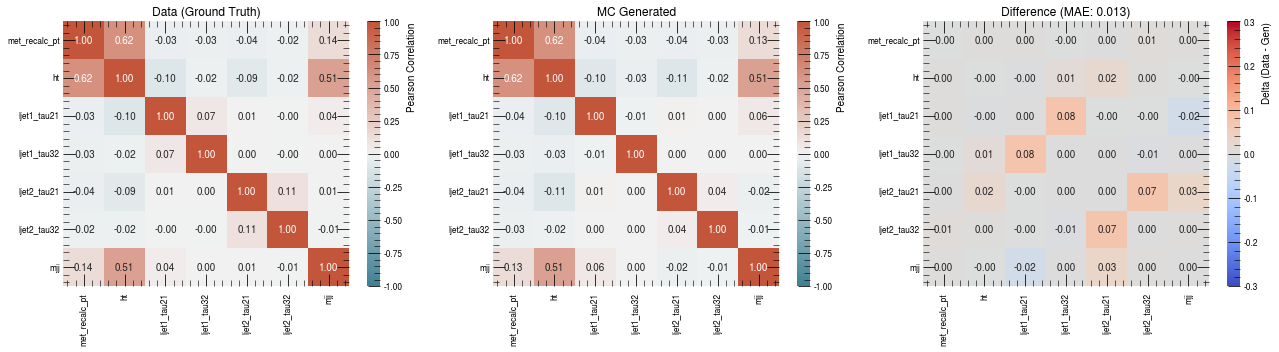

=== Joint Distribution Validation ===
Mean Absolute Error of Correlations: 0.0075
Conclusion: Excellent structural fidelity.


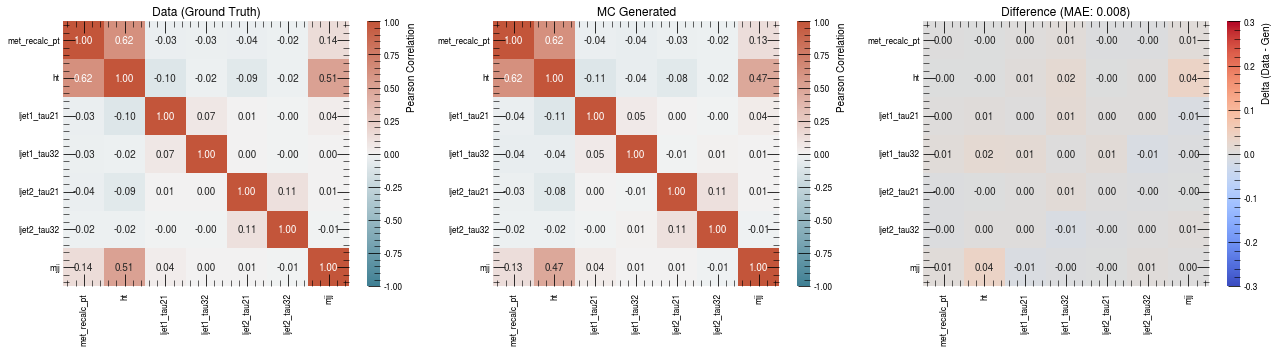

In [17]:
import seaborn as sns

def get_weighted_corr(df, features, weight_col=None):
    """
    Computes a weighted correlation matrix supporting negative weights.
    """
    X = df[features].values
    w = df[weight_col].values if weight_col else np.ones(len(df))
    
    sum_w = np.sum(w)
    if sum_w == 0:
        raise ValueError("Total sum of weights cannot be exactly zero.")
        
    # 1. Compute weighted means
    # w[:, None] reshapes (N,) to (N, 1) so it broadcasts across features
    mean = np.sum(X * w[:, None], axis=0) / sum_w
    
    # 2. Mean-center the features
    X_centered = X - mean
    
    # 3. Compute the weighted covariance matrix 
    # (w * X_centered.T) multiplies each row by its weight before the dot product
    cov_matrix = np.dot(w * X_centered.T, X_centered) / sum_w
    
    # 4. Convert covariance to correlation matrix: R_ij = Cov_ij / sqrt(Cov_ii * Cov_jj)
    std_devs = np.sqrt(np.diag(cov_matrix))
    
    # Suppress warnings for potential division by zero (e.g., zero variance features)
    with np.errstate(divide='ignore', invalid='ignore'):
        corr_matrix = cov_matrix / np.outer(std_devs, std_devs)
        # Clean up any NaNs caused by dividing by zero
        corr_matrix[np.isnan(corr_matrix)] = 0.0
        
    return pd.DataFrame(corr_matrix, index=features, columns=features)

def evaluate_correlations(df_data, df_mc_gen, features, weight_col):
    # 1. Compute matrices
    corr_data = get_weighted_corr(df_data, features)
    corr_gen = get_weighted_corr(df_mc_gen, features, weight_col)
    
    # 2. Compute Difference Matrix
    delta_corr = corr_data - corr_gen
    
    # 3. Calculate Quantitative Metric (MAE of off-diagonal elements)
    # We subtract the identity matrix to ignore the self-correlations (which are always exactly 1)
    np_delta = delta_corr.values
    off_diagonal_mask = ~np.eye(np_delta.shape[0], dtype=bool)
    mae_diff = np.mean(np.abs(np_delta[off_diagonal_mask]))
    
    print("=== Joint Distribution Validation ===")
    print(f"Mean Absolute Error of Correlations: {mae_diff:.4f}")
    if mae_diff < 0.05:
        print("Conclusion: Excellent structural fidelity.")
    elif mae_diff < 0.10:
        print("Conclusion: Minor correlation degradation, generally acceptable.")
    else:
        print("Conclusion: WARNING - Severe relationship breakdown detected.")
    
    # 4. Plot Heatmaps
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Common settings for the standard correlation plots
    cmap_std = sns.diverging_palette(220, 20, as_cmap=True)
    
    sns.heatmap(corr_data, annot=True, fmt=".2f", cmap=cmap_std, vmin=-1, vmax=1, 
                ax=axes[0], cbar_kws={'label': 'Pearson Correlation'})
    axes[0].set_title("Data (Ground Truth)")
    
    sns.heatmap(corr_gen, annot=True, fmt=".2f", cmap=cmap_std, vmin=-1, vmax=1, 
                ax=axes[1], cbar_kws={'label': 'Pearson Correlation'})
    axes[1].set_title("MC Generated")
    
    # The difference plot uses a colormap centered strictly on zero to highlight errors
    sns.heatmap(delta_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-0.3, vmax=0.3, 
                ax=axes[2], cbar_kws={'label': 'Delta (Data - Gen)'})
    axes[2].set_title(f"Difference (MAE: {mae_diff:.3f})")
    
    plt.tight_layout()
    plt.show()

# Run the correlation evaluation
evaluate_correlations(df_data_unscaled, df_mc_gen_clean, context_vars + features_vars, GEN_WEIGHT_COL)
evaluate_correlations(df_data_unscaled, df_mc_rw_clean, context_vars + features_vars, RW_WEIGHT_COL)

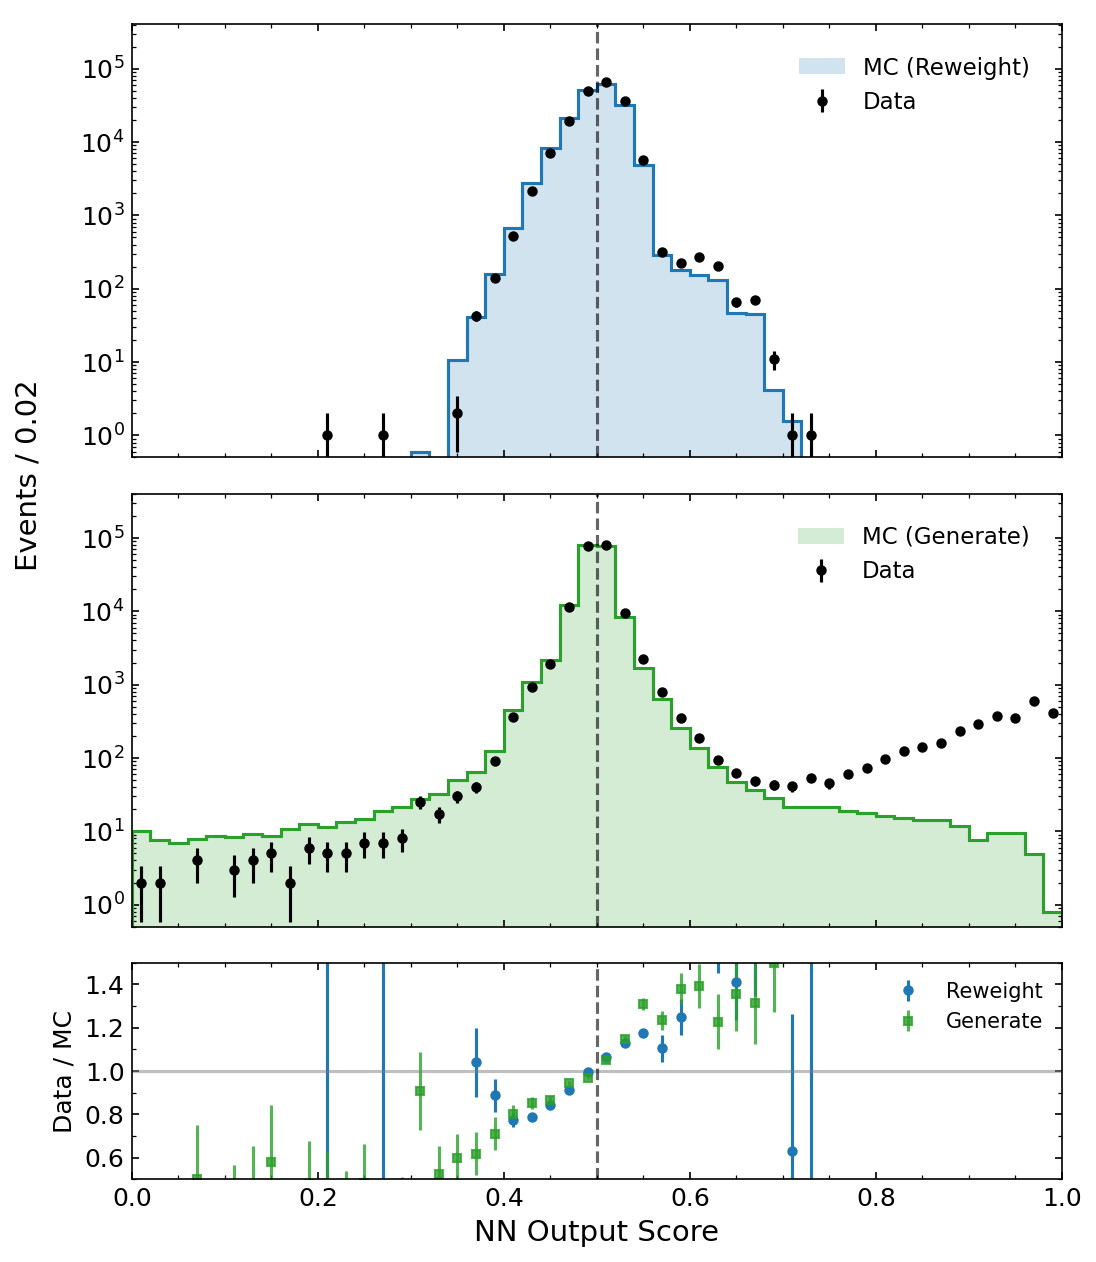

In [40]:
# ==============================================================================
# 1. Data Assignment (Replace with your actual DataFrames)
# ==============================================================================
RW_Scores = df_mc_rw_clean["score_vs_reweighted_data"]
RW_weights = df_mc_rw_clean["rw_mediam_weights"]
RW_Data_Scores = df_data_unscaled["score_vs_reweighted"]

GEN_Scores = df_mc_gen_clean["score_vs_data"]
GEN_weights = df_mc_gen_clean["total_weight"]
GEN_Data_Scores = df_data_unscaled["score_vs_generate"]


# ==============================================================================
# 2. Statistical Helper Function (Yields)
# ==============================================================================
def get_events_hist_and_err(data, bins, weights=None):
    counts, _ = np.histogram(data, bins=bins, weights=weights)
    if weights is None:
        err2 = counts
    else:
        err2, _ = np.histogram(data, bins=bins, weights=weights**2)
    err = np.sqrt(err2)
    return counts, err

# ==============================================================================
# 3. HEP Style Setup & Layout (Stacked Vertical)
# ==============================================================================
plt.style.use('default')
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "lines.linewidth": 1.5,
    "legend.frameon": False,
    "legend.fontsize": 11
})

bins = np.linspace(0.0, 1.0, 51)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

# Adjusted figure size for vertical stacking
fig = plt.figure(figsize=(8, 10), dpi=150)

# 3 Rows, 1 Column: Top (Main 1), Middle (Main 2), Bottom (Combined Ratio)
gs = gridspec.GridSpec(3, 1, height_ratios=[3, 3, 1.5], hspace=0.1)

ax0_main = fig.add_subplot(gs[0])
# Share X and Y axes for the main plots so they are directly comparable
ax1_main = fig.add_subplot(gs[1], sharex=ax0_main, sharey=ax0_main) 
ax_ratio = fig.add_subplot(gs[2], sharex=ax0_main)

# ==============================================================================
# 4. Plot 1: Reweighted Model vs Data (Top Pad)
# ==============================================================================
rw_mc_counts, rw_mc_err = get_events_hist_and_err(RW_Scores, bins, RW_weights)
rw_data_counts, rw_data_err = get_events_hist_and_err(RW_Data_Scores, bins)

ax0_main.hist(bins[:-1], bins=bins, weights=rw_mc_counts, histtype="stepfilled", 
              alpha=0.2, color="tab:blue", label="MC (Reweight)")
ax0_main.hist(bins[:-1], bins=bins, weights=rw_mc_counts, histtype="step", 
              color="tab:blue", linewidth=1.5)
ax0_main.errorbar(bin_centers, rw_data_counts, yerr=rw_data_err, fmt='ko', 
                  markersize=4, capsize=0, label="Data")

with np.errstate(divide='ignore', invalid='ignore'):
    ratio_rw = rw_data_counts / rw_mc_counts
    ratio_rw_err = rw_data_err / rw_mc_counts

# ==============================================================================
# 5. Plot 2: Generative Model vs Data (Middle Pad)
# ==============================================================================
gen_mc_counts, gen_mc_err = get_events_hist_and_err(GEN_Scores, bins, GEN_weights)
gen_data_counts, gen_data_err = get_events_hist_and_err(GEN_Data_Scores, bins)

ax1_main.hist(bins[:-1], bins=bins, weights=gen_mc_counts, histtype="stepfilled", 
              alpha=0.2, color="tab:green", label="MC (Generate)")
ax1_main.hist(bins[:-1], bins=bins, weights=gen_mc_counts, histtype="step", 
              color="tab:green", linewidth=1.5)
ax1_main.errorbar(bin_centers, gen_data_counts, yerr=gen_data_err, fmt='ko', 
                  markersize=4, capsize=0, label="Data")

with np.errstate(divide='ignore', invalid='ignore'):
    ratio_gen = gen_data_counts / gen_mc_counts
    ratio_gen_err = gen_data_err / gen_mc_counts

# ==============================================================================
# 6. Combined Ratio Plot (Bottom Pad)
# ==============================================================================
# Plot Reweighted Ratio (Blue dots)
ax_ratio.errorbar(bin_centers, ratio_rw, yerr=ratio_rw_err, fmt='o', 
                  color='tab:blue', markersize=4, capsize=0, label='Reweight')

# Plot Generative Ratio (Green squares to distinguish from dots)
ax_ratio.errorbar(bin_centers, ratio_gen, yerr=ratio_gen_err, fmt='s', 
                  color='tab:green', markersize=4, capsize=0, alpha=0.8, label='Generate')

# ==============================================================================
# 7. Formatting & Aesthetics
# ==============================================================================
for ax in [ax0_main, ax1_main]:
    ax.set_yscale("log")
    ax.set_xlim(0, 1)
    # ax.set_ylabel(f"Events / {bin_width:.2f}")
    
    # Calculate global limits across both datasets so the shared Y-axis fits everything
    valid_mc = np.concatenate([rw_mc_counts[rw_mc_counts > 0], gen_mc_counts[gen_mc_counts > 0]])
    valid_data = np.concatenate([rw_data_counts[rw_data_counts > 0], gen_data_counts[gen_data_counts > 0]])
    ymin = max(min(valid_mc.min() if len(valid_mc) else 1, 
                   valid_data.min() if len(valid_data) else 1) * 0.5, 0.5)
    ymax = max(rw_data_counts.max(), gen_data_counts.max()) * 5
    ax.set_ylim(ymin, ymax)
            
    ax.legend(loc="upper right", borderaxespad=1.0)
    ax.minorticks_on()
    
    # Add vertical dashed line at 0.5
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.6)
    
    # Hide X-axis tick labels for main plots (since they are stacked above the ratio)
    plt.setp(ax.get_xticklabels(), visible=False)

# Format the Combined Ratio plot
ax_ratio.set_xlim(0, 1)
ax_ratio.set_ylim(0.5, 1.5)
ax_ratio.set_ylabel("Data / MC", fontsize=12)
ax_ratio.set_xlabel("NN Output Score")
ax_ratio.axhline(1.0, color='gray', linestyle='-', alpha=0.5)
ax_ratio.axvline(0.5, color='black', linestyle='--', alpha=0.6)
ax_ratio.minorticks_on()
# Create an invisible axis spanning the top two main plots (rows 0 and 1)
ax_common_y = fig.add_subplot(gs[0:2], frameon=False)

# Hide ticks and tick labels for the invisible axis
ax_common_y.tick_params(labelcolor='none', which='both', 
                        top=False, bottom=False, left=False, right=False)

# Set the single centered Y-axis label
ax_common_y.set_ylabel(f"Events / {bin_width:.2f}", fontsize=14, labelpad=20)
# Clean up ratio y-ticks
ax_ratio.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax_ratio.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
yticks = ax_ratio.yaxis.get_major_ticks()
if len(yticks) > 0:
    yticks[-1].label1.set_visible(False) # Prevent top label overlapping

# Add legend to the combined ratio plot
ax_ratio.legend(loc="upper right", ncol=1, frameon=False, fontsize=10)
plt.savefig("Results/Bkg_scores.pdf")
plt.show()

In [9]:
# # Background Efficiency
# # [0.20, 0.10, 0.05, 0.03, 0.02, 0.01, 0.005, 0.001]
# bkg_eff = 0.001

## Phase 1 (Background Only)

In [10]:
def apply_hybrid_cut(df_data, df_bkg, bkg_type, target_eff=0.01):
    """
    Finds the NN score threshold for the top X% of background and cuts both datasets.
    Uses predefined column configurations based on bkg_type ('NOM', 'RW', or 'GEN').
    """
    
    # 1. Map column names based on background type
    if bkg_type == "NOM":
        data_score_col = "score_vs_nominal"
        bkg_score_col = "score_vs_data"
        weight_col = "final_weight"
    elif bkg_type == "RW":
        data_score_col = "score_vs_reweighted"
        bkg_score_col = "score_vs_reweighted_data"
        weight_col = "rw_mediam_weights"
    elif bkg_type == "GEN":
        data_score_col = "score_vs_generate"
        bkg_score_col = "score_vs_data"
        weight_col = "total_weight"
    else:
        raise ValueError("bkg_type must be 'NOM', 'RW', or 'GEN'")

    # 2. Extract scores and weights
    bkg_scores = df_bkg[bkg_score_col].values
    bkg_weights = df_bkg[weight_col].values

    # 3. Sort to find the exact threshold based on weights
    sort_idx = np.argsort(bkg_scores)
    sorted_scores = bkg_scores[sort_idx]
    sorted_weights = np.abs(bkg_weights[sort_idx])
    
    cum_weights = np.cumsum(sorted_weights)
    if cum_weights[-1] == 0:
        raise ValueError("Total background weight is zero. Cannot compute threshold.")
        
    cum_weights_norm = cum_weights / cum_weights[-1]

    # 4. Find threshold for the target efficiency
    threshold_idx = np.searchsorted(cum_weights_norm, 1.0 - target_eff)
    
    # Protect against out-of-bounds index
    if threshold_idx >= len(sorted_scores):
        threshold_idx = len(sorted_scores) - 1
        
    threshold = sorted_scores[threshold_idx]
    
    print(f"--- {bkg_type} Cut ---")
    print(f"Applying cut at NN Score > {threshold:.4f} (Top {target_eff*100:.1f}% Background)")

    # 5. Filter and return new datasets
    data_sr = df_data[df_data[data_score_col] > threshold].copy()
    bkg_sr = df_bkg[df_bkg[bkg_score_col] > threshold].copy()
    
    return data_sr, bkg_sr, threshold

In [11]:
# Check inclusive pre-cut yields in the Signal Region
total_data_pre_cut = len(df_data_unscaled)
total_gen_pre_cut = df_mc_gen_unscaled['total_weight'].sum()
total_rw_pre_cut = df_mc_rw_unscaled['rw_mediam_weights'].sum()
total_nom_pre_cut = df_mc_rw_unscaled['final_weight'].sum()

print("="*20,"Pre-Cut Yields in Signal Region:", "="*20)

print(f"Pre-Cut Data Yield: {total_data_pre_cut}")
print(f"Pre-Cut GEN Yield:  {total_gen_pre_cut:.2f}")
print(f"Pre-Cut RW Yield:   {total_rw_pre_cut:.2f}")
print(f"Pre-Cut NOM Yield:  {total_nom_pre_cut:.2f}")
print(f"Pre-Cut Ratio (Data/GEN):      {total_data_pre_cut / total_gen_pre_cut:.2f}")
print(f"Pre-Cut Ratio (Data/RW):       {total_data_pre_cut / total_rw_pre_cut:.2f}")
print(f"Pre-Cut Ratio (Data/NOM):      {total_data_pre_cut / total_nom_pre_cut:.2f}")

==================== Pre-Cut Yields in Signal Region: ====================
Pre-Cut Data Yield: 188757
Pre-Cut GEN Yield:  183843.73
Pre-Cut RW Yield:   183495.26
Pre-Cut NOM Yield:  185438.64
Pre-Cut Ratio (Data/GEN):      1.03
Pre-Cut Ratio (Data/RW):       1.03
Pre-Cut Ratio (Data/NOM):      1.02


### CHECK BACKGROUND MODELLING

In [12]:
def plot_corr_diff(corr_data, corr_bkg, corr_diff, bkg_type, bkg_eff=0.01):

    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    
    # Use colorblind-friendly and grayscale-safe colormaps
    cmap_corr = 'RdBu_r' 
    cmap_diff = 'PiYG'
    
    labels = [r'$m_{jj}$', r'Jet 1 $\tau_{21}$', r'Jet 1 $\tau_{32}$', r'Jet 2 $\tau_{21}$', r'Jet 2 $\tau_{32}$']

    # Control text sizes inside the heatmap boxes and colorbar proportions
    annot_kws = {"size": 16} 
    cbar_kws = {"fraction": 0.046, "pad": 0.04}

    # -- Panel 1: Data Correlation
    sns.heatmap(corr_data, ax=axes[0], annot=True, fmt=".2f", cmap=cmap_corr, vmin=-1, vmax=1, 
                xticklabels=labels, yticklabels=labels, annot_kws=annot_kws, cbar_kws=cbar_kws)
    axes[0].set_title("Data (Top 1% NN Score)", pad=15, fontsize=20)

    # -- Panel 2: Background Correlation
    sns.heatmap(corr_bkg, ax=axes[1], annot=True, fmt=".2f", cmap=cmap_corr, vmin=-1, vmax=1, 
                xticklabels=labels, yticklabels=labels, annot_kws=annot_kws, cbar_kws=cbar_kws)
    axes[1].set_title(f"{bkg_type} Model (Top {bkg_eff:.2%} NN Score)", pad=15, fontsize=20)

    # -- Panel 3: Difference
    sns.heatmap(corr_diff, ax=axes[2], annot=True, fmt=".2f", cmap=cmap_diff, vmin=-0.5, vmax=0.5, 
                xticklabels=labels, yticklabels=labels, annot_kws=annot_kws, cbar_kws=cbar_kws)
    axes[2].set_title(f"Difference (Data - {bkg_type})", pad=15, fontsize=20)

    # Apply HEP-specific axis formatting
    for ax in axes:
        # Rotate x-axis labels to prevent overlap with the larger fonts
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        
        # Enforce inward-facing ticks on all sides (standard HEP style)
        ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

    plt.tight_layout()
    plt.show()

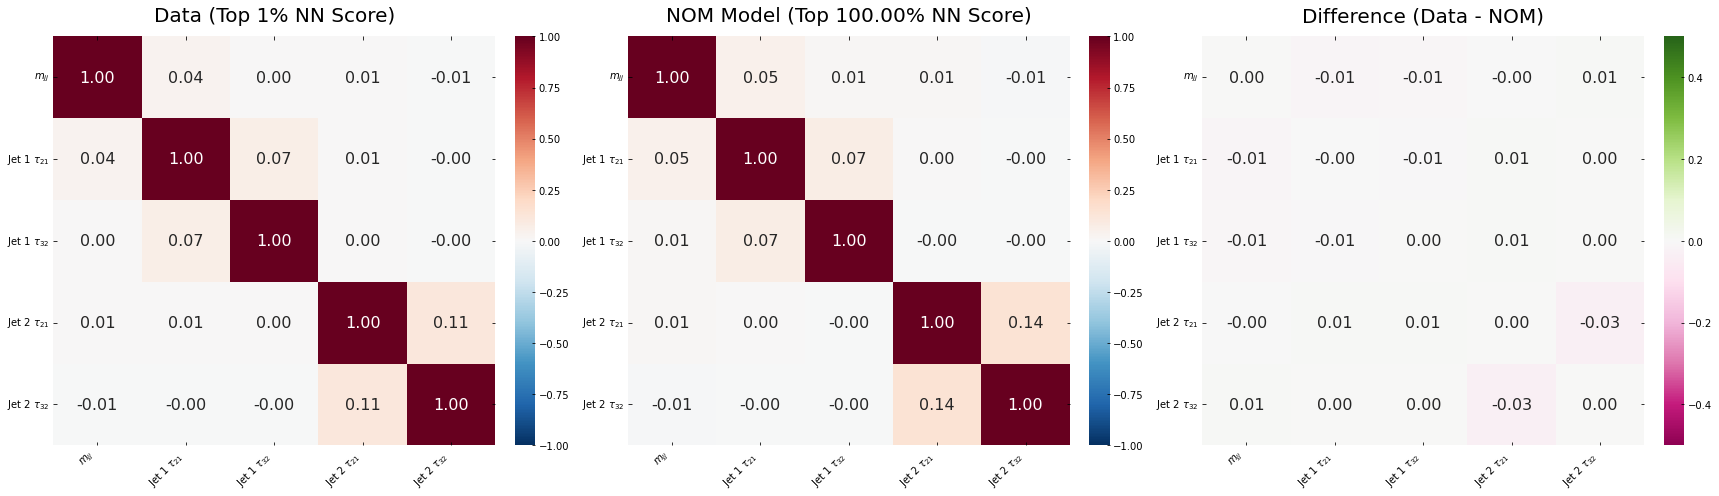

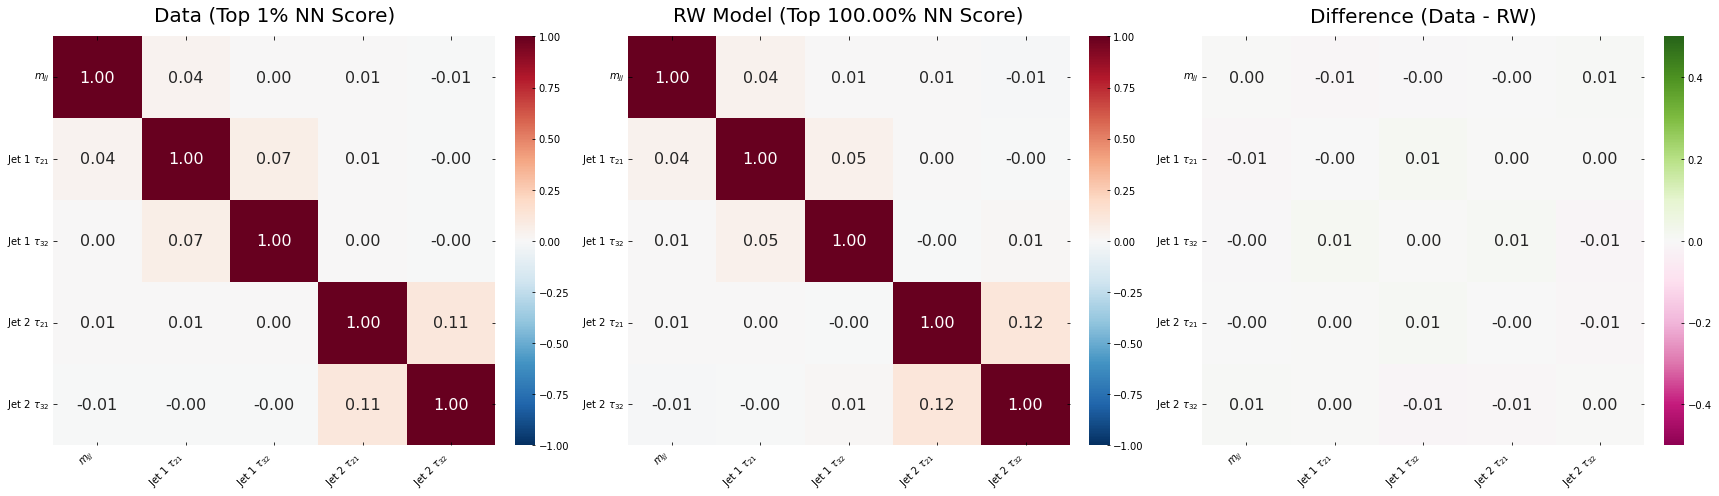

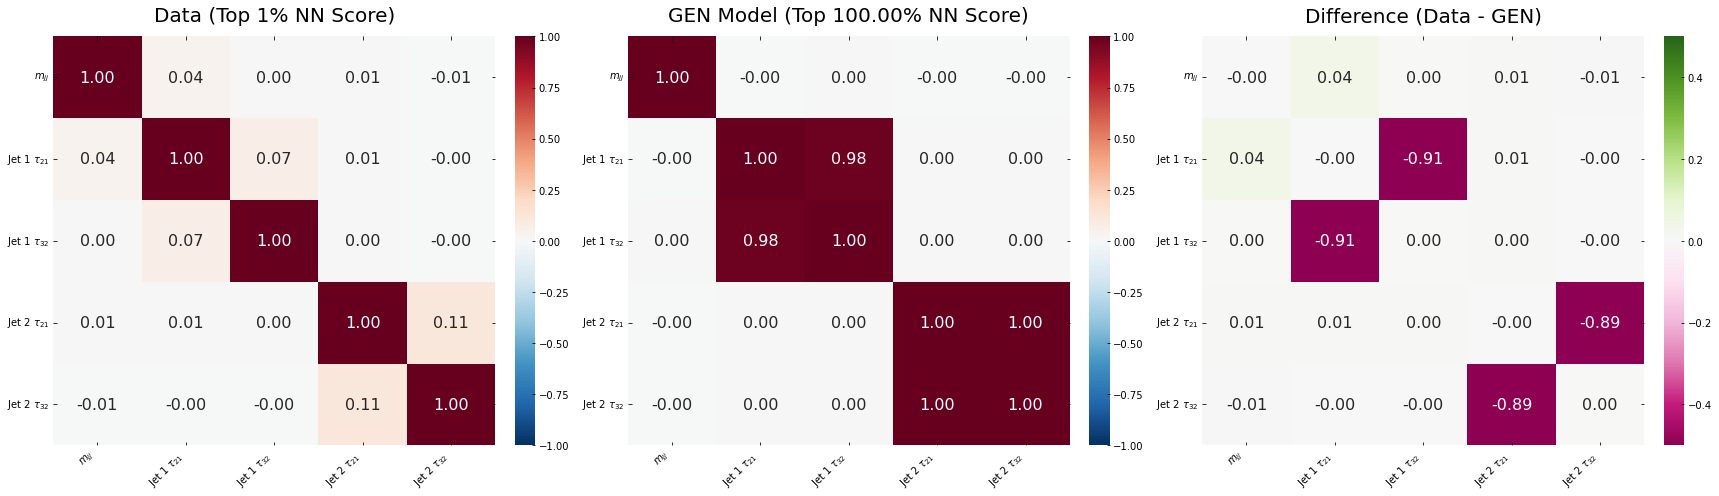

In [13]:
def get_weighted_correlation(df, features, weight_col):
    """Calculates the weighted Pearson correlation matrix."""
    # Extract arrays
    X = df[features].values
    w = df[weight_col].values
    w = np.abs(w)  # Ensure weights are non-negative
    # Calculate weighted covariance matrix (rowvar=False means columns are variables)
    cov_matrix = np.cov(X, rowvar=False, aweights=w)
    
    # Convert covariance to correlation matrix
    std_devs = np.sqrt(np.diag(cov_matrix))
    corr_matrix = cov_matrix / np.outer(std_devs, std_devs)
    
    return corr_matrix


features_list = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']

# For Data, assume weight is 1.0 for all events if unweighted
if 'weight' not in df_data_unscaled.columns:
    df_data_unscaled['weight'] = 1.0

# Full Uncut correlations
corr_data = get_weighted_correlation(df_data_unscaled, features_list, 'weight')
corr_nom = get_weighted_correlation(df_mc_rw_unscaled, features_list, 'final_weight')
corr_rw = get_weighted_correlation(df_mc_rw_unscaled, features_list, 'rw_mediam_weights')
corr_gen = get_weighted_correlation(df_mc_gen_unscaled, features_list, 'total_weight')

corr_diff_nom_full = corr_data - corr_nom
corr_diff_rw_full = corr_data - corr_rw
corr_diff_gen_full = corr_data - corr_gen

plot_corr_diff(corr_data, corr_nom, corr_diff_nom_full, bkg_type="NOM", bkg_eff=1.0)
plot_corr_diff(corr_data, corr_rw, corr_diff_rw_full, bkg_type="RW", bkg_eff=1.0)
plot_corr_diff(corr_data, corr_gen, corr_diff_gen_full, bkg_type="GEN", bkg_eff=1.0)

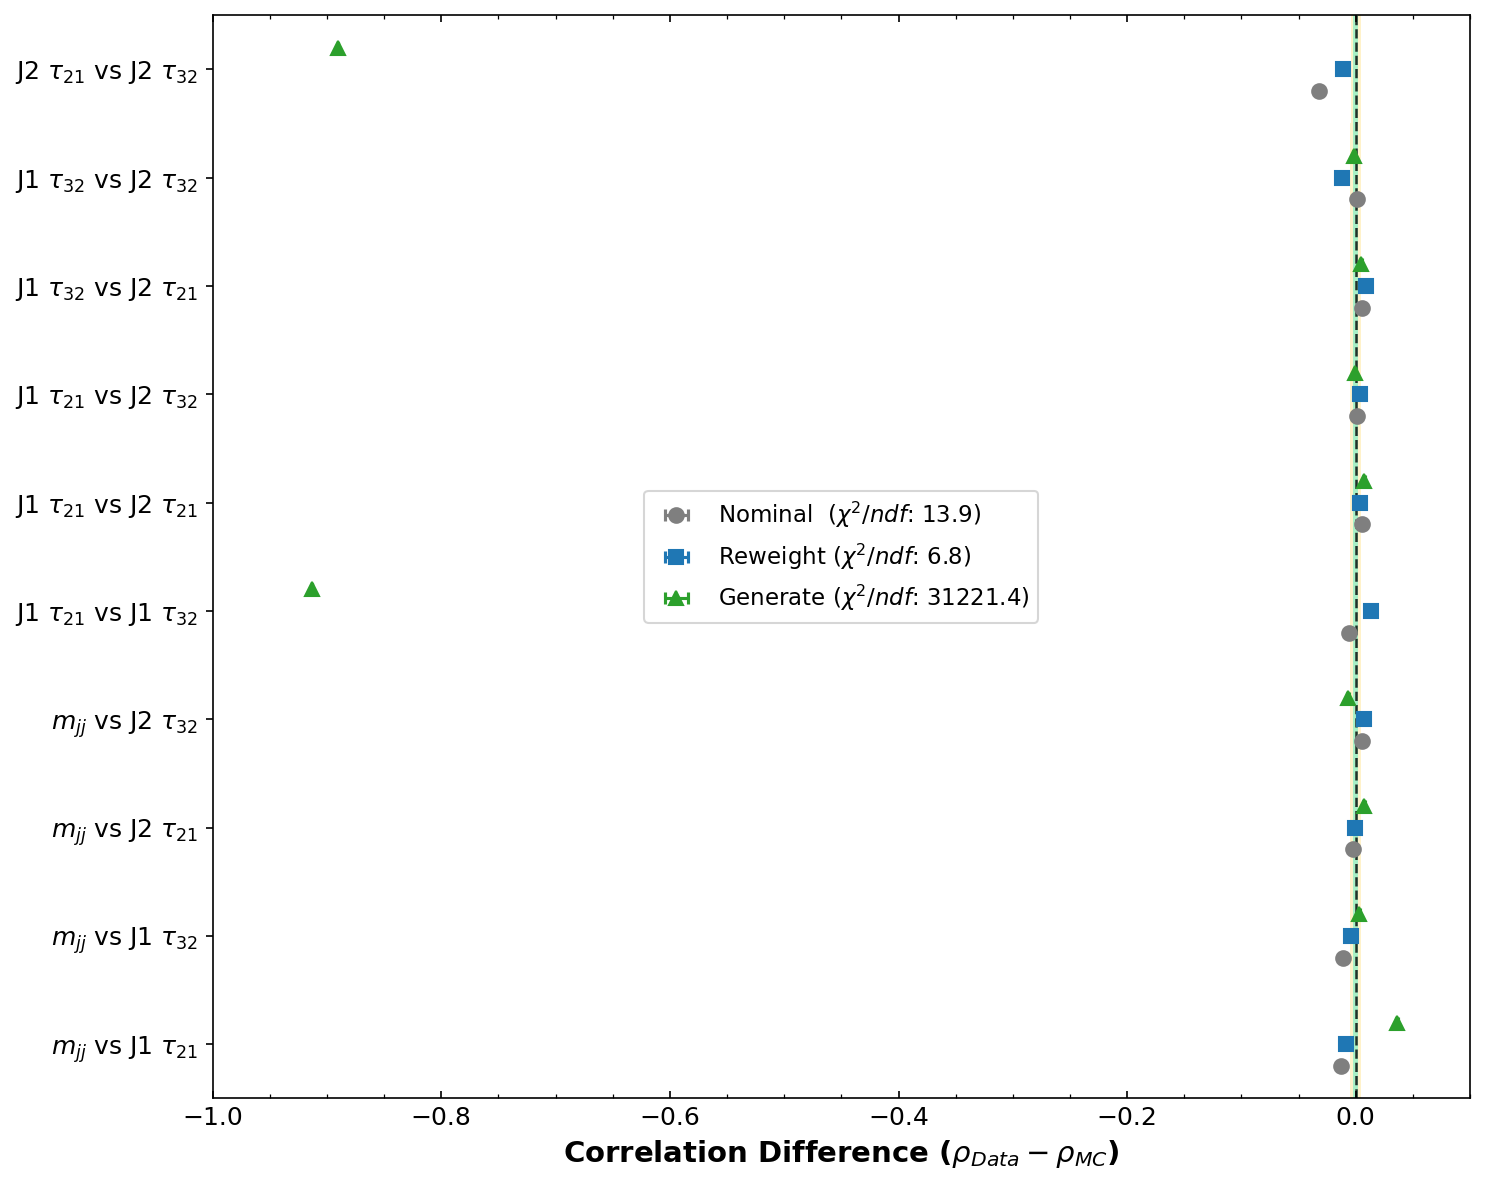


=== Nominal MC ===
chi2 = 139.19  (ndf = 10)
p-value = 6.164e-25
sigma equivalent (one-sided Gaussian) = 10.25
Number of 'failed' pairs (|pull| > 3): 3 / 10
Failed pairs (|pull| > 3):
  - $m_{jj}$ vs J1 $\tau_{21}$: pull = -3.86
  - $m_{jj}$ vs J1 $\tau_{32}$: pull = -3.41
  - J2 $\tau_{21}$ vs J2 $\tau_{32}$: pull = -10.02

=== Reweighted MC ===
chi2 = 68.06  (ndf = 10)
p-value = 1.048e-10
sigma equivalent (one-sided Gaussian) = 6.35
Number of 'failed' pairs (|pull| > 3): 3 / 10
Failed pairs (|pull| > 3):
  - J1 $\tau_{21}$ vs J1 $\tau_{32}$: pull = 4.15
  - J1 $\tau_{32}$ vs J2 $\tau_{32}$: pull = -3.79
  - J2 $\tau_{21}$ vs J2 $\tau_{32}$: pull = -3.59

=== Generative MC ===
chi2 = 312213.60  (ndf = 10)
p-value = 0.000e+00
sigma equivalent (one-sided Gaussian) = inf
Number of 'failed' pairs (|pull| > 3): 3 / 10
Failed pairs (|pull| > 3):
  - $m_{jj}$ vs J1 $\tau_{21}$: pull = 15.10
  - J1 $\tau_{21}$ vs J1 $\tau_{32}$: pull = -398.43
  - J2 $\tau_{21}$ vs J2 $\tau_{32}$: pull = -39

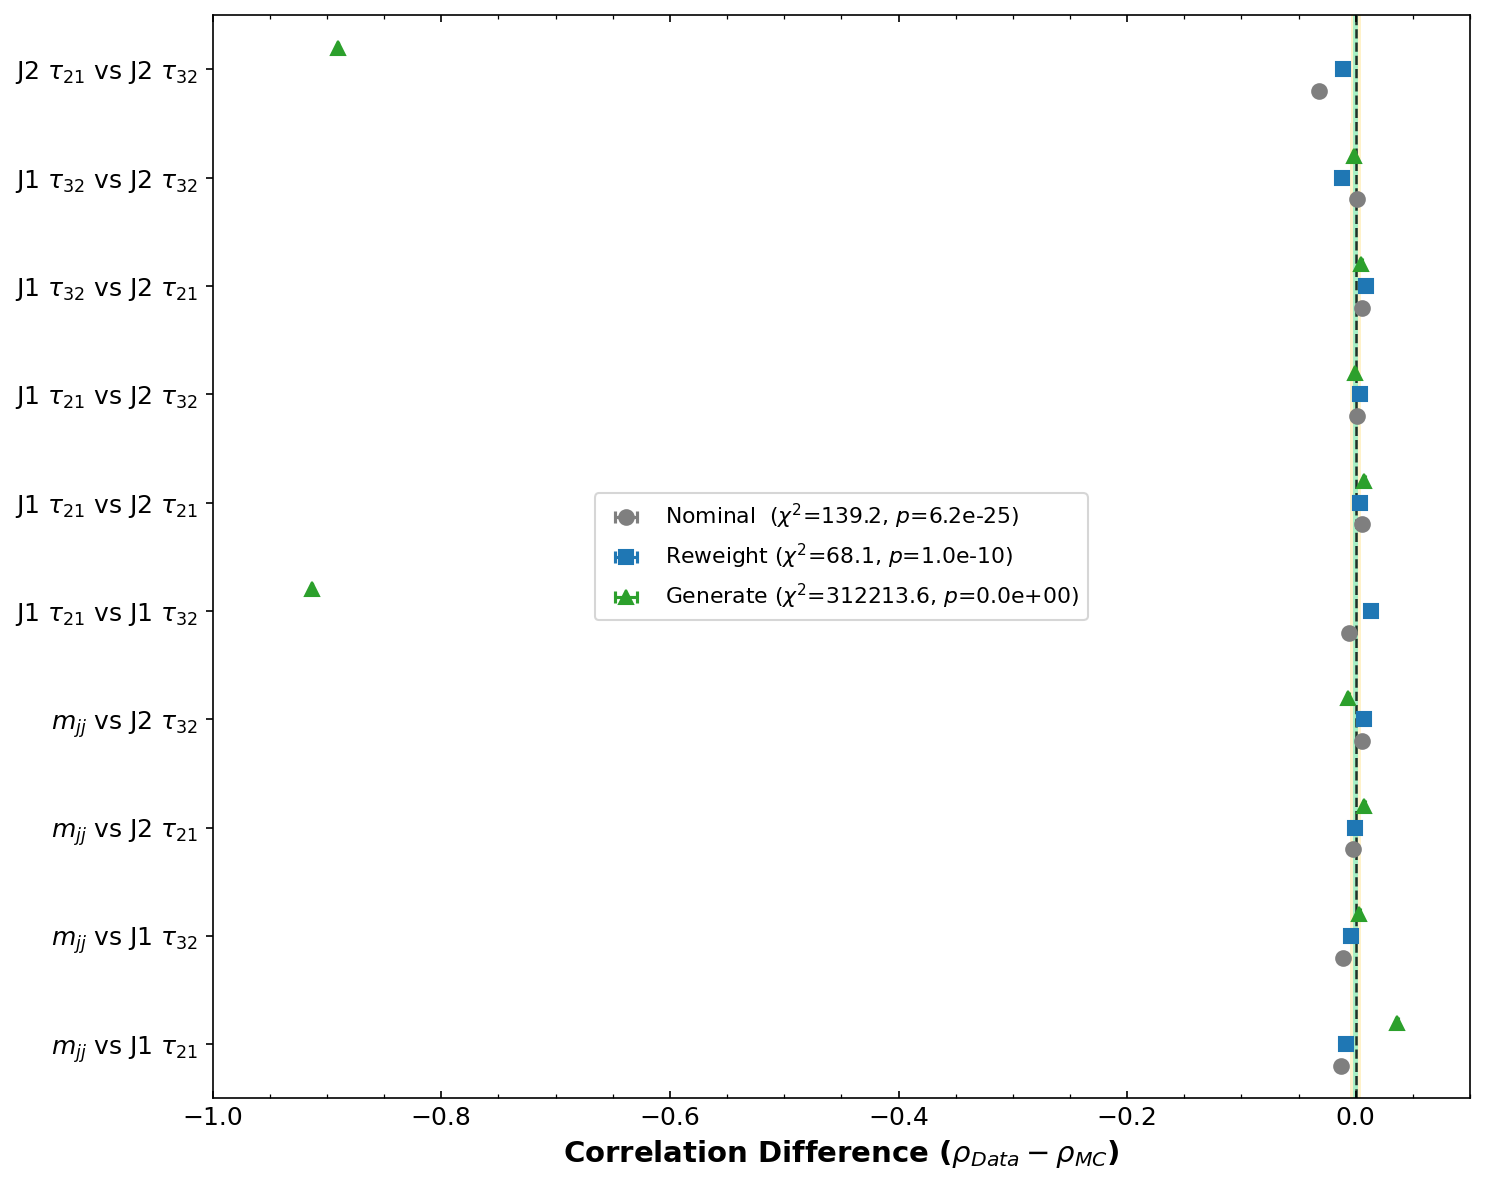

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as mpatches
from scipy.stats import chi2, norm


def get_weighted_correlation(df, features, weight_col):
    """Calculates the weighted Pearson correlation matrix."""
    X = df[features].values
    w = np.abs(df[weight_col].values)
    cov_matrix = np.cov(X, rowvar=False, aweights=w)
    std_devs = np.sqrt(np.diag(cov_matrix))
    return cov_matrix / np.outer(std_devs, std_devs)


def get_neff(df, weight_col):
    """Calculates the Effective Sample Size (N_eff) for weighted events."""
    w = df[weight_col].values
    return np.sum(w)**2 / np.sum(w**2)


def get_correlation_uncertainty(corr_matrix, n_eff):
    """Calculates the standard error matrix for Pearson correlations."""
    # The max(n_eff, 4) prevents division by zero or negative square roots
    return (1 - corr_matrix**2) / np.sqrt(max(n_eff - 3, 1))


# ==============================================================================
# 3. Ensure Data has weights
# ==============================================================================
if 'weight' not in df_data_unscaled.columns:
    df_data_unscaled['weight'] = 1.0


# ==============================================================================
# 4. Calculate Correlations and Uncertainties
# ==============================================================================
# Calculate Correlation Matrices
corr_data = get_weighted_correlation(df_data_unscaled, features_list, 'weight')
corr_nom  = get_weighted_correlation(df_mc_rw_unscaled, features_list, 'final_weight')
corr_rw   = get_weighted_correlation(df_mc_rw_unscaled, features_list, 'rw_mediam_weights')
corr_gen  = get_weighted_correlation(df_mc_gen_unscaled, features_list, 'total_weight')


# Calculate N_eff
neff_data = get_neff(df_data_unscaled, 'weight')
neff_nom  = get_neff(df_mc_rw_unscaled, 'final_weight')
neff_rw   = get_neff(df_mc_rw_unscaled, 'rw_mediam_weights')
neff_gen  = get_neff(df_mc_gen_unscaled, 'total_weight')


# Calculate Statistical Errors for the matrices
err_data = get_correlation_uncertainty(corr_data, neff_data)
err_nom  = get_correlation_uncertainty(corr_nom, neff_nom)
err_rw   = get_correlation_uncertainty(corr_rw, neff_rw)
err_gen  = get_correlation_uncertainty(corr_gen, neff_gen)


# Calculate Differences (Data - MC)
diff_nom = corr_data - corr_nom
diff_rw  = corr_data - corr_rw
diff_gen = corr_data - corr_gen


# ==============================================================================
# 5. Rigorous Publication Plotting Function (Calculated Bands)
# ==============================================================================
def plot_condensed_correlation_with_rigorous_bands():
    labels = [r'$m_{jj}$', r'J1 $\tau_{21}$', r'J1 $\tau_{32}$', r'J2 $\tau_{21}$', r'J2 $\tau_{32}$']
    n_features = len(labels)
    
    pair_names = []
    v_nom, v_rw, v_gen = [], [], []
    
    # Storage for separated errors (Data vs MC)
    e_data = []
    e_nom_mc, e_rw_mc, e_gen_mc = [], [], []
    
    # Unroll the upper triangle of the matrices
    for i in range(n_features):
        for j in range(i + 1, n_features):
            # Changed to a single line since this will now sit horizontally on the Y-axis
            pair_names.append(f"{labels[i]} vs {labels[j]}")
            
            # Values (Differences)
            v_nom.append(diff_nom[i, j])
            v_rw.append(diff_rw[i, j])
            v_gen.append(diff_gen[i, j])
            
            # Pure Data Error (Used for the background tolerance bands)
            e_data.append(err_data[i, j])
            
            # Pure MC Error (Used for the point error bars)
            e_nom_mc.append(err_nom[i, j])
            e_rw_mc.append(err_rw[i, j])
            e_gen_mc.append(err_gen[i, j])


    # Convert to numpy arrays for math
    v_nom, v_rw, v_gen = np.array(v_nom), np.array(v_rw), np.array(v_gen)
    e_data = np.array(e_data)
    e_nom_mc, e_rw_mc, e_gen_mc = np.array(e_nom_mc), np.array(e_rw_mc), np.array(e_gen_mc)


    # Calculate Chi^2 / ndf using COMBINED errors (quadrature sum of Data + MC error)
    comb_e_nom = np.sqrt(e_data**2 + e_nom_mc**2)
    comb_e_rw  = np.sqrt(e_data**2 + e_rw_mc**2)
    comb_e_gen = np.sqrt(e_data**2 + e_gen_mc**2)


    ndf_nom = len(v_nom)
    ndf_rw = len(v_rw)
    ndf_gen = len(v_gen)
    chi2_nom = np.sum((v_nom / comb_e_nom)**2) / ndf_nom
    chi2_rw  = np.sum((v_rw / comb_e_rw)**2) / ndf_rw
    chi2_gen = np.sum((v_gen / comb_e_gen)**2) / ndf_gen
    
    # Format labels for legend
    label_nom = f"Nominal  ($\\chi^2/ndf$: {chi2_nom:.1f})"
    label_rw  = f"Reweight ($\\chi^2/ndf$: {chi2_rw:.1f})"
    label_gen = f"Generate ($\\chi^2/ndf$: {chi2_gen:.1f})"


    # ---- Setup the Plot ----
    plt.style.use('default')
    # Adjusted figsize to be taller than it is wide to accommodate y-axis labels
    fig, ax = plt.subplots(figsize=(10, 8), dpi=150) 
    
    y = np.arange(len(pair_names))
    offset = 0.20 # Offset points vertically so error bars don't overlap
    
    # ---------------------------------------------------------
    # PLOT THE MATHEMATICALLY DERIVED TOLERANCE BANDS
    # ---------------------------------------------------------
    # Expand the y-coordinates slightly past the edge points
    y_band = np.concatenate([[-0.5], y, [len(y)-0.5]])
    
    # Duplicate the edge errors to match the expanded y-coordinates
    x_band_1sigma = np.concatenate([[e_data[0]], e_data, [e_data[-1]]])
    x_band_2sigma = x_band_1sigma * 2


    # Plot 2 Sigma Band (Lighter yellow) using fill_betweenx
    ax.fill_betweenx(y_band, -x_band_2sigma, x_band_2sigma, step='mid', 
                     color='#ffeaa7', alpha=0.6, linewidth=0)
    
    # Plot 1 Sigma Band (Darker teal/green) using fill_betweenx
    ax.fill_betweenx(y_band, -x_band_1sigma, x_band_1sigma, step='mid', 
                     color='#55efc4', alpha=0.5, linewidth=0)


    # Zero line (Perfect Agreement) mapped to a vertical line
    ax.axvline(0, color='black', linestyle='--', alpha=0.8, linewidth=1.2)


    # ---------------------------------------------------------
    # PLOT THE MC POINTS (WITH MC-ONLY ERROR BARS)
    # ---------------------------------------------------------
    # Swapped inputs (v_nom is x, y is y) and changed yerr to xerr
    ax.errorbar(v_nom, y - offset, xerr=e_nom_mc, fmt='o', color='tab:gray', 
                markersize=7, capsize=3, capthick=1.5, elinewidth=1.5, label=label_nom)
                
    ax.errorbar(v_rw, y, xerr=e_rw_mc, fmt='s', color='tab:blue', 
                markersize=7, capsize=3, capthick=1.5, elinewidth=1.5, label=label_rw)
                
    ax.errorbar(v_gen, y + offset, xerr=e_gen_mc, fmt='^', color='tab:green', 
                markersize=7, capsize=3, capthick=1.5, elinewidth=1.5, label=label_gen)


    # ---- Aesthetics and Formatting ----
    ax.set_yticks(y)
    ax.set_yticklabels(pair_names, fontsize=12)
    ax.set_xlabel(r"Correlation Difference ($\rho_{Data} - \rho_{MC}$)", fontsize=14, fontweight='bold')
    
    # Swapped limits
    ax.set_xlim(-1, 0.1) 
    ax.set_ylim(-0.5, len(y) - 0.5)
    
    # Standard HEP tick formatting (adjusted for x-axis)
    ax.tick_params(axis='x', which='both', direction='in', top=True, labelsize=12)
    ax.minorticks_on()
    ax.yaxis.set_minor_locator(plt.NullLocator()) # Turn off minor ticks on y-axis
    
    # ---- Custom Legend ----
    handles, legend_labels = ax.get_legend_handles_labels()
    
    # patch_1sigma = mpatches.Patch(color='#55efc4', alpha=0.5, label='Data Stat. Unc. ($\pm 1\sigma$)')
    # patch_2sigma = mpatches.Patch(color='#ffeaa7', alpha=0.6, label='Data Stat. Unc. ($\pm 2\sigma$)')
    
    # handles.extend([patch_1sigma, patch_2sigma])
    
    # Moved bbox_to_anchor slightly higher (1.12) to clear the top area
    ax.legend(loc='center', 
              frameon=True, fontsize=11, ncol=1)
    
    plt.tight_layout()
    plt.show()


# ==============================================================================
# 6. Execute Original Plot
# ==============================================================================
plot_condensed_correlation_with_rigorous_bands()


# ==============================================================================
# 7. Additional Statistics: Global chi2, p-value, sigma, and per-pair pulls
# ==============================================================================
def correlation_agreement_stats(v_diff, e_comb):
    """
    Compute global chi2, p-value, sigma-equivalent, and per-pair pulls.

    Parameters
    ----------
    v_diff : np.ndarray
        Vector of correlation differences (rho_Data - rho_MC) for all pairs.
    e_comb : np.ndarray
        Vector of combined uncertainties sqrt(e_data^2 + e_MC^2) for all pairs.

    Returns
    -------
    stats : dict
        Dictionary with:
          - 'chi2': float
          - 'ndf': int
          - 'p_value': float
          - 'sigma_equiv': float (one-sided Gaussian equivalent)
          - 'pulls': np.ndarray
          - 'failed_pairs_mask': np.ndarray (bool)
    """
    pulls = v_diff / e_comb
    chi2_val = np.sum(pulls**2)
    ndf = len(v_diff)
    p_val = chi2.sf(chi2_val, df=ndf)
    # One-sided Gaussian sigma equivalent
    sigma_eq = norm.isf(p_val)

    # Define "failed" pairs as |pull| > 3 (adjust threshold if desired)
    failed_mask = np.abs(pulls) > 3.0

    return {
        "chi2": chi2_val,
        "ndf": ndf,
        "p_value": p_val,
        "sigma_equiv": sigma_eq,
        "pulls": pulls,
        "failed_pairs_mask": failed_mask
    }


# ==============================================================================
# 8. Rebuild vectors for stats (same logic as in the plot function)
# ==============================================================================
labels = [r'$m_{jj}$', r'J1 $\tau_{21}$', r'J1 $\tau_{32}$', r'J2 $\tau_{21}$', r'J2 $\tau_{32}$']
n_features = len(labels)

pair_names = []
v_nom, v_rw, v_gen = [], [], []

e_data = []
e_nom_mc, e_rw_mc, e_gen_mc = [], [], []

for i in range(n_features):
    for j in range(i + 1, n_features):
        pair_names.append(f"{labels[i]} vs {labels[j]}")
        
        v_nom.append(diff_nom[i, j])
        v_rw.append(diff_rw[i, j])
        v_gen.append(diff_gen[i, j])
        
        e_data.append(err_data[i, j])
        e_nom_mc.append(err_nom[i, j])
        e_rw_mc.append(err_rw[i, j])
        e_gen_mc.append(err_gen[i, j])

v_nom, v_rw, v_gen = np.array(v_nom), np.array(v_rw), np.array(v_gen)
e_data = np.array(e_data)
e_nom_mc, e_rw_mc, e_gen_mc = np.array(e_nom_mc), np.array(e_rw_mc), np.array(e_gen_mc)

comb_e_nom = np.sqrt(e_data**2 + e_nom_mc**2)
comb_e_rw  = np.sqrt(e_data**2 + e_rw_mc**2)
comb_e_gen = np.sqrt(e_data**2 + e_gen_mc**2)


# ==============================================================================
# 9. Compute Stats for Nominal, Reweight, and Generative
# ==============================================================================
stats_nom = correlation_agreement_stats(v_nom, comb_e_nom)
stats_rw  = correlation_agreement_stats(v_rw,  comb_e_rw)
stats_gen = correlation_agreement_stats(v_gen, comb_e_gen)


# ==============================================================================
# 10. Print HEP-style Summary
# ==============================================================================
def print_agreement_summary(label, stats, pair_names):
    print(f"\n=== {label} ===")
    print(f"chi2 = {stats['chi2']:.2f}  (ndf = {stats['ndf']})")
    print(f"p-value = {stats['p_value']:.3e}")
    print(f"sigma equivalent (one-sided Gaussian) = {stats['sigma_equiv']:.2f}")

    n_failed = int(np.sum(stats['failed_pairs_mask']))
    print(f"Number of 'failed' pairs (|pull| > 3): {n_failed} / {len(pair_names)}")

    if n_failed > 0:
        print("Failed pairs (|pull| > 3):")
        failed_indices = np.where(stats['failed_pairs_mask'])[0]
        for idx in failed_indices:
            print(
                f"  - {pair_names[idx]}: "
                f"pull = {stats['pulls'][idx]:.2f}"
            )


print_agreement_summary("Nominal MC", stats_nom, pair_names)
print_agreement_summary("Reweighted MC", stats_rw, pair_names)
print_agreement_summary("Generative MC", stats_gen, pair_names)


# ==============================================================================
# 11. Optional: Pull Histograms (for visual diagnostics)
# ==============================================================================
def plot_pull_histograms():
    plt.style.use('default')
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=150)

    labels_str = ["Nominal", "Reweight", "Generative"]
    stats_list = [stats_nom, stats_rw, stats_gen]
    colors = ["tab:gray", "tab:blue", "tab:green"]

    for ax, stats, label, col in zip(axes, stats_list, labels_str, colors):
        pulls = stats["pulls"]
        ax.hist(pulls, bins=30, color=col, alpha=0.7, edgecolor='black', label=label)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.axvline(3, color='red', linestyle=':', linewidth=1, label='|pull| = 3')
        ax.axvline(-3, color='red', linestyle=':', linewidth=1)

        ax.set_xlabel("Pull = (ρ_Data - ρ_MC) / σ_Δρ", fontsize=12)
        ax.set_ylabel("Number of pairs", fontsize=12)
        ax.set_title(f"{label} MC pulls", fontsize=13)
        ax.legend(fontsize=10)

        ax.set_xlim(-6, 6)

    plt.tight_layout()
    plt.show()


# Uncomment if you want to see pull histograms
# plot_pull_histograms()


# ==============================================================================
# 12. Optional: Plot with chi2 and p-value in the legend
# ==============================================================================
def plot_condensed_correlation_with_rigorous_bands_and_failure_info():
    labels = [r'$m_{jj}$', r'J1 $\tau_{21}$', r'J1 $\tau_{32}$', r'J2 $\tau_{21}$', r'J2 $\tau_{32}$']
    n_features = len(labels)
    
    pair_names_local = []
    v_nom_local, v_rw_local, v_gen_local = [], [], []
    
    e_data_local = []
    e_nom_mc_local, e_rw_mc_local, e_gen_mc_local = [], [], []
    
    for i in range(n_features):
        for j in range(i + 1, n_features):
            pair_names_local.append(f"{labels[i]} vs {labels[j]}")
            v_nom_local.append(diff_nom[i, j])
            v_rw_local.append(diff_rw[i, j])
            v_gen_local.append(diff_gen[i, j])
            e_data_local.append(err_data[i, j])
            e_nom_mc_local.append(err_nom[i, j])
            e_rw_mc_local.append(err_rw[i, j])
            e_gen_mc_local.append(err_gen[i, j])

    v_nom_local, v_rw_local, v_gen_local = np.array(v_nom_local), np.array(v_rw_local), np.array(v_gen_local)
    e_data_local = np.array(e_data_local)
    e_nom_mc_local, e_rw_mc_local, e_gen_mc_local = np.array(e_nom_mc_local), np.array(e_rw_mc_local), np.array(e_gen_mc_local)

    comb_e_nom_local = np.sqrt(e_data_local**2 + e_nom_mc_local**2)
    comb_e_rw_local  = np.sqrt(e_data_local**2 + e_rw_mc_local**2)
    comb_e_gen_local = np.sqrt(e_data_local**2 + e_gen_mc_local**2)

    stats_nom_local = correlation_agreement_stats(v_nom_local, comb_e_nom_local)
    stats_rw_local  = correlation_agreement_stats(v_rw_local, comb_e_rw_local)
    stats_gen_local = correlation_agreement_stats(v_gen_local, comb_e_gen_local)

    label_nom = f"Nominal  ($\\chi^2$={stats_nom_local['chi2']:.1f}, $p$={stats_nom_local['p_value']:.1e})"
    label_rw  = f"Reweight ($\\chi^2$={stats_rw_local['chi2']:.1f}, $p$={stats_rw_local['p_value']:.1e})"
    label_gen = f"Generate ($\\chi^2$={stats_gen_local['chi2']:.1f}, $p$={stats_gen_local['p_value']:.1e})"

    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(10, 8), dpi=150) 
    
    y = np.arange(len(pair_names_local))
    offset = 0.20

    y_band = np.concatenate([[-0.5], y, [len(y)-0.5]])
    x_band_1sigma = np.concatenate([[e_data_local[0]], e_data_local, [e_data_local[-1]]])
    x_band_2sigma = x_band_1sigma * 2

    ax.fill_betweenx(y_band, -x_band_2sigma, x_band_2sigma, step='mid', 
                     color='#ffeaa7', alpha=0.6, linewidth=0)
    ax.fill_betweenx(y_band, -x_band_1sigma, x_band_1sigma, step='mid', 
                     color='#55efc4', alpha=0.5, linewidth=0)

    ax.axvline(0, color='black', linestyle='--', alpha=0.8, linewidth=1.2)

    ax.errorbar(v_nom_local, y - offset, xerr=e_nom_mc_local, fmt='o', color='tab:gray', 
                markersize=7, capsize=3, capthick=1.5, elinewidth=1.5, label=label_nom)
                
    ax.errorbar(v_rw_local, y, xerr=e_rw_mc_local, fmt='s', color='tab:blue', 
                markersize=7, capsize=3, capthick=1.5, elinewidth=1.5, label=label_rw)
                
    ax.errorbar(v_gen_local, y + offset, xerr=e_gen_mc_local, fmt='^', color='tab:green', 
                markersize=7, capsize=3, capthick=1.5, elinewidth=1.5, label=label_gen)

    ax.set_yticks(y)
    ax.set_yticklabels(pair_names_local, fontsize=12)
    ax.set_xlabel(r"Correlation Difference ($\rho_{Data} - \rho_{MC}$)", fontsize=14, fontweight='bold')
    
    ax.set_xlim(-1, 0.1) 
    ax.set_ylim(-0.5, len(y) - 0.5)
    
    ax.tick_params(axis='x', which='both', direction='in', top=True, labelsize=12)
    ax.minorticks_on()
    ax.yaxis.set_minor_locator(plt.NullLocator())

    ax.legend(loc='center', frameon=True, fontsize=10.5, ncol=1)
    
    plt.tight_layout()
    plt.show()


# Use this version if you want chi2 and p-value directly in the legend
plot_condensed_correlation_with_rigorous_bands_and_failure_info()

GEN Background modelling has some issues in generating the $\tau_{21}$ and $\tau_{32}$ variables. Therefore only RW Background modelling will be used for the background only hypothesis

In [15]:
.

SyntaxError: invalid syntax (1933637684.py, line 1)

### NULL HYPOTHESIS TESTING

##### 1. Kinematic Binning Strategy

To maximize sensitivity to narrow resonances while avoiding the "empty bin" pathology in high-mass $\chi^2$ testing, we use a dynamically scaled variable binning array. The bin widths are locked to the approximate Jet Energy Resolution (JER) of the detector, which scales at roughly 5% to 10% of $m_{jj}$.

- **400 - 1000 GeV**:  50 GeV bin width
- **1000 - 2000 GeV**: 100 GeV bin width
- **2000 - 4200 GeV**: 200 GeV bin width

Analytic advantage: This ensures that any localized particle resonance will naturally span roughly 2 to 3 bins, perfectly aligning with pyBumpHunter's dynamic window sweep (which tests widths from 2 to 15 bins).

##### 2. Systematic Uncertainties

The crux of a model-independent search lies in the robustness of its systematic envelope. We implement both weight-based normalizations and kinematic shape shifts.

| Systematic Source | Type | Parameterized Value(s) | Description |
| :--- | :--- | :--- | :--- |
| **Luminosity** | Normalization | Flat 5% | Standard detector luminosity measurement uncertainty ($\Delta B = 0.05 \times B_{nom}$). |
| **MC Statistical** | Uncorrelated Bin | $\sum w^2$ | The sum of squared MC weights per bin, capturing the limited statistics of the simulated sample. |
| **ML Epistemic** | Shape & Norm | 10 Ensembles | Standard deviation across 10 independent ML reweighting ensembles to capture neural network initialization and training variance. |
| **ML Non-Closure** | Normalization | Flat 5% | Derived from the Control Region (CR) where the ML classifier achieves an AUC $\approx 0.5$, proving the model does not artificially sculpt the mass distribution. |
| **Jet Energy Scale (JES)** | Kinematic Shape | 3% to 15% | Shifts the $m_{jj}$ kinematics directly. The uncertainty fraction scales linearly from 3% at 400 GeV up to 15% at 4000 GeV (capped at 15%). Events are physically shifted via $m_{jj} \times (1 \pm f_{JES})$ and re-binned. |
| **PDF Variations** | Weight Shape | 100 Variations | Theoretical uncertainties on Parton Distribution Functions. Evaluated using the standard deviation across 100 event-weight replicas. (Fallback envelope: linear scale from 5% at 400 GeV to 20% at 3600 GeV). |

##### 3. Statistical Framework (Null Hypothesis Testing)

Because we do not have a specific signal template, we cannot use a standard Profile Likelihood Ratio (like `pyhf` or `RooStats`). Instead, we rely on modified frequentist statistics tailored for bump hunts.

- **Local Significance**

For a localized window spanning from $m_{start}$ to $m_{end}$, the local significance $Z_{local}$ is approximated using the total integrated counts in that window:

$$Z_{local} = \frac{N_{obs} - B_{nom}}{\sqrt{B_{nom} + \sigma_{stat}^2 + \sum \sigma_{sys}^2}}$$

We treat the systematics (JES, ML closure, Lumi, PDFs) as fully correlated across the bins *within* the specific candidate window, meaning their standard deviations are summed linearly before being squared into the total variance.

- **Global Significance & The Look-Elsewhere Effect (LEE)**

Scanning a vast mass range (400 to 4200 GeV) introduces a massive multiple-testing penalty. We account for this using the **Gross & Vitells asymptotic approximation**. 

We calculate the effective number of independent search regions ($\mathcal{N}_{eff}$) by dividing the total mass range by the candidate window's width. The Trial Factor ($TF$) is then applied to the local p-value:

$$TF = 1 + \sqrt{2\pi} \cdot \mathcal{N}_{eff} \cdot Z_{local}$$
$$p_{global} = \min(p_{local} \times TF, 1.0)$$

- **Background Model Goodness-of-Fit**

To validate the overall ML background model, we compute a global Covariance Matrix ($\Sigma$) encompassing all statistical and systematic uncertainties across all bins. We invert this matrix (using pseudo-inverse to handle degenerate ranks from 100% correlated systematics like Luminosity) and calculate the Mahalanobis distance ($\chi^2$):

$$\chi^2 = (N - B_{nom})^T \Sigma^{-1} (N - B_{nom})$$

In [ ]:
# SYSTEMATIC CALCULATIONS

In [ ]:
RND_SEED = 2218
N_TOYS = 1_000_000

WPS = [0.20, 0.10, 0.05, 0.03, 0.02, 0.01, 0.005, 0.001]

ANALYSIS_COLUMN = "mjj"
RW_WEIGHT_COLUMN = "rw_mediam_weights"

N_ENSEMBLE = 10
N_PDF_REPLICAS = 100

INCLUDE_ML_ENSEMBLE = True
INCLUDE_ML_CLOSURE = True
INCLUDE_PDF = False
INCLUDE_JES = False
INCLUDE_LUMI = False
INCLUDE_MODEL_SPREAD = False


In [ ]:
from __future__ import annotations

"""
Improved model-independent HEP null-hypothesis / anomaly-search analysis.

Design goals
------------
1. A single, internally consistent statistical model is used for both the
   observed test statistic and pseudo-experiments.
2. Nested classifier working points (WPs) are represented as disjoint score
   slices, so toy experiments preserve the exact nesting relation.
3. Systematic covariance is built across *all WPs and mass bins*, rather than
   independently per WP, so correlations are retained in the global scan.
4. Finite-MC uncertainty for signed-weight MC is represented by the same
   additive-Gaussian constrained-background model used in the test statistic.
   This is an approximation; a full signed-MC likelihood is preferable when
   the statistical precision of the MC is critical.
5. No artificial JES/PDF/luminosity uncertainties are inserted. The code
   requires real variation inputs when those nuisance sources are enabled.
6. The global look-elsewhere effect is calibrated directly with the maximum
   statistic across every predefined WP and mass window.
7. The calculation is heavily vectorised so large toy ensembles are practical.

Important scientific limitation
-------------------------------
This is a statistically stronger framework, not a substitute for analysis-
specific detector/systematic validation. In particular, the ML classifier,
working-point definition, background-transfer procedure, closure tests, and
all detector/theory uncertainties must be frozen/validated independently of
 the final search data or included in the null procedure.

Expected existing environment
-----------------------------
The main() adapter below is designed around the user's existing objects:
    df_data_unscaled
    df_mc_rw_unscaled
    df_mc_gen_unscaled
    apply_hybrid_cut

The nominal search background is RW. NOM and GEN are treated as *validation /
optional model-spread inputs*, not silently combined as independent data.
"""

from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple
import pickle

import numpy as np
from scipy.special import gammaln
from scipy.stats import norm, beta as beta_dist


# =============================================================================
# USER CONFIGURATION
# =============================================================================

RANDOM_SEED = 20260822
N_TOYS = 1_000_000
TOY_CHUNK_SIZE = 5_000

# WPs must describe genuinely nested selections. Values are efficiencies
# (or quantile fractions) and are sorted from loosest to tightest below.
WPS = [0.20, 0.10, 0.05, 0.03, 0.02, 0.01, 0.005, 0.001]

MASS_COLUMN = "mjj"
NOMINAL_WEIGHT_COLUMN = "rw_mediam_weights"

# Variation columns in the selected RW MC dataframe.
N_ENSEMBLE = 10
N_PDF_REPLICAS = 100

# Systematic switches.
INCLUDE_ML_ENSEMBLE = True
INCLUDE_ML_CLOSURE = True
INCLUDE_PDF = False
INCLUDE_JES = False
INCLUDE_LUMI = False
INCLUDE_MODEL_SPREAD = False

# Closure/luminosity numbers are analysis inputs, not detector facts.
# Replace with values derived from your actual closure/control validation.
ML_CLOSURE_FRACTION = 0.033
LUMI_FRACTION = 0.05

# If enabled, alternative cumulative histograms must be supplied by the user.
# They must correspond to the SAME data selection / WP thresholds as RW.
MODEL_SPREAD_NAMES = ("NOM", "GEN")

# Mass binning.
MASS_MIN = 400.0
MASS_MAX = 4400.0

# Physical search-window constraints.
MIN_BINS = 2
MAX_FRAC_WIDTH = 0.25

# Numerical safety.
PSD_RELATIVE_FLOOR = 1.0e-12
MIN_BACKGROUND = 1.0e-10
MIN_RELATIVE_TOTAL_UNCERTAINTY = 0.0
MAX_TOY_REJECTION_FRACTION = 1.0e-3

# Output.
OUTPUT_DIR = Path("Results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH = OUTPUT_DIR / "improved_null_hypothesis_results.pkl"


# =============================================================================
# DATA STRUCTURES
# =============================================================================

@dataclass
class SearchResult:
    observed_q0: float
    observed_asymptotic_local_z: float
    best_wp_index: int
    best_wp: float
    best_window: Optional[Tuple[int, int]]
    best_window_edges: Optional[Tuple[float, float]]
    local_fixed_window_pvalue: float
    global_pvalue: float
    global_significance: float
    pvalue_mc_error: float
    pvalue_upper_95: float
    exceedances: int
    n_toys: int
    n_windows: int
    n_mass_bins: int
    n_wps: int
    toy_rejection_fraction: float
    metadata: Dict
    observed_histograms: List[np.ndarray]
    background_histograms: List[np.ndarray]
    variance_mc_by_wp: List[np.ndarray]
    covariance_systematic_cumulative: np.ndarray
    covariance_total_disjoint: np.ndarray
    toy_statistics: Optional[np.ndarray]


# =============================================================================
# BASIC LINEAR ALGEBRA
# =============================================================================

def symmetrize(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    return 0.5 * (x + x.T)


def nearest_psd(x: np.ndarray, relative_floor: float = PSD_RELATIVE_FLOOR) -> np.ndarray:
    x = symmetrize(x)
    if x.size == 0:
        return x.copy()
    vals, vecs = np.linalg.eigh(x)
    scale = max(float(np.trace(x)) / max(x.shape[0], 1), 1.0)
    floor = relative_floor * scale
    vals = np.maximum(vals, floor)
    return symmetrize((vecs * vals) @ vecs.T)


def covariance_from_variations(
    variations: Sequence[np.ndarray],
    nominal: np.ndarray,
) -> np.ndarray:
    """Sample covariance around the supplied nominal vector."""
    arr = np.asarray(variations, dtype=float)
    nominal = np.asarray(nominal, dtype=float)
    if arr.ndim != 2:
        raise ValueError("variations must have shape (n_variations, n_parameters)")
    if arr.shape[1] != nominal.size:
        raise ValueError("variation vector length does not match nominal")
    if arr.shape[0] < 2:
        return np.zeros((nominal.size, nominal.size), dtype=float)
    if not np.all(np.isfinite(arr)):
        raise ValueError("non-finite systematic variation")
    delta = arr - nominal[None, :]
    cov = (delta.T @ delta) / float(arr.shape[0] - 1)
    return nearest_psd(cov)


def rank_one_covariance(delta: np.ndarray) -> np.ndarray:
    delta = np.asarray(delta, dtype=float)
    return np.outer(delta, delta)


# =============================================================================
# MASS BINNING AND WINDOWS
# =============================================================================

def make_mass_bins() -> np.ndarray:
    bins = np.concatenate(
        [
            np.arange(MASS_MIN, 1000.0, 50.0),
            np.arange(1000.0, 2000.0, 100.0),
            np.arange(2000.0, MASS_MAX, 200.0),
            np.array([MASS_MAX]),
        ]
    )
    bins = np.unique(bins)
    if len(bins) < 3 or np.any(np.diff(bins) <= 0):
        raise RuntimeError("Invalid mass-bin construction")
    return bins


def make_physical_windows(
    bins: Sequence[float],
    min_bins: int = MIN_BINS,
    max_frac_width: float = MAX_FRAC_WIDTH,
) -> List[Tuple[int, int]]:
    bins = np.asarray(bins, dtype=float)
    n_bins = len(bins) - 1
    windows: List[Tuple[int, int]] = []
    for start in range(n_bins):
        for end in range(start + min_bins, n_bins + 1):
            width = bins[end] - bins[start]
            center = 0.5 * (bins[end] + bins[start])
            if center <= 0:
                continue
            if width / center <= max_frac_width:
                windows.append((start, end))
    if not windows:
        raise ValueError("No windows satisfy the search-window constraints")
    return windows


def window_index_arrays(windows: Sequence[Tuple[int, int]]) -> Tuple[np.ndarray, np.ndarray]:
    starts = np.asarray([s for s, _ in windows], dtype=int)
    ends = np.asarray([e for _, e in windows], dtype=int)
    return starts, ends


def window_sums_vectorized(histograms: np.ndarray, windows: Sequence[Tuple[int, int]]) -> np.ndarray:
    """
    histograms: (..., n_bins)
    returns: (..., n_windows)
    """
    h = np.asarray(histograms, dtype=float)
    starts, ends = window_index_arrays(windows)
    prefix = np.concatenate([np.zeros(h.shape[:-1] + (1,)), np.cumsum(h, axis=-1)], axis=-1)
    return prefix[..., ends] - prefix[..., starts]


# =============================================================================
# HISTOGRAM PREPARATION
# =============================================================================

def weighted_histogram(values: np.ndarray, weights: np.ndarray, bins: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if values.shape != weights.shape:
        raise ValueError("values and weights have different shapes")
    if not np.all(np.isfinite(values)) or not np.all(np.isfinite(weights)):
        raise ValueError("non-finite values/weights in weighted histogram")
    out, _ = np.histogram(values, bins=bins, weights=weights)
    return np.asarray(out, dtype=float)


def weighted_variance_histogram(values: np.ndarray, weights: np.ndarray, bins: np.ndarray) -> np.ndarray:
    return weighted_histogram(values, weights * weights, bins)


def prepare_cumulative_histograms(
    post_cut_data,
    post_cut_mc,
    bins: np.ndarray,
    mass_column: str = MASS_COLUMN,
    weight_column: str = NOMINAL_WEIGHT_COLUMN,
) -> Tuple[np.ndarray, np.ndarray]:
    data_mass = np.asarray(post_cut_data[mass_column].values, dtype=float)
    mc_mass = np.asarray(post_cut_mc[mass_column].values, dtype=float)
    mc_weights = np.asarray(post_cut_mc[weight_column].values, dtype=float)

    observed, _ = np.histogram(data_mass, bins=bins)
    background = weighted_histogram(mc_mass, mc_weights, bins)
    variance_mc = weighted_variance_histogram(mc_mass, mc_weights, bins)

    observed = observed.astype(float)
    if np.any(background <= MIN_BACKGROUND):
        bad = np.flatnonzero(background <= MIN_BACKGROUND)
        raise ValueError(
            f"Non-positive nominal RW MC background in mass bins {bad.tolist()}. "
            "Merge/remove these bins or use a full signed-MC likelihood."
        )
    return observed, background, variance_mc


# =============================================================================
# NESTED WP ALGEBRA
# =============================================================================

def sort_wps_loose_to_tight(wps: Sequence[float]) -> np.ndarray:
    wps = np.asarray(wps, dtype=float)
    if np.any((wps <= 0) | (wps > 1)):
        raise ValueError("WP efficiencies must be in (0, 1]")
    # Largest efficiency first = loosest first.
    out = np.sort(wps)[::-1]
    if np.any(np.diff(out) >= 0):
        # np.diff should be strictly negative for distinct values.
        raise ValueError("Working points must be distinct")
    return out


def cumulative_to_disjoint_matrix(n_wps: int, n_bins: int) -> np.ndarray:
    """
    Maps cumulative nested yields B_wp to disjoint score-slice yields C:

        C[0] = B[0] - B[1]
        C[1] = B[1] - B[2]
        ...
        C[-1] = B[-1]

    Flattening convention: WP-major, then mass-bin.
    """
    d = np.zeros((n_wps, n_wps), dtype=float)
    if n_wps == 1:
        d[0, 0] = 1.0
    else:
        for i in range(n_wps - 1):
            d[i, i] = 1.0
            d[i, i + 1] = -1.0
        d[-1, -1] = 1.0
    # Kronecker order: WP transform, identical mass-bin transform.
    return np.kron(d, np.eye(n_bins))


def cumulative_to_disjoint_vector(cumulative: np.ndarray) -> np.ndarray:
    cumulative = np.asarray(cumulative, dtype=float)
    if cumulative.ndim != 2:
        raise ValueError("cumulative must have shape (n_wps, n_bins)")
    n_wps, n_bins = cumulative.shape
    disjoint = np.empty_like(cumulative)
    if n_wps == 1:
        disjoint[0] = cumulative[0]
    else:
        disjoint[:-1] = cumulative[:-1] - cumulative[1:]
        disjoint[-1] = cumulative[-1]
    return disjoint


def disjoint_to_cumulative_vector(disjoint: np.ndarray) -> np.ndarray:
    disjoint = np.asarray(disjoint, dtype=float)
    if disjoint.ndim != 2:
        raise ValueError("disjoint must have shape (n_wps, n_bins)")
    # For loose-to-tight WP ordering, B_j = sum_{k>=j} C_k.
    return np.cumsum(disjoint[::-1], axis=0)[::-1]


def validate_nested_backgrounds(backgrounds: np.ndarray, tol: float = 1e-9) -> None:
    """Require B_loose >= B_tight bin-by-bin for nested WPs."""
    backgrounds = np.asarray(backgrounds, dtype=float)
    if backgrounds.ndim != 2:
        raise ValueError("backgrounds must have shape (n_wps, n_bins)")
    if np.any(backgrounds <= MIN_BACKGROUND):
        bad = np.argwhere(backgrounds <= MIN_BACKGROUND)
        raise ValueError(f"Non-positive cumulative background entries: {bad[:10].tolist()}")
    differences = backgrounds[:-1] - backgrounds[1:]
    if np.any(differences < -tol):
        bad = np.argwhere(differences < -tol)
        raise ValueError(
            "WP backgrounds are not nested bin-by-bin. This usually means the "
            "thresholds/selections are not identical between WPs or the MC inputs "
            f"are inconsistent. First bad locations: {bad[:10].tolist()}"
        )


# =============================================================================
# CROSS-WP MC STATISTICAL COVARIANCE
# =============================================================================

def build_mc_covariance_cumulative(
    variance_mc_by_wp: Sequence[np.ndarray],
) -> np.ndarray:
    """
    Build covariance of cumulative nested WP yields from weighted-MC variances.

    For nested selections A (loose) and B (tight subset of A), independent event
    contributions imply

        Cov(B_A, B_B) = Var(B_B)

    bin-by-bin. Cross-mass-bin covariances are set to zero here because events
    enter exactly one mass bin.
    """
    variances = np.asarray(variance_mc_by_wp, dtype=float)
    if variances.ndim != 2:
        raise ValueError("variance_mc_by_wp must have shape (n_wps, n_bins)")
    n_wps, n_bins = variances.shape
    size = n_wps * n_bins
    cov = np.zeros((size, size), dtype=float)

    for i in range(n_wps):
        for j in range(n_wps):
            tighter = max(i, j)
            for b in range(n_bins):
                cov[i * n_bins + b, j * n_bins + b] = variances[tighter, b]

    return nearest_psd(cov)


def build_total_covariance_cumulative(
    covariance_components: Sequence[np.ndarray],
    size: int,
) -> np.ndarray:
    total = np.zeros((size, size), dtype=float)
    for c in covariance_components:
        c = np.asarray(c, dtype=float)
        if c.shape != (size, size):
            raise ValueError(f"Covariance component has shape {c.shape}; expected {(size, size)}")
        total += nearest_psd(c)
    return nearest_psd(total)


def transform_cumulative_covariance_to_disjoint(
    covariance_cumulative: np.ndarray,
    n_wps: int,
    n_bins: int,
) -> np.ndarray:
    D = cumulative_to_disjoint_matrix(n_wps, n_bins)
    return nearest_psd(D @ covariance_cumulative @ D.T)


def transform_cumulative_to_disjoint_variations(
    variations: np.ndarray,
    n_wps: int,
    n_bins: int,
) -> np.ndarray:
    arr = np.asarray(variations, dtype=float)
    if arr.ndim != 2 or arr.shape[1] != n_wps * n_bins:
        raise ValueError("variation matrix has incompatible shape")
    D = cumulative_to_disjoint_matrix(n_wps, n_bins)
    return arr @ D.T


# =============================================================================
# SYSTEMATIC COVARIANCE BUILDING
# =============================================================================

def variation_covariance_cumulative(
    cumulative_variations: np.ndarray,
    nominal_cumulative: np.ndarray,
    name: str,
) -> np.ndarray:
    """Covariance in cumulative WP/bin space from a set of full variations."""
    cov = covariance_from_variations(cumulative_variations, nominal_cumulative)
    return cov


def symmetric_up_down_covariance(
    up: np.ndarray,
    down: np.ndarray,
    nominal: np.ndarray,
) -> np.ndarray:
    """One nuisance mode from an up/down variation, using half-difference."""
    up = np.asarray(up, dtype=float)
    down = np.asarray(down, dtype=float)
    nominal = np.asarray(nominal, dtype=float)
    if np.any(up <= 0) or np.any(down <= 0) or np.any(nominal <= 0):
        raise ValueError("Up/down/nominal systematic yields must be positive")
    # Additive symmetric shift is standard for a single Gaussian nuisance.
    delta = 0.5 * (up - down)
    return rank_one_covariance(delta)


def build_systematic_covariance_cumulative(
    nominal_cumulative: np.ndarray,
    ensemble_cumulative_variations: Optional[np.ndarray] = None,
    pdf_cumulative_variations: Optional[np.ndarray] = None,
    jes_up_cumulative: Optional[np.ndarray] = None,
    jes_down_cumulative: Optional[np.ndarray] = None,
    include_ml_ensemble: bool = INCLUDE_ML_ENSEMBLE,
    include_ml_closure: bool = INCLUDE_ML_CLOSURE,
    include_pdf: bool = INCLUDE_PDF,
    include_jes: bool = INCLUDE_JES,
    include_lumi: bool = INCLUDE_LUMI,
    include_model_spread: bool = INCLUDE_MODEL_SPREAD,
    model_cumulative_variations: Optional[np.ndarray] = None,
) -> np.ndarray:
    nominal = np.asarray(nominal_cumulative, dtype=float)
    n_wps, n_bins = nominal.shape
    flat_nominal = nominal.reshape(-1)
    size = flat_nominal.size
    components: List[np.ndarray] = []

    if include_ml_ensemble:
        if ensemble_cumulative_variations is None or len(ensemble_cumulative_variations) < 2:
            raise ValueError(
                "ML ensemble uncertainty enabled but fewer than two ensemble variations "
                "were supplied. Do not silently replace this with an invented uncertainty."
            )
        components.append(
            variation_covariance_cumulative(
                ensemble_cumulative_variations,
                flat_nominal,
                name="ML ensemble",
            )
        )

    if include_ml_closure:
        delta = ML_CLOSURE_FRACTION * flat_nominal
        components.append(rank_one_covariance(delta))

    if include_pdf:
        if pdf_cumulative_variations is None or len(pdf_cumulative_variations) < 2:
            raise ValueError("PDF uncertainty enabled but PDF variations are missing")
        components.append(
            variation_covariance_cumulative(pdf_cumulative_variations, flat_nominal, name="PDF")
        )

    if include_jes:
        if jes_up_cumulative is None or jes_down_cumulative is None:
            raise ValueError("JES uncertainty enabled but up/down variations are missing")
        components.append(
            symmetric_up_down_covariance(
                jes_up_cumulative.reshape(-1),
                jes_down_cumulative.reshape(-1),
                flat_nominal,
            )
        )

    if include_lumi:
        components.append(rank_one_covariance(LUMI_FRACTION * flat_nominal))

    if include_model_spread:
        if model_cumulative_variations is None or len(model_cumulative_variations) < 1:
            raise ValueError("Model-spread uncertainty enabled but no alternative predictions supplied")
        # This is deliberately an explicit analysis choice, not an automatic
        # 'systematic'. Each supplied alternative is treated as a one-sigma-like
        # displacement about RW. Document/calibrate this before publishing.
        deltas = model_cumulative_variations - flat_nominal[None, :]
        cov = np.zeros((size, size), dtype=float)
        for d in deltas:
            cov += np.outer(d, d)
        cov /= float(max(len(deltas), 1))
        components.append(nearest_psd(cov))

    return build_total_covariance_cumulative(components, size=size)


# =============================================================================
# PROFILE-LIKELIHOOD TEST STATISTIC
# =============================================================================

def poisson_loglik(n: np.ndarray, mean: np.ndarray) -> np.ndarray:
    """Poisson log-likelihood without a nuisance-normalisation constant."""
    n = np.asarray(n, dtype=float)
    mean = np.asarray(mean, dtype=float)
    if np.any(mean <= 0):
        raise ValueError("Poisson means must be strictly positive")
    return n * np.log(mean) - mean - gammaln(n + 1.0)


def profile_beta_null_vectorized(
    n: np.ndarray,
    b: np.ndarray,
    variance: np.ndarray,
) -> np.ndarray:
    """Profile beta under H0 with beta>=0 and beta~N(b,var)."""
    n, b, variance = np.broadcast_arrays(
        np.asarray(n, dtype=float),
        np.asarray(b, dtype=float),
        np.asarray(variance, dtype=float),
    )
    if np.any(b <= 0):
        raise ValueError("Background must be positive")
    if np.any(variance < 0):
        raise ValueError("Background variance must be non-negative")

    beta_hat = b.copy()
    positive_var = variance > 1.0e-15

    if np.any(positive_var):
        v = variance[positive_var]
        bb = b[positive_var]
        nn = n[positive_var]
        disc = (v - bb) ** 2 + 4.0 * nn * v
        root = (bb - v + np.sqrt(np.maximum(disc, 0.0))) / 2.0
        beta_hat[positive_var] = np.maximum(root, 0.0)

    return beta_hat


def q0_count_vectorized(
    n: np.ndarray,
    b: np.ndarray,
    variance_background: np.ndarray,
) -> np.ndarray:
    """
    One-sided profile-likelihood q0 for a Poisson count with a Gaussian
    additive background constraint.

    Model:
        n ~ Pois(mu + beta),    mu >= 0
        beta ~ N(b, sigma_b^2)

    The global H1 fit is analytic:
        beta_hat = b, mu_hat = max(n-b, 0).
    """
    n = np.asarray(n, dtype=float)
    b = np.asarray(b, dtype=float)
    v = np.asarray(variance_background, dtype=float)
    n, b, v = np.broadcast_arrays(n, b, v)

    if np.any(n < 0) or np.any(~np.isfinite(n)):
        raise ValueError("Invalid observed counts")
    if np.any(b <= 0) or np.any(~np.isfinite(b)):
        raise ValueError("Invalid background means")
    if np.any(v < 0) or np.any(~np.isfinite(v)):
        raise ValueError("Invalid background variances")

    beta0 = profile_beta_null_vectorized(n, b, v)
    mean0 = beta0

    # Gaussian constraint terms are included because they cancel only when
    # comparing the same nuisance value. Here the null and best-fit nuisance
    # values differ, so the penalty MUST be retained.
    poisson0 = poisson_loglik(n, mean0)
    gaussian0 = -0.5 * np.where(v > 1.0e-15, (beta0 - b) ** 2 / v, 0.0)
    logl0 = poisson0 + gaussian0

    q = np.zeros_like(n, dtype=float)
    excess = n > b
    if np.any(excess):
        nn = n[excess]
        bb = b[excess]
        # beta_hat=b, mu_hat=n-b => total mean = n.
        logl1 = poisson_loglik(nn, nn)
        q[excess] = np.maximum(0.0, 2.0 * (logl1 - logl0[excess]))
    return q


def local_q0_all_windows(
    histogram: np.ndarray,
    background: np.ndarray,
    covariance_total: np.ndarray,
    wp_index: int,
    n_wps: int,
    n_bins: int,
    windows: Sequence[Tuple[int, int]],
) -> np.ndarray:
    """Observed q0 for every mass window for one WP."""
    del n_wps  # kept explicit for API clarity
    n_w = window_sums_vectorized(np.asarray(histogram)[None, :], windows)[0]
    b_w = window_sums_vectorized(np.asarray(background)[None, :], windows)[0]

    idx = wp_index * n_bins
    cov = covariance_total[idx: idx + n_bins, idx: idx + n_bins]
    starts, ends = window_index_arrays(windows)
    variances = np.empty(len(windows), dtype=float)
    for k, (s, e) in enumerate(zip(starts, ends)):
        variances[k] = np.sum(cov[s:e, s:e])
    variances = np.maximum(variances, 0.0)
    return q0_count_vectorized(n_w, b_w, variances)


def find_best_observed(
    observed_histograms: np.ndarray,
    background_histograms: np.ndarray,
    covariance_total_cumulative: np.ndarray,
    windows: Sequence[Tuple[int, int]],
) -> Tuple[float, int, int]:
    n_wps, n_bins = observed_histograms.shape
    best_q = -np.inf
    best_wp = -1
    best_window = -1

    for wp in range(n_wps):
        q = local_q0_all_windows(
            observed_histograms[wp],
            background_histograms[wp],
            covariance_total_cumulative,
            wp,
            n_wps,
            n_bins,
            windows,
        )
        k = int(np.argmax(q))
        if q[k] > best_q:
            best_q = float(q[k])
            best_wp = wp
            best_window = k
    return best_q, best_wp, best_window


# =============================================================================
# JOINT TOY GENERATION
# =============================================================================

def cholesky_psd(covariance: np.ndarray) -> np.ndarray:
    covariance = nearest_psd(covariance)
    try:
        return np.linalg.cholesky(covariance)
    except np.linalg.LinAlgError:
        vals, vecs = np.linalg.eigh(covariance)
        vals = np.maximum(vals, PSD_RELATIVE_FLOOR)
        return vecs @ np.diag(np.sqrt(vals))


def draw_joint_background_toys(
    nominal_disjoint: np.ndarray,
    covariance_total_disjoint: np.ndarray,
    n_toys: int,
    rng: np.random.Generator,
    max_rejection_fraction: float = MAX_TOY_REJECTION_FRACTION,
) -> Tuple[np.ndarray, float]:
    """
    Generate disjoint-category background means and Poisson counts.

    This uses the *same additive Gaussian constrained-background model* as the
    per-window likelihood. A toy is accepted only if all disjoint expected
    yields remain positive. Rejection is reported; if it becomes appreciable,
    the additive-Gaussian model is not appropriate and the analysis should
    switch to a more suitable positive-yield likelihood.
    """
    nominal = np.asarray(nominal_disjoint, dtype=float).reshape(-1)
    covariance = nearest_psd(np.asarray(covariance_total_disjoint, dtype=float))
    size = nominal.size
    if covariance.shape != (size, size):
        raise ValueError("disjoint covariance has incompatible shape")
    if np.any(nominal <= MIN_BACKGROUND):
        raise ValueError("Non-positive nominal disjoint background")

    L = cholesky_psd(covariance)
    accepted: List[np.ndarray] = []
    total_drawn = 0
    rejected = 0
    chunk = max(100, min(n_toys, 5_000))

    while sum(x.shape[0] for x in accepted) < n_toys:
        need = n_toys - sum(x.shape[0] for x in accepted)
        draw_n = max(chunk, need)
        z = rng.normal(size=(draw_n, size))
        shifts = z @ L.T
        means = nominal[None, :] + shifts
        good = np.all(means > MIN_BACKGROUND, axis=1)
        accepted.append(means[good])
        rejected += int(np.count_nonzero(~good))
        total_drawn += draw_n
        if total_drawn > 10 * max(n_toys, 1) and rejected / total_drawn > max_rejection_fraction:
            raise RuntimeError(
                "Too many negative-background Gaussian toys. Repeated rejection "
                "would distort the null model. Use a positive-yield likelihood "
                "(e.g. log-normal/gamma constraints) or merge/rebin sparse bins."
            )

    means = np.concatenate(accepted, axis=0)[:n_toys]
    counts = rng.poisson(means)
    rejection_fraction = rejected / max(total_drawn, 1)
    return counts, rejection_fraction


def reconstruct_nested_wp_histograms_from_disjoint(
    disjoint_counts_flat: np.ndarray,
    n_wps: int,
    n_bins: int,
) -> np.ndarray:
    counts = np.asarray(disjoint_counts_flat, dtype=float).reshape(-1, n_wps, n_bins)
    cumulative = np.cumsum(counts[:, ::-1, :], axis=1)[:, ::-1, :]
    return cumulative


# =============================================================================
# VECTORISED GLOBAL TOY STATISTIC
# =============================================================================

def precompute_window_variances(
    covariance_total_cumulative: np.ndarray,
    n_wps: int,
    n_bins: int,
    windows: Sequence[Tuple[int, int]],
) -> np.ndarray:
    variances = np.zeros((n_wps, len(windows)), dtype=float)
    for wp in range(n_wps):
        block = covariance_total_cumulative[wp * n_bins:(wp + 1) * n_bins,
                                            wp * n_bins:(wp + 1) * n_bins]
        for iw, (s, e) in enumerate(windows):
            variances[wp, iw] = max(0.0, float(np.sum(block[s:e, s:e])))
    return variances


def calculate_global_toy_statistics(
    toy_wp_histograms: np.ndarray,
    background_histograms: np.ndarray,
    window_variances: np.ndarray,
    windows: Sequence[Tuple[int, int]],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns
        global_q: (n_toys,)
        best_local_q_at_each_wp: (n_toys, n_wps)
        q_by_wp_window: (n_toys, n_wps, n_windows)
    """
    toys = np.asarray(toy_wp_histograms, dtype=float)
    n_toys, n_wps, _ = toys.shape
    q_by_wp = np.empty((n_toys, n_wps, len(windows)), dtype=float)

    for wp in range(n_wps):
        toy_windows = window_sums_vectorized(toys[:, wp, :], windows)
        b_windows = window_sums_vectorized(background_histograms[wp][None, :], windows)[0]
        v_windows = window_variances[wp]
        q_by_wp[:, wp, :] = q0_count_vectorized(
            toy_windows,
            b_windows[None, :],
            v_windows[None, :],
        )

    best_local_by_wp = np.max(q_by_wp, axis=2)
    global_q = np.max(best_local_by_wp, axis=1)
    return global_q, best_local_by_wp, q_by_wp


# =============================================================================
# P-VALUE ESTIMATION
# =============================================================================

def monte_carlo_pvalue(observed_q: float, toy_q: np.ndarray) -> Tuple[float, int, float, float]:
    toy_q = np.asarray(toy_q, dtype=float)
    n = toy_q.size
    k = int(np.count_nonzero(toy_q >= observed_q))
    p = (k + 1.0) / (n + 1.0)
    se = np.sqrt(max(p * (1.0 - p) / (n + 1.0), 0.0))

    # Conservative one-sided 95% upper interval for the empirical tail
    # using a Jeffreys/Beta construction with +1 smoothing.
    alpha = 0.05
    a = k + 0.5
    b = (n - k) + 0.5
    upper = float(beta_dist.ppf(1.0 - alpha, a, b))
    return float(p), k, float(se), upper


# =============================================================================
# ANALYSIS INPUT ADAPTERS
# =============================================================================

def run_single_wp_cut(apply_hybrid_cut, data_df, mc_df, wp: float):
    """
    Wrapper around the user's existing function.

    The SAME RW call defines the nominal data selection and threshold. The
    returned data histogram is used once per WP. NOM/GEN should not redefine
    the observed data selection; they must be evaluated at the same threshold
    if used as alternative background predictions.
    """
    out = apply_hybrid_cut(data_df, mc_df, bkg_type="RW", target_eff=float(wp))
    if len(out) != 3:
        raise ValueError("apply_hybrid_cut must return (post_cut_data, post_cut_mc, threshold)")
    return out


def build_primary_inputs(
    df_data_unscaled,
    df_mc_rw_unscaled,
    apply_hybrid_cut,
    bins: np.ndarray,
    wp_values: Sequence[float],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[object]]:
    observed = []
    background = []
    variance_mc = []
    selected_mc = []

    for wp in wp_values:
        data_sel, rw_sel, threshold = run_single_wp_cut(
            apply_hybrid_cut,
            df_data_unscaled,
            df_mc_rw_unscaled,
            wp,
        )
        obs, bkg, var = prepare_cumulative_histograms(
            data_sel, rw_sel, bins=bins
        )
        observed.append(obs)
        background.append(bkg)
        variance_mc.append(var)
        selected_mc.append((rw_sel, threshold))

    observed_arr = np.asarray(observed, dtype=float)
    background_arr = np.asarray(background, dtype=float)
    variance_arr = np.asarray(variance_mc, dtype=float)
    validate_nested_backgrounds(background_arr)
    return observed_arr, background_arr, variance_arr, selected_mc


def build_ensemble_cumulative_variations(
    selected_mc_by_wp: Sequence[object],
    bins: np.ndarray,
    n_ensemble: int = N_ENSEMBLE,
) -> Optional[np.ndarray]:
    """
    Build full cross-WP ensemble variations.

    Each returned row is one full variation with flattening order
    WP-major, then mass-bin.
    """
    n_wps = len(selected_mc_by_wp)
    available = []
    for idx in range(n_ensemble):
        col = f"reweight_weights_ens{idx}"
        ok = all(col in selected_mc_by_wp[wp][0].columns for wp in range(n_wps))
        if ok:
            available.append(idx)

    if len(available) < 2:
        return None

    rows = []
    for idx in available:
        per_wp = []
        col = f"reweight_weights_ens{idx}"
        for rw_sel, _threshold in selected_mc_by_wp:
            masses = np.asarray(rw_sel[MASS_COLUMN].values, dtype=float)
            nominal = np.asarray(rw_sel[NOMINAL_WEIGHT_COLUMN].values, dtype=float)
            ens_factor = np.asarray(rw_sel[col].values, dtype=float)
            if len(masses) != len(nominal) or len(masses) != len(ens_factor):
                raise ValueError("Ensemble MC columns have inconsistent lengths")
            per_wp.append(weighted_histogram(masses, nominal * ens_factor, bins))
        rows.append(np.asarray(per_wp, dtype=float).reshape(-1))
    return np.asarray(rows, dtype=float)


def build_pdf_cumulative_variations(
    selected_mc_by_wp: Sequence[object],
    bins: np.ndarray,
    n_replicas: int = N_PDF_REPLICAS,
) -> Optional[np.ndarray]:
    available = []
    for idx in range(n_replicas):
        col = f"pdf_weight_{idx}"
        if all(col in selected_mc_by_wp[wp][0].columns for wp in range(len(selected_mc_by_wp))):
            available.append(idx)
    if len(available) < 2:
        return None

    rows = []
    for idx in available:
        col = f"pdf_weight_{idx}"
        per_wp = []
        for rw_sel, _ in selected_mc_by_wp:
            masses = np.asarray(rw_sel[MASS_COLUMN].values, dtype=float)
            nominal = np.asarray(rw_sel[NOMINAL_WEIGHT_COLUMN].values, dtype=float)
            pdfw = np.asarray(rw_sel[col].values, dtype=float)
            per_wp.append(weighted_histogram(masses, nominal * pdfw, bins))
        rows.append(np.asarray(per_wp, dtype=float).reshape(-1))
    return np.asarray(rows, dtype=float)


# =============================================================================
# MAIN GLOBAL ANALYSIS
# =============================================================================

def run_null_hypothesis_analysis(
    observed_histograms: np.ndarray,
    background_histograms: np.ndarray,
    variance_mc_by_wp: np.ndarray,
    covariance_systematic_cumulative: np.ndarray,
    wp_values: Sequence[float],
    bins: np.ndarray,
    n_toys: int = N_TOYS,
    random_seed: int = RANDOM_SEED,
    min_bins: int = MIN_BINS,
    max_frac_width: float = MAX_FRAC_WIDTH,
    retain_toy_statistics: bool = True,
) -> SearchResult:
    observed = np.asarray(observed_histograms, dtype=float)
    background = np.asarray(background_histograms, dtype=float)
    variance_mc = np.asarray(variance_mc_by_wp, dtype=float)
    bins = np.asarray(bins, dtype=float)
    wp_values = np.asarray(wp_values, dtype=float)

    if observed.shape != background.shape or observed.shape != variance_mc.shape:
        raise ValueError("Observed/background/MC-variance arrays must have identical shapes")
    n_wps, n_bins = background.shape
    if n_wps != len(wp_values):
        raise ValueError("Number of WPs does not match histogram arrays")
    if np.any(background <= MIN_BACKGROUND):
        raise ValueError("Non-positive nominal background remains")
    validate_nested_backgrounds(background)

    windows = make_physical_windows(bins, min_bins=min_bins, max_frac_width=max_frac_width)
    size = n_wps * n_bins
    C_sys = nearest_psd(covariance_systematic_cumulative)
    if C_sys.shape != (size, size):
        raise ValueError("Systematic covariance has wrong shape")

    C_mc_cumulative = build_mc_covariance_cumulative(variance_mc)
    C_total_cumulative = nearest_psd(C_sys + C_mc_cumulative)

    nominal_disjoint = cumulative_to_disjoint_vector(background).reshape(-1)
    C_total_disjoint = transform_cumulative_covariance_to_disjoint(
        C_total_cumulative, n_wps, n_bins
    )

    # Verify the nested disjoint means are positive. This is a mandatory
    # requirement for the joint Poisson toy construction.
    if np.any(nominal_disjoint <= MIN_BACKGROUND):
        bad = np.argwhere(nominal_disjoint.reshape(n_wps, n_bins) <= MIN_BACKGROUND)
        raise ValueError(
            "Some disjoint nested WP/background categories are non-positive. "
            "This means the supplied WP histograms are not a valid Poisson "
            f"partition. First bad entries: {bad[:10].tolist()}"
        )

    # The observed statistic uses the exact same scalar Gaussian-background
    # profile-likelihood model whose marginal variance is taken from the joint
    # covariance above.
    observed_q, best_wp_index, best_window_index = find_best_observed(
        observed,
        background,
        C_total_cumulative,
        windows,
    )

    observed_local_z = float(np.sqrt(max(observed_q, 0.0)))
    starts, ends = window_index_arrays(windows)
    best_window = windows[best_window_index] if best_window_index >= 0 else None
    best_edges = (
        (float(bins[best_window[0]]), float(bins[best_window[1]]))
        if best_window is not None
        else None
    )

    window_variances = precompute_window_variances(
        C_total_cumulative, n_wps, n_bins, windows
    )

    rng = np.random.default_rng(random_seed)
    toy_statistics = [] if retain_toy_statistics else None
    global_exceedances = 0
    best_local_exceedances = 0
    n_processed = 0
    rejection_weighted_sum = 0.0

    while n_processed < n_toys:
        n_chunk = min(TOY_CHUNK_SIZE, n_toys - n_processed)
        toy_counts_flat, rej_frac = draw_joint_background_toys(
            nominal_disjoint=nominal_disjoint,
            covariance_total_disjoint=C_total_disjoint,
            n_toys=n_chunk,
            rng=rng,
        )
        rejection_weighted_sum += rej_frac * n_chunk

        toy_wp = reconstruct_nested_wp_histograms_from_disjoint(
            toy_counts_flat, n_wps, n_bins
        )
        global_q_chunk, best_local_by_wp, q_by_wp_window = calculate_global_toy_statistics(
            toy_wp,
            background,
            window_variances,
            windows,
        )

        global_exceedances += int(np.count_nonzero(global_q_chunk >= observed_q))
        if best_wp_index >= 0 and best_window_index >= 0:
            best_local_exceedances += int(
                np.count_nonzero(q_by_wp_window[:, best_wp_index, best_window_index] >= observed_q)
            )
        if retain_toy_statistics:
            toy_statistics.append(global_q_chunk)

        n_processed += n_chunk
        print(f"Processed {n_processed:,}/{n_toys:,} toys", end="\r", flush=True)

    print()
    if retain_toy_statistics:
        toy_statistics_arr = np.concatenate(toy_statistics, axis=0)
    else:
        toy_statistics_arr = None

    # Need the best-location local p denominator equal to the same number of toys.
    local_fixed_p = (best_local_exceedances + 1.0) / (n_toys + 1.0)
    global_p = (global_exceedances + 1.0) / (n_toys + 1.0)
    global_z = float(norm.isf(global_p))
    p_se = float(np.sqrt(global_p * (1.0 - global_p) / (n_toys + 1.0)))
    upper_95 = float(
        beta_dist.ppf(
            0.95,
            global_exceedances + 0.5,
            (n_toys - global_exceedances) + 0.5,
        )
    )

    rejection_fraction = rejection_weighted_sum / max(n_toys, 1)
    if rejection_fraction > MAX_TOY_REJECTION_FRACTION:
        raise RuntimeError(
            f"Gaussian toy rejection fraction {rejection_fraction:.4g} exceeds "
            f"the allowed {MAX_TOY_REJECTION_FRACTION:.4g}."
        )

    metadata = {
        "statistical_model": "Poisson count + additive Gaussian background constraint",
        "toy_model": "joint correlated Gaussian background shifts in disjoint nested-WP categories + Poisson sampling",
        "global_statistic": "max over predefined WPs and predefined mass windows of one-sided q0",
        "wp_ordering": "loose_to_tight",
        "look_elsewhere_effect": "empirically calibrated by the same max statistic in H0 toys",
        "covariance_basis": "full cumulative WP x mass covariance transformed to disjoint nested categories",
        "mc_stat_model": "weighted-MC Gaussian covariance approximation; signed weights supported",
        "negative_mean_policy": "reject full toy if any disjoint expected yield becomes non-positive",
        "n_toys": int(n_toys),
        "random_seed": int(random_seed),
        "n_windows": int(len(windows)),
        "n_mass_bins": int(n_bins),
        "n_wps": int(n_wps),
    }

    return SearchResult(
        observed_q0=float(observed_q),
        observed_asymptotic_local_z=observed_local_z,
        best_wp_index=int(best_wp_index),
        best_wp=float(wp_values[best_wp_index]) if best_wp_index >= 0 else np.nan,
        best_window=best_window,
        best_window_edges=best_edges,
        local_fixed_window_pvalue=float(local_fixed_p),
        global_pvalue=global_p,
        global_significance=global_z,
        pvalue_mc_error=p_se,
        pvalue_upper_95=upper_95,
        exceedances=int(global_exceedances),
        n_toys=int(n_toys),
        n_windows=len(windows),
        n_mass_bins=n_bins,
        n_wps=n_wps,
        toy_rejection_fraction=float(rejection_fraction),
        metadata=metadata,
        observed_histograms=[x.copy() for x in observed],
        background_histograms=[x.copy() for x in background],
        variance_mc_by_wp=[x.copy() for x in variance_mc],
        covariance_systematic_cumulative=C_sys.copy(),
        covariance_total_disjoint=C_total_disjoint.copy(),
        toy_statistics=toy_statistics_arr,
    )


def print_search_result(result: SearchResult) -> None:
    print("\n" + "=" * 78)
    print("IMPROVED GLOBAL NULL-HYPOTHESIS ANALYSIS")
    print("=" * 78)
    print(f"Observed q0:                  {result.observed_q0:.6f}")
    print(f"Asymptotic local Z:           {result.observed_asymptotic_local_z:.6f} sigma")
    print(f"Best WP:                      {result.best_wp:.6g}")
    print(f"Best window:                  {result.best_window_edges}")
    print(f"Fixed-location toy p-value:   {result.local_fixed_window_pvalue:.8g}")
    print(f"Global exceedances:            {result.exceedances:,}")
    print(f"Global p-value:                {result.global_pvalue:.8g}")
    print(f"Global p MC error:             {result.pvalue_mc_error:.3g}")
    print(f"Global p 95% upper estimate:   {result.pvalue_upper_95:.8g}")
    print(f"Global significance:           {result.global_significance:.6f} sigma")
    print(f"Toy rejection fraction:       {result.toy_rejection_fraction:.6g}")
    print(f"Number of toys:                {result.n_toys:,}")
    print(f"Number of WPs:                 {result.n_wps}")
    print(f"Number of windows:             {result.n_windows}")
    print("=" * 78)


def save_result(result: SearchResult, path: Path = OUTPUT_PATH) -> None:
    payload = {
        "result": result,
        "result_dict": asdict(result),
        "metadata": result.metadata,
    }
    with path.open("wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)


# =============================================================================
# EXISTING-ENVIRONMENT EXECUTION
# =============================================================================

def main_from_existing_environment():
    required = [
        "df_data_unscaled",
        "df_mc_rw_unscaled",
        "apply_hybrid_cut",
    ]
    missing = [name for name in required if name not in globals()]
    if missing:
        raise RuntimeError(
            "The code is intended to be loaded into your existing analysis environment. "
            f"Missing objects: {missing}"
        )

    bins = make_mass_bins()
    wp_values = sort_wps_loose_to_tight(WPS)

    print("Mass-bin edges:")
    print(bins)
    print(f"Number of mass bins: {len(bins) - 1}")
    windows = make_physical_windows(bins)
    print(f"Number of scan windows: {len(windows)}")
    print(f"Working points (loose -> tight): {wp_values}")

    observed, background, variance_mc, selected_mc = build_primary_inputs(
        df_data_unscaled,
        df_mc_rw_unscaled,
        apply_hybrid_cut,
        bins,
        wp_values,
    )

    ensemble_variations = build_ensemble_cumulative_variations(selected_mc, bins)
    pdf_variations = build_pdf_cumulative_variations(selected_mc, bins)

    if INCLUDE_ML_ENSEMBLE and ensemble_variations is None:
        raise RuntimeError(
            "INCLUDE_ML_ENSEMBLE=True but the selected RW MC does not contain at least "
            "two complete reweight_weights_ensN variations across all WPs."
        )

    C_sys = build_systematic_covariance_cumulative(
        nominal_cumulative=background,
        ensemble_cumulative_variations=ensemble_variations,
        pdf_cumulative_variations=pdf_variations,
        include_ml_ensemble=INCLUDE_ML_ENSEMBLE,
        include_ml_closure=INCLUDE_ML_CLOSURE,
        include_pdf=INCLUDE_PDF,
        include_jes=INCLUDE_JES,
        include_lumi=INCLUDE_LUMI,
        include_model_spread=INCLUDE_MODEL_SPREAD,
    )

    result = run_null_hypothesis_analysis(
        observed_histograms=observed,
        background_histograms=background,
        variance_mc_by_wp=variance_mc,
        covariance_systematic_cumulative=C_sys,
        wp_values=wp_values,
        bins=bins,
        n_toys=N_TOYS,
        random_seed=RANDOM_SEED,
        min_bins=MIN_BINS,
        max_frac_width=MAX_FRAC_WIDTH,
        retain_toy_statistics=True,
    )

    print_search_result(result)
    save_result(result)
    print(f"Saved: {OUTPUT_PATH}")
    return result


if __name__ == "__main__":
    # Run inside the same namespace as your existing analysis objects, e.g.
    # from this file import main_from_existing_environment
    result = main_from_existing_environment()
    print(
        "This module defines the improved null-hypothesis framework.\n"
        "Load/execute it in the namespace containing df_data_unscaled,\n"
        "df_mc_rw_unscaled, and apply_hybrid_cut, then call\n"
        "main_from_existing_environment()."
    )

Mass-bin edges:
[ 400.  450.  500.  550.  600.  650.  700.  750.  800.  850.  900.  950.
 1000. 1100. 1200. 1300. 1400. 1500. 1600. 1700. 1800. 1900. 2000. 2200.
 2400. 2600. 2800. 3000. 3200. 3400. 3600. 3800. 4000. 4200. 4400.]
Number of mass bins: 34
Number of scan windows: 71
Working points (loose -> tight): [0.2   0.1   0.05  0.03  0.02  0.01  0.005 0.001]
--- RW Cut ---
Applying cut at NN Score > 0.5207 (Top 20.0% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5301 (Top 10.0% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5360 (Top 5.0% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5406 (Top 3.0% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5440 (Top 2.0% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5481 (Top 1.0% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5582 (Top 0.5% Background)
--- RW Cut ---
Applying cut at NN Score > 0.6255 (Top 0.1% Background)


ValueError: Poisson means must be strictly positive

In [ ]:
from __future__ import annotations

import pickle
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
from scipy.optimize import minimize_scalar
from scipy.special import gammaln
from scipy.stats import norm
from sklearn.covariance import ledoit_wolf


# =============================================================================
# USER CONFIGURATION
# =============================================================================

RANDOM_SEED = 20260822
N_TOYS = 100_000
TOY_CHUNK_SIZE = 2_000

MIN_BINS = 2
MAX_FRAC_WIDTH = 0.25

OUTPUT_DIR = Path("Results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Working points
WPS = [
    0.20,
    0.10,
    0.05,
    0.03,
    0.02,
    0.01,
    0.005,
    0.001,
]

# Analysis switches
INCLUDE_FAKE_JES = False
INCLUDE_FAKE_PDF = False
INCLUDE_FAKE_LUMI_UNC = False

INCLUDE_ML_ENSEMBLE_UNC = True
INCLUDE_ML_CLOSURE = True
INCLUDE_MC_STAT_TOYS = True

# Systematic parameters
FAKE_LUMI_FRACTION = 0.05
ML_CLOSURE_FRACTION = 0.033

N_ENSEMBLE = 10
N_PDF_REPLICAS = 100

# Column names in the existing dataframes
MASS_COLUMN = "mjj"
NOMINAL_WEIGHT_COLUMN = "rw_mediam_weights"
BASE_WEIGHT_COLUMN = "final_weight"

# If your classifier-score column is available, set it here for exact
# event-level nested-WP toys. Otherwise the code uses the approximate common
# systematic-shift toy model.
SCORE_COLUMN = None

# Numerical settings
MIN_POSITIVE_MEAN = 1.0e-14
MIN_POSITIVE_VARIANCE = 1.0e-14
PSD_RELATIVE_FLOOR = 1.0e-12
MU_MAX = 1.0e6


# =============================================================================
# DATA STRUCTURES
# =============================================================================

@dataclass
class SearchResult:
    observed_q0: float
    observed_local_z: float
    best_wp_index: int
    best_wp: float
    best_window: Optional[Tuple[int, int]]
    best_window_edges: Optional[Tuple[float, float]]
    global_pvalue: float
    global_significance: float
    pvalue_mc_error: float
    exceedances: int
    n_toys: int
    windows: List[Tuple[int, int]]
    toy_statistics: Optional[np.ndarray]
    covariance_systematic_by_wp: List[np.ndarray]
    variance_mc_by_wp: List[np.ndarray]
    observed_histograms: List[np.ndarray]
    background_histograms: List[np.ndarray]
    metadata: Dict


# =============================================================================
# BASIC VALIDATION AND MATRIX OPERATIONS
# =============================================================================

def symmetrize(matrix: np.ndarray) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=float)
    return 0.5 * (matrix + matrix.T)


def nearest_psd(
    matrix: np.ndarray,
    relative_floor: float = PSD_RELATIVE_FLOOR,
) -> np.ndarray:
    matrix = symmetrize(matrix)

    eigenvalues, eigenvectors = np.linalg.eigh(matrix)

    scale = max(
        float(np.trace(matrix)) / max(matrix.shape[0], 1),
        1.0,
    )

    floor = relative_floor * scale
    eigenvalues = np.maximum(eigenvalues, floor)

    projected = (eigenvectors * eigenvalues) @ eigenvectors.T
    return symmetrize(projected)


def validate_covariance(
    covariance: np.ndarray,
    n_bins: int,
    name: str = "covariance",
) -> np.ndarray:
    covariance = np.asarray(covariance, dtype=float)

    if covariance.shape != (n_bins, n_bins):
        raise ValueError(
            f"{name} must have shape {(n_bins, n_bins)}, "
            f"got {covariance.shape}."
        )

    if not np.all(np.isfinite(covariance)):
        raise ValueError(f"{name} contains non-finite values.")

    return nearest_psd(covariance)


def validate_histogram_inputs(
    observed: Sequence[float],
    background: Sequence[float],
    bins: Sequence[float],
):
    observed = np.asarray(observed, dtype=float)
    background = np.asarray(background, dtype=float)
    bins = np.asarray(bins, dtype=float)

    if observed.ndim != 1:
        raise ValueError("observed must be one-dimensional.")

    if background.ndim != 1:
        raise ValueError("background must be one-dimensional.")

    if bins.ndim != 1:
        raise ValueError("bins must be one-dimensional.")

    if len(observed) != len(background):
        raise ValueError("observed and background lengths differ.")

    if len(bins) != len(background) + 1:
        raise ValueError(
            "bins must contain one more element than background."
        )

    if np.any(~np.isfinite(observed)):
        raise ValueError("observed contains non-finite values.")

    if np.any(~np.isfinite(background)):
        raise ValueError("background contains non-finite values.")

    if np.any(~np.isfinite(bins)):
        raise ValueError("bins contains non-finite values.")

    if np.any(observed < 0):
        raise ValueError("observed contains negative counts.")

    # Individual MC weights may be negative, but the final background yield
    # must be valid for the Poisson likelihood.
    if np.any(np.diff(bins) <= 0):
        raise ValueError(
            "bins must be strictly increasing and contain no duplicates."
        )

    return observed, background, bins


# =============================================================================
# MASS BINNING AND WINDOW DEFINITION
# =============================================================================

def make_mass_bins() -> np.ndarray:
    """
    Construct strictly increasing variable-width mass-bin edges.

    np.unique removes the duplicate edges at 1000 and 2000 GeV.
    """
    bins = np.concatenate([
        np.arange(400.0, 1000.0, 50.0),
        np.arange(1000.0, 2000.0, 100.0),
        np.arange(2000.0, 4400.0, 200.0),
        np.array([4400.0]),
    ])

    bins = np.unique(bins)

    if np.any(np.diff(bins) <= 0):
        raise RuntimeError("Invalid mass-bin construction.")

    return bins


def make_physical_windows(
    bins: Sequence[float],
    min_bins: int = MIN_BINS,
    max_frac_width: float = MAX_FRAC_WIDTH,
) -> List[Tuple[int, int]]:
    bins = np.asarray(bins, dtype=float)

    if len(bins) < 2:
        raise ValueError("At least two bin edges are required.")

    n_bins = len(bins) - 1
    windows = []

    for start in range(n_bins):
        for end in range(start + min_bins, n_bins + 1):
            width = bins[end] - bins[start]
            center = 0.5 * (bins[end] + bins[start])

            if center <= 0:
                continue

            if width / center <= max_frac_width:
                windows.append((start, end))

    if not windows:
        raise ValueError(
            "No windows satisfy min_bins and max_frac_width."
        )

    return windows


# =============================================================================
# SIGNED-WEIGHT HISTOGRAMS
# =============================================================================

def signed_weighted_histogram_components(
    values: np.ndarray,
    weights: np.ndarray,
    bins: np.ndarray,
) -> Dict[str, np.ndarray]:
    """
    Compute positive, negative, signed yield, and signed-MC variance.

    For each bin:
        signed_yield    = sum(weights)
        signed_variance = sum(weights**2)
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    bins = np.asarray(bins, dtype=float)

    if len(values) != len(weights):
        raise ValueError("values and weights have different lengths.")

    if np.any(~np.isfinite(values)):
        raise ValueError("values contain non-finite entries.")

    if np.any(~np.isfinite(weights)):
        raise ValueError("weights contain non-finite entries.")

    positive = weights > 0
    negative = weights < 0

    positive_yield, _ = np.histogram(
        values[positive],
        bins=bins,
        weights=weights[positive],
    )

    negative_yield_abs, _ = np.histogram(
        values[negative],
        bins=bins,
        weights=np.abs(weights[negative]),
    )

    positive_variance, _ = np.histogram(
        values[positive],
        bins=bins,
        weights=weights[positive] ** 2,
    )

    negative_variance, _ = np.histogram(
        values[negative],
        bins=bins,
        weights=weights[negative] ** 2,
    )

    positive_yield = np.asarray(positive_yield, dtype=float)
    negative_yield_abs = np.asarray(negative_yield_abs, dtype=float)
    positive_variance = np.asarray(positive_variance, dtype=float)
    negative_variance = np.asarray(negative_variance, dtype=float)

    signed_yield = positive_yield - negative_yield_abs
    signed_variance = positive_variance + negative_variance

    return {
        "positive_yield": positive_yield,
        "negative_yield_abs": negative_yield_abs,
        "positive_variance": positive_variance,
        "negative_variance": negative_variance,
        "signed_yield": signed_yield,
        "signed_variance": signed_variance,
    }


def prepare_wp_histograms_from_dataframes(
    post_cut_data,
    post_cut_mc,
    mass_column: str,
    nominal_weight_column: str,
    bins: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Return:
        observed counts,
        signed MC background yields,
        signed MC variance.

    Negative individual MC weights are accepted.
    """
    data_mass = np.asarray(
        post_cut_data[mass_column].values,
        dtype=float,
    )

    mc_mass = np.asarray(
        post_cut_mc[mass_column].values,
        dtype=float,
    )

    mc_weights = np.asarray(
        post_cut_mc[nominal_weight_column].values,
        dtype=float,
    )

    if np.any(~np.isfinite(data_mass)):
        raise ValueError("Data mass contains non-finite values.")

    if np.any(~np.isfinite(mc_mass)):
        raise ValueError("MC mass contains non-finite values.")

    if np.any(~np.isfinite(mc_weights)):
        raise ValueError("MC weights contain non-finite values.")

    observed, _ = np.histogram(data_mass, bins=bins)
    observed = np.asarray(observed, dtype=float)

    components = signed_weighted_histogram_components(
        values=mc_mass,
        weights=mc_weights,
        bins=bins,
    )

    background = components["signed_yield"]
    variance_mc = components["signed_variance"]

    if np.any(background <= 0):
        bad_bins = np.flatnonzero(background <= 0)

        raise ValueError(
            "The signed MC background is non-positive in bins "
            f"{bad_bins.tolist()}.\n"
            "The Poisson profile-likelihood model requires positive "
            "nominal background yields.\n"
            "Merge those bins, remove them from the search, or use a "
            "full signed-MC likelihood."
        )

    validate_histogram_inputs(
        observed=observed,
        background=background,
        bins=bins,
    )

    return observed, background, variance_mc


# =============================================================================
# COVARIANCE ESTIMATION
# =============================================================================

def make_rank_one_covariance(
    delta: Sequence[float],
) -> np.ndarray:
    delta = np.asarray(delta, dtype=float)
    return np.outer(delta, delta)


def covariance_from_variations(
    variations: Sequence[Sequence[float]],
    nominal: Optional[Sequence[float]] = None,
    use_ledoit_wolf: bool = True,
) -> np.ndarray:
    """
    Estimate covariance from yield variations.

    Negative event weights are allowed because this function operates on
    signed yield vectors, not on probability distributions.
    """
    variations = np.asarray(variations, dtype=float)

    if variations.ndim != 2:
        raise ValueError(
            "variations must have shape (n_variations, n_bins)."
        )

    n_variations, n_bins = variations.shape

    if n_variations < 2:
        return np.zeros((n_bins, n_bins), dtype=float)

    if np.any(~np.isfinite(variations)):
        raise ValueError("variations contain non-finite values.")

    if nominal is None:
        center = variations.mean(axis=0)
    else:
        center = np.asarray(nominal, dtype=float)

        if center.shape != (n_bins,):
            raise ValueError("nominal has incompatible shape.")

    deviations = variations - center

    if use_ledoit_wolf and n_variations >= 3:
        covariance, shrinkage = ledoit_wolf(
            deviations,
            assume_centered=True,
        )

        print(
            "Ledoit-Wolf shrinkage intensity: "
            f"{float(shrinkage):.6f}"
        )
    else:
        covariance = np.cov(
            deviations,
            rowvar=False,
            ddof=1,
        )

        if n_bins == 1:
            covariance = np.asarray(
                [[float(covariance)]],
                dtype=float,
            )

    return nearest_psd(covariance)


def build_lognormal_covariance(
    background: np.ndarray,
    additive_covariance: np.ndarray,
) -> np.ndarray:
    """
    Convert additive covariance to Gaussian log-nuisance covariance.

    This requires positive nominal background yields.
    """
    background = np.asarray(background, dtype=float)
    additive_covariance = np.asarray(additive_covariance, dtype=float)

    if np.any(background <= 0):
        raise ValueError(
            "Log-normal systematic toys require background > 0 "
            "in every bin."
        )

    n_bins = len(background)

    additive_covariance = validate_covariance(
        additive_covariance,
        n_bins,
        name="additive_covariance",
    )

    denominator = np.outer(background, background)
    fractional_covariance = additive_covariance / denominator
    argument = 1.0 + fractional_covariance

    if np.any(argument <= 0):
        raise ValueError(
            "Additive covariance is incompatible with a log-normal model."
        )

    log_covariance = np.log(argument)

    return nearest_psd(log_covariance)


def build_total_systematic_covariance(
    n_bins: int,
    components: Sequence[Optional[np.ndarray]],
) -> np.ndarray:
    total = np.zeros((n_bins, n_bins), dtype=float)

    for component in components:
        if component is None:
            continue

        total += validate_covariance(
            component,
            n_bins=n_bins,
            name="systematic component",
        )

    return nearest_psd(total)


# =============================================================================
# BACKGROUND TOYS WITH SIGNED MC
# =============================================================================

def draw_correlated_systematic_means(
    background: np.ndarray,
    covariance_systematic: np.ndarray,
    n_toys: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Draw positive background means using a mean-preserving multivariate
    log-normal nuisance model.
    """
    background = np.asarray(background, dtype=float)

    if np.any(background <= 0):
        raise ValueError(
            "Systematic toy generation requires background > 0."
        )

    log_covariance = build_lognormal_covariance(
        background=background,
        additive_covariance=covariance_systematic,
    )

    theta = rng.multivariate_normal(
        mean=np.zeros(len(background)),
        cov=log_covariance,
        size=n_toys,
        check_valid="warn",
        tol=1.0e-10,
    )

    diagonal = np.diag(log_covariance)

    means = background[None, :] * np.exp(
        theta - 0.5 * diagonal[None, :]
    )

    return np.maximum(means, 0.0)


def draw_signed_mc_data_toys(
    systematic_means: np.ndarray,
    nominal_background: np.ndarray,
    variance_mc: np.ndarray,
    rng: np.random.Generator,
    include_mc_stat_toys: bool = True,
) -> np.ndarray:
    """
    Generate Poisson pseudo-data after signed-MC fluctuations.

    The finite-MC fluctuation is approximated as Gaussian:
        delta_MC ~ N(0, V_MC)

    The relative MC variance is scaled with the systematic-shifted mean.
    """
    systematic_means = np.asarray(systematic_means, dtype=float)
    nominal_background = np.asarray(nominal_background, dtype=float)
    variance_mc = np.asarray(variance_mc, dtype=float)

    if systematic_means.ndim != 2:
        raise ValueError(
            "systematic_means must have shape (n_toys, n_bins)."
        )

    n_toys, n_bins = systematic_means.shape

    if nominal_background.shape != (n_bins,):
        raise ValueError("nominal_background has incompatible shape.")

    if variance_mc.shape != (n_bins,):
        raise ValueError("variance_mc has incompatible shape.")

    if np.any(nominal_background <= 0):
        raise ValueError(
            "nominal_background must be positive in all bins."
        )

    if np.any(variance_mc < 0):
        raise ValueError("variance_mc must be non-negative.")

    poisson_means = systematic_means.copy()

    if include_mc_stat_toys:
        relative_variance = (
            variance_mc / nominal_background**2
        )

        shifted_variance = (
            systematic_means**2
            * relative_variance[None, :]
        )

        mc_fluctuation = rng.normal(
            loc=0.0,
            scale=np.sqrt(np.maximum(shifted_variance, 0.0)),
            size=(n_toys, n_bins),
        )

        poisson_means += mc_fluctuation

    # A Poisson mean cannot be negative.
    poisson_means = np.maximum(poisson_means, 0.0)

    return rng.poisson(poisson_means)


def generate_approximate_wp_toys(
    background_histograms: Sequence[np.ndarray],
    covariance_systematic_by_wp: Sequence[np.ndarray],
    variance_mc_by_wp: Sequence[np.ndarray],
    n_toys: int,
    rng: np.random.Generator,
    include_mc_stat_toys: bool = True,
) -> List[np.ndarray]:
    """
    Generate toys for all WPs.

    This preserves the systematic model within each WP but does not reproduce
    exact event-level overlap between nested WPs.

    Use the exact event-level generator later in this file whenever possible.
    """
    toy_histograms_by_wp = []

    for background, covariance, variance_mc in zip(
        background_histograms,
        covariance_systematic_by_wp,
        variance_mc_by_wp,
    ):
        systematic_means = draw_correlated_systematic_means(
            background=background,
            covariance_systematic=covariance,
            n_toys=n_toys,
            rng=rng,
        )

        toy_data = draw_signed_mc_data_toys(
            systematic_means=systematic_means,
            nominal_background=background,
            variance_mc=variance_mc,
            rng=rng,
            include_mc_stat_toys=include_mc_stat_toys,
        )

        toy_histograms_by_wp.append(toy_data)

    return toy_histograms_by_wp


# =============================================================================
# PROFILE LIKELIHOOD
# =============================================================================

def poisson_logpmf(
    count: int,
    mean: float,
) -> float:
    count = int(count)
    mean = float(mean)

    if mean < 0:
        return -np.inf

    if mean == 0:
        return 0.0 if count == 0 else -np.inf

    return (
        count * np.log(mean)
        - mean
        - gammaln(count + 1.0)
    )


def profile_background_nuisance(
    count: int,
    nominal_background: float,
    variance_background: float,
    signal_yield: float,
) -> Tuple[float, float]:
    """
    Profile a non-negative additive background nuisance beta.

    Likelihood:
        n ~ Poisson(signal_yield + beta)
        beta ~ Normal(nominal_background, variance_background)

    Returns:
        beta_hat, profiled_log_likelihood
    """
    n = int(count)
    b = float(nominal_background)
    v = float(variance_background)
    s = float(signal_yield)

    if n < 0:
        raise ValueError("count must be non-negative.")

    if b <= 0:
        raise ValueError(
            "nominal_background must be positive."
        )

    if v < 0:
        raise ValueError(
            "variance_background must be non-negative."
        )

    if s < 0:
        raise ValueError(
            "signal_yield must be non-negative."
        )

    if v <= MIN_POSITIVE_VARIANCE:
        mean = s + b
        return b, poisson_logpmf(n, mean)

    sigma2 = v

    # Stationary equation for:
    # log Pois(n | s + beta) - (beta-b)^2/(2 sigma2)
    #
    # beta^2 + (s + sigma2 - b) beta
    # + sigma2*(s - n) - s*b = 0
    A = 1.0
    B = s + sigma2 - b
    C = sigma2 * (s - n) - s * b

    discriminant = max(B * B - 4.0 * A * C, 0.0)

    beta_stationary = (
        -B + np.sqrt(discriminant)
    ) / (2.0 * A)

    beta_hat = max(0.0, beta_stationary)

    mean = s + beta_hat

    log_likelihood = (
        poisson_logpmf(n, mean)
        - 0.5 * (beta_hat - b) ** 2 / sigma2
        - 0.5 * np.log(2.0 * np.pi * sigma2)
    )

    return float(beta_hat), float(log_likelihood)


def profile_likelihood_count(
    count: int,
    background: float,
    variance_background: float,
) -> Tuple[float, float, float]:
    """
    One-sided discovery profile-likelihood statistic.

    Signal model:
        expected count = mu + beta
        mu >= 0

    Returns:
        q0,
        mu_hat,
        beta_hat_at_global_fit
    """
    n = int(count)
    b = float(background)
    v = float(variance_background)

    if n < 0:
        raise ValueError("count must be non-negative.")

    if b <= 0:
        raise ValueError(
            "background must be positive."
        )

    if v < 0:
        raise ValueError(
            "variance_background must be non-negative."
        )

    beta_null, log_l_null = profile_background_nuisance(
        count=n,
        nominal_background=b,
        variance_background=v,
        signal_yield=0.0,
    )

    # For a one-sided excess test, no positive signal is preferred when
    # n <= b. This also avoids unnecessary optimization.
    if n <= b:
        return 0.0, 0.0, beta_null

    upper = max(
        MU_MAX,
        10.0 * (n + b + np.sqrt(v + 1.0)),
    )

    def objective(mu: float) -> float:
        _, log_likelihood = profile_background_nuisance(
            count=n,
            nominal_background=b,
            variance_background=v,
            signal_yield=mu,
        )

        return -log_likelihood

    optimum = minimize_scalar(
        objective,
        bounds=(0.0, upper),
        method="bounded",
        options={"xatol": 1.0e-10},
    )

    candidates = [
        (0.0, objective(0.0)),
        (float(optimum.x), float(optimum.fun)),
        (upper, objective(upper)),
    ]

    mu_hat, objective_at_hat = min(
        candidates,
        key=lambda item: item[1],
    )

    beta_hat, log_l_global = profile_background_nuisance(
        count=n,
        nominal_background=b,
        variance_background=v,
        signal_yield=mu_hat,
    )

    q0 = max(
        0.0,
        2.0 * (log_l_global - log_l_null),
    )

    return float(q0), float(mu_hat), float(beta_hat)


# =============================================================================
# WINDOW STATISTICS
# =============================================================================

def calculate_window_sums(
    histogram: np.ndarray,
    windows: Sequence[Tuple[int, int]],
) -> np.ndarray:
    return np.asarray(
        [
            np.sum(histogram[start:end])
            for start, end in windows
        ],
        dtype=float,
    )


def calculate_window_variances(
    covariance_systematic: np.ndarray,
    variance_mc: np.ndarray,
    windows: Sequence[Tuple[int, int]],
) -> np.ndarray:
    values = []

    for start, end in windows:
        covariance_window = covariance_systematic[
            start:end,
            start:end,
        ]

        systematic_variance = np.sum(covariance_window)
        mc_variance = np.sum(variance_mc[start:end])

        values.append(
            max(
                0.0,
                float(systematic_variance + mc_variance),
            )
        )

    return np.asarray(values, dtype=float)


def calculate_window_q0_values(
    observed_histogram: np.ndarray,
    background_histogram: np.ndarray,
    covariance_systematic: np.ndarray,
    variance_mc: np.ndarray,
    windows: Sequence[Tuple[int, int]],
) -> np.ndarray:
    observed_sums = calculate_window_sums(
        observed_histogram,
        windows,
    )

    background_sums = calculate_window_sums(
        background_histogram,
        windows,
    )

    window_variances = calculate_window_variances(
        covariance_systematic,
        variance_mc,
        windows,
    )

    q_values = np.zeros(len(windows), dtype=float)

    for index, (
        observed,
        background,
        variance,
    ) in enumerate(
        zip(
            observed_sums,
            background_sums,
            window_variances,
        )
    ):
        if background <= 0:
            raise ValueError(
                f"Window {windows[index]} has non-positive background "
                f"yield {background}."
            )

        q_values[index], _, _ = profile_likelihood_count(
            count=int(observed),
            background=float(background),
            variance_background=float(variance),
        )

    return q_values


def calculate_max_q0_single_wp(
    observed_histogram: np.ndarray,
    background_histogram: np.ndarray,
    covariance_systematic: np.ndarray,
    variance_mc: np.ndarray,
    windows: Sequence[Tuple[int, int]],
) -> Tuple[float, Optional[Tuple[int, int]]]:
    q_values = calculate_window_q0_values(
        observed_histogram=observed_histogram,
        background_histogram=background_histogram,
        covariance_systematic=covariance_systematic,
        variance_mc=variance_mc,
        windows=windows,
    )

    best_index = int(np.argmax(q_values))
    best_q = float(q_values[best_index])

    if best_q <= 0:
        return 0.0, None

    return best_q, windows[best_index]


def calculate_max_q0_all_wps(
    observed_histograms: Sequence[np.ndarray],
    background_histograms: Sequence[np.ndarray],
    covariance_systematic_by_wp: Sequence[np.ndarray],
    variance_mc_by_wp: Sequence[np.ndarray],
    windows: Sequence[Tuple[int, int]],
) -> Tuple[float, int, Optional[Tuple[int, int]]]:
    best_q = 0.0
    best_wp_index = -1
    best_window = None

    for wp_index in range(len(observed_histograms)):
        q_wp, window_wp = calculate_max_q0_single_wp(
            observed_histogram=observed_histograms[wp_index],
            background_histogram=background_histograms[wp_index],
            covariance_systematic=covariance_systematic_by_wp[wp_index],
            variance_mc=variance_mc_by_wp[wp_index],
            windows=windows,
        )

        if q_wp > best_q:
            best_q = q_wp
            best_wp_index = wp_index
            best_window = window_wp

    return float(best_q), best_wp_index, best_window


# =============================================================================
# SYSTEMATIC COVARIANCE FROM EXISTING DATAFRAMES
# =============================================================================

def build_wp_covariance_from_dataframe(
    post_cut_mc,
    mass_column: str,
    nominal_weight_column: str,
    bins: np.ndarray,
    nominal_background: np.ndarray,
    include_ensemble: bool,
    include_closure: bool,
    include_jes: bool,
    include_pdf: bool,
    include_lumi: bool,
) -> np.ndarray:
    """
    Build one WP's additive systematic covariance.

    Signed event weights are allowed in every histogram variation.
    """
    mc_mass = np.asarray(
        post_cut_mc[mass_column].values,
        dtype=float,
    )

    nominal_weights = np.asarray(
        post_cut_mc[nominal_weight_column].values,
        dtype=float,
    )

    n_bins = len(nominal_background)
    components = []

    if include_lumi:
        delta_lumi = FAKE_LUMI_FRACTION * nominal_background
        components.append(
            make_rank_one_covariance(delta_lumi)
        )

    if include_ensemble:
        ensemble_yields = []

        for index in range(N_ENSEMBLE):
            column = f"reweight_weights_ens{index}"

            if column not in post_cut_mc.columns:
                continue

            ensemble_weights = np.asarray(
                post_cut_mc[column].values,
                dtype=float,
            )

            if np.any(~np.isfinite(ensemble_weights)):
                raise ValueError(
                    f"{column} contains non-finite values."
                )

            variation_yields, _ = np.histogram(
                mc_mass,
                bins=bins,
                weights=nominal_weights * ensemble_weights,
            )

            ensemble_yields.append(
                np.asarray(variation_yields, dtype=float)
            )

        if len(ensemble_yields) >= 2:
            ensemble_yields = np.asarray(
                ensemble_yields,
                dtype=float,
            )

            ensemble_mean = ensemble_yields.mean(axis=0)
            mean_difference = ensemble_mean - nominal_background

            print(
                "Maximum ensemble-minus-nominal yield difference: "
                f"{np.max(np.abs(mean_difference)):.6g}"
            )

            components.append(
                covariance_from_variations(
                    variations=ensemble_yields,
                    nominal=nominal_background,
                    use_ledoit_wolf=True,
                )
            )

    if include_closure:
        delta_closure = ML_CLOSURE_FRACTION * nominal_background

        components.append(
            make_rank_one_covariance(delta_closure)
        )

    if include_jes:
        fake_jes_fraction = np.clip(
            0.03
            + (0.15 - 0.03)
            * ((mc_mass - 400.0) / 3600.0),
            0.03,
            0.15,
        )

        background_up, _ = np.histogram(
            mc_mass * (1.0 + fake_jes_fraction),
            bins=bins,
            weights=nominal_weights,
        )

        background_down, _ = np.histogram(
            mc_mass * (1.0 - fake_jes_fraction),
            bins=bins,
            weights=nominal_weights,
        )

        delta_jes = 0.5 * (
            np.asarray(background_up, dtype=float)
            - np.asarray(background_down, dtype=float)
        )

        components.append(
            make_rank_one_covariance(delta_jes)
        )

    if include_pdf:
        pdf_yields = []

        for index in range(N_PDF_REPLICAS):
            column = f"pdf_weight_{index}"

            if column not in post_cut_mc.columns:
                continue

            pdf_weights = np.asarray(
                post_cut_mc[column].values,
                dtype=float,
            )

            if np.any(~np.isfinite(pdf_weights)):
                raise ValueError(
                    f"{column} contains non-finite values."
                )

            variation, _ = np.histogram(
                mc_mass,
                bins=bins,
                weights=nominal_weights * pdf_weights,
            )

            pdf_yields.append(
                np.asarray(variation, dtype=float)
            )

        if len(pdf_yields) >= 2:
            components.append(
                covariance_from_variations(
                    variations=np.asarray(pdf_yields),
                    nominal=nominal_background,
                    use_ledoit_wolf=True,
                )
            )

    return build_total_systematic_covariance(
        n_bins=n_bins,
        components=components,
    )


# =============================================================================
# EXACT NESTED-WP TOYS FROM EVENT-LEVEL SCORES
# =============================================================================

def compute_wp_thresholds_from_scores(
    scores: np.ndarray,
    wp_values: Sequence[float],
) -> np.ndarray:
    scores = np.asarray(scores, dtype=float)

    if np.any(~np.isfinite(scores)):
        raise ValueError("Scores contain non-finite values.")

    thresholds = []

    for wp in wp_values:
        if not 0 < wp <= 1:
            raise ValueError(
                "WP values must be in the interval (0, 1]."
            )

        thresholds.append(
            np.quantile(scores, 1.0 - wp)
        )

    return np.asarray(thresholds, dtype=float)


def generate_exact_nested_wp_toys(
    mc_dataframe,
    mass_column: str,
    score_column: str,
    weight_column: str,
    wp_values: Sequence[float],
    mass_bins: np.ndarray,
    n_toys: int,
    rng: np.random.Generator,
) -> List[np.ndarray]:
    """
    Exact event-overlap toy generator for nested cuts.

    Every source MC event gets a common Poisson(1) resampling multiplicity
    in each toy. The event is then placed in every WP it passes. This preserves
    the nesting relation across WPs.

    The implementation requires non-negative event weights for integer event
    resampling. Signed weights are handled by the approximate Gaussian
    signed-MC generator elsewhere.
    """
    masses = np.asarray(
        mc_dataframe[mass_column].values,
        dtype=float,
    )

    scores = np.asarray(
        mc_dataframe[score_column].values,
        dtype=float,
    )

    weights = np.asarray(
        mc_dataframe[weight_column].values,
        dtype=float,
    )

    if not (
        len(masses)
        == len(scores)
        == len(weights)
    ):
        raise ValueError("MC columns have different lengths.")

    if np.any(~np.isfinite(masses)):
        raise ValueError("Masses contain non-finite values.")

    if np.any(~np.isfinite(scores)):
        raise ValueError("Scores contain non-finite values.")

    if np.any(~np.isfinite(weights)):
        raise ValueError("Weights contain non-finite values.")

    if np.any(weights < 0):
        raise ValueError(
            "Exact integer event-resampling toys do not support negative "
            "weights. Use the signed-MC Gaussian toy model instead."
        )

    thresholds = compute_wp_thresholds_from_scores(
        scores=scores,
        wp_values=wp_values,
    )

    n_bins = len(mass_bins) - 1
    n_wps = len(wp_values)

    toys_by_wp = [
        np.zeros((n_toys, n_bins), dtype=np.int64)
        for _ in range(n_wps)
    ]

    mass_indices = np.searchsorted(
        mass_bins,
        masses,
        side="right",
    ) - 1

    valid_mass = (
        (mass_indices >= 0)
        & (mass_indices < n_bins)
    )

    for event_index in np.flatnonzero(valid_mass):
        mass_bin = int(mass_indices[event_index])
        multiplicities = rng.poisson(
            1.0,
            size=n_toys,
        )

        for wp_index, threshold in enumerate(thresholds):
            passes_wp = scores[event_index] >= threshold

            if not passes_wp:
                continue

            # This exact integer resampler requires integer event weights.
            # For non-integer positive weights, use the approximate model.
            integer_weight = int(round(weights[event_index]))

            if integer_weight <= 0:
                continue

            toys_by_wp[wp_index][:, mass_bin] += (
                multiplicities * integer_weight
            )

    return toys_by_wp


# =============================================================================
# TOY STATISTICS AND GLOBAL P-VALUE
# =============================================================================

def calculate_toy_statistics(
    toy_histograms_by_wp: Sequence[np.ndarray],
    background_histograms: Sequence[np.ndarray],
    covariance_systematic_by_wp: Sequence[np.ndarray],
    variance_mc_by_wp: Sequence[np.ndarray],
    windows: Sequence[Tuple[int, int]],
) -> np.ndarray:
    n_toys = toy_histograms_by_wp[0].shape[0]
    toy_statistics = np.zeros(n_toys, dtype=float)

    for toy_index in range(n_toys):
        toy_observed = [
            toy_histograms_by_wp[wp_index][toy_index]
            for wp_index in range(len(toy_histograms_by_wp))
        ]

        toy_statistics[toy_index], _, _ = (
            calculate_max_q0_all_wps(
                observed_histograms=toy_observed,
                background_histograms=background_histograms,
                covariance_systematic_by_wp=covariance_systematic_by_wp,
                variance_mc_by_wp=variance_mc_by_wp,
                windows=windows,
            )
        )

    return toy_statistics


def calculate_global_pvalue(
    observed_q0: float,
    toy_statistics: np.ndarray,
) -> Tuple[float, int, float]:
    toy_statistics = np.asarray(toy_statistics, dtype=float)

    n_toys = len(toy_statistics)
    exceedances = int(
        np.count_nonzero(toy_statistics >= observed_q0)
    )

    pvalue = (
        exceedances + 1.0
    ) / (
        n_toys + 1.0
    )

    mc_error = np.sqrt(
        pvalue * (1.0 - pvalue)
        / (n_toys + 1.0)
    )

    return float(pvalue), exceedances, float(mc_error)


# =============================================================================
# COMPLETE NULL-HYPOTHESIS ANALYSIS
# =============================================================================

def run_null_hypothesis_analysis(
    observed_histograms: Sequence[np.ndarray],
    background_histograms: Sequence[np.ndarray],
    variance_mc_by_wp: Sequence[np.ndarray],
    covariance_systematic_by_wp: Sequence[np.ndarray],
    wp_values: Sequence[float],
    bins: np.ndarray,
    n_toys: int = N_TOYS,
    random_seed: int = RANDOM_SEED,
    min_bins: int = MIN_BINS,
    max_frac_width: float = MAX_FRAC_WIDTH,
    retain_toy_statistics: bool = True,
) -> SearchResult:
    """
    Perform one global test over all WPs and all mass windows.

    No Šidák correction is applied. The look-elsewhere effect is calibrated
    directly using the maximum test statistic in each toy.
    """
    wp_values = list(wp_values)
    bins = np.asarray(bins, dtype=float)

    n_wps = len(wp_values)

    if not (
        len(observed_histograms)
        == len(background_histograms)
        == len(variance_mc_by_wp)
        == len(covariance_systematic_by_wp)
        == n_wps
    ):
        raise ValueError(
            "All WP-level inputs must have equal length."
        )

    windows = make_physical_windows(
        bins=bins,
        min_bins=min_bins,
        max_frac_width=max_frac_width,
    )

    validated_observed = []
    validated_background = []
    validated_variance_mc = []
    validated_covariance = []

    for wp_index in range(n_wps):
        observed, background, _ = (
            validate_histogram_inputs(
                observed=observed_histograms[wp_index],
                background=background_histograms[wp_index],
                bins=bins,
            )
        )

        variance_mc = np.asarray(
            variance_mc_by_wp[wp_index],
            dtype=float,
        )

        covariance = validate_covariance(
            covariance_systematic_by_wp[wp_index],
            n_bins=len(background),
            name=f"covariance_systematic_by_wp[{wp_index}]",
        )

        if variance_mc.shape != background.shape:
            raise ValueError(
                f"variance_mc_by_wp[{wp_index}] shape mismatch."
            )

        if np.any(~np.isfinite(variance_mc)):
            raise ValueError(
                f"variance_mc_by_wp[{wp_index}] contains non-finite values."
            )

        if np.any(variance_mc < 0):
            raise ValueError(
                f"variance_mc_by_wp[{wp_index}] contains negative values."
            )

        if np.any(background <= 0):
            bad_bins = np.flatnonzero(background <= 0)

            raise ValueError(
                f"WP {wp_index} has non-positive background in bins "
                f"{bad_bins.tolist()}."
            )

        for start, end in windows:
            window_background = np.sum(
                background[start:end]
            )

            if window_background <= 0:
                raise ValueError(
                    f"WP {wp_index}, window {(start, end)} has "
                    f"non-positive background {window_background}."
                )

        validated_observed.append(observed)
        validated_background.append(background)
        validated_variance_mc.append(variance_mc)
        validated_covariance.append(covariance)

    observed_q0, best_wp_index, best_window = (
        calculate_max_q0_all_wps(
            observed_histograms=validated_observed,
            background_histograms=validated_background,
            covariance_systematic_by_wp=validated_covariance,
            variance_mc_by_wp=validated_variance_mc,
            windows=windows,
        )
    )

    observed_local_z = np.sqrt(observed_q0)

    rng = np.random.default_rng(random_seed)
    toy_statistics = np.zeros(n_toys, dtype=float)

    processed = 0

    while processed < n_toys:
        chunk_size = min(
            TOY_CHUNK_SIZE,
            n_toys - processed,
        )

        toy_histograms_by_wp = generate_approximate_wp_toys(
            background_histograms=validated_background,
            covariance_systematic_by_wp=validated_covariance,
            variance_mc_by_wp=validated_variance_mc,
            n_toys=chunk_size,
            rng=rng,
            include_mc_stat_toys=INCLUDE_MC_STAT_TOYS,
        )

        chunk_statistics = calculate_toy_statistics(
            toy_histograms_by_wp=toy_histograms_by_wp,
            background_histograms=validated_background,
            covariance_systematic_by_wp=validated_covariance,
            variance_mc_by_wp=validated_variance_mc,
            windows=windows,
        )

        toy_statistics[
            processed:processed + chunk_size
        ] = chunk_statistics

        processed += chunk_size

        print(
            f"Processed {processed:,}/{n_toys:,} toys",
            end="\r",
            flush=True,
        )

    print()

    global_pvalue, exceedances, pvalue_mc_error = (
        calculate_global_pvalue(
            observed_q0=observed_q0,
            toy_statistics=toy_statistics,
        )
    )

    global_significance = float(
        norm.isf(global_pvalue)
    )

    if best_wp_index >= 0 and best_window is not None:
        best_wp = float(wp_values[best_wp_index])

        start, end = best_window
        best_window_edges = (
            float(bins[start]),
            float(bins[end]),
        )
    else:
        best_wp = np.nan
        best_window_edges = None

    metadata = {
        "random_seed": random_seed,
        "n_toys": n_toys,
        "n_working_points": n_wps,
        "n_windows": len(windows),
        "min_bins": min_bins,
        "max_frac_width": max_frac_width,
        "include_mc_stat_toys": INCLUDE_MC_STAT_TOYS,
        "global_statistic": "max(WP, mass window) q0",
        "toy_model": "lognormal systematic plus Gaussian signed-MC MC-stat",
        "sidak_correction_used": False,
    }

    return SearchResult(
        observed_q0=float(observed_q0),
        observed_local_z=float(observed_local_z),
        best_wp_index=int(best_wp_index),
        best_wp=best_wp,
        best_window=best_window,
        best_window_edges=best_window_edges,
        global_pvalue=float(global_pvalue),
        global_significance=global_significance,
        pvalue_mc_error=float(pvalue_mc_error),
        exceedances=int(exceedances),
        n_toys=int(n_toys),
        windows=list(windows),
        toy_statistics=(
            toy_statistics
            if retain_toy_statistics
            else None
        ),
        covariance_systematic_by_wp=validated_covariance,
        variance_mc_by_wp=validated_variance_mc,
        observed_histograms=validated_observed,
        background_histograms=validated_background,
        metadata=metadata,
    )


# =============================================================================
# DATAFRAME ADAPTER
# =============================================================================

def build_analysis_inputs_from_existing_environment(
    df_data_unscaled,
    df_mc_rw_unscaled,
    df_mc_gen_unscaled,
    apply_hybrid_cut,
    wp_values: Sequence[float],
    bins: np.ndarray,
) -> Tuple[
    List[np.ndarray],
    List[np.ndarray],
    List[np.ndarray],
    List[np.ndarray],
]:
    """
    Build all WP-level inputs using the user's existing apply_hybrid_cut.

    The RW MC sample defines the nominal background.
    """
    observed_histograms = []
    background_histograms = []
    variance_mc_by_wp = []
    covariance_systematic_by_wp = []

    for wp_index, wp_value in enumerate(wp_values):
        print(
            f"\nPreparing WP {wp_index + 1}/{len(wp_values)}: "
            f"efficiency={wp_value}"
        )

        # These calls follow the user's original environment.
        post_cut_data_nom, post_cut_nom, nom_threshold = (
            apply_hybrid_cut(
                df_data_unscaled,
                df_mc_rw_unscaled,
                bkg_type="NOM",
                target_eff=wp_value,
            )
        )

        post_cut_data_rw, post_cut_rw, rw_threshold = (
            apply_hybrid_cut(
                df_data_unscaled,
                df_mc_rw_unscaled,
                bkg_type="RW",
                target_eff=wp_value,
            )
        )

        post_cut_data_gen, post_cut_gen, gen_threshold = (
            apply_hybrid_cut(
                df_data_unscaled,
                df_mc_gen_unscaled,
                bkg_type="GEN",
                target_eff=wp_value,
            )
        )

        observed, background, variance_mc = (
            prepare_wp_histograms_from_dataframes(
                post_cut_data=post_cut_data_rw,
                post_cut_mc=post_cut_rw,
                mass_column=MASS_COLUMN,
                nominal_weight_column=NOMINAL_WEIGHT_COLUMN,
                bins=bins,
            )
        )

        covariance_systematic = (
            build_wp_covariance_from_dataframe(
                post_cut_mc=post_cut_rw,
                mass_column=MASS_COLUMN,
                nominal_weight_column=NOMINAL_WEIGHT_COLUMN,
                bins=bins,
                nominal_background=background,
                include_ensemble=INCLUDE_ML_ENSEMBLE_UNC,
                include_closure=INCLUDE_ML_CLOSURE,
                include_jes=INCLUDE_FAKE_JES,
                include_pdf=INCLUDE_FAKE_PDF,
                include_lumi=INCLUDE_FAKE_LUMI_UNC,
            )
        )

        observed_histograms.append(observed)
        background_histograms.append(background)
        variance_mc_by_wp.append(variance_mc)
        covariance_systematic_by_wp.append(covariance_systematic)

        print(
            f"  Observed total: {np.sum(observed):.6g}"
        )

        print(
            f"  Signed MC total: {np.sum(background):.6g}"
        )

        print(
            f"  Negative-weight variance: "
            f"{np.sum(variance_mc):.6g}"
        )

    return (
        observed_histograms,
        background_histograms,
        variance_mc_by_wp,
        covariance_systematic_by_wp,
    )


# =============================================================================
# REPORTING AND SAVING
# =============================================================================

def print_search_result(result: SearchResult) -> None:
    print("\n" + "=" * 72)
    print("GLOBAL NULL-HYPOTHESIS ANALYSIS")
    print("=" * 72)

    print(
        f"Observed q0:                 "
        f"{result.observed_q0:.6f}"
    )

    print(
        f"Observed local significance: "
        f"{result.observed_local_z:.6f} sigma"
    )

    print(
        f"Number of toys:              "
        f"{result.n_toys:,}"
    )

    print(
        f"Exceedances:                "
        f"{result.exceedances:,}"
    )

    print(
        f"Global p-value:              "
        f"{result.global_pvalue:.8g} "
        f"+/- {result.pvalue_mc_error:.3g}"
    )

    print(
        f"Global significance:         "
        f"{result.global_significance:.6f} sigma"
    )

    if result.best_wp_index < 0:
        print("Best WP:                    none")
        print("Best window:                none")
    else:
        print(
            f"Best WP index:              "
            f"{result.best_wp_index}"
        )

        print(
            f"Best WP efficiency:         "
            f"{result.best_wp:.6g}"
        )

        if result.best_window_edges is None:
            print("Best window:                none")
        else:
            low, high = result.best_window_edges

            print(
                f"Best window:                "
                f"{low:.3f} - {high:.3f}"
            )

    print("=" * 72)


def save_search_result(
    result: SearchResult,
    path: Path,
) -> None:
    payload = {
        "result": result,
        "metadata": result.metadata,
    }

    with path.open("wb") as output_file:
        pickle.dump(payload, output_file)


# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    required_names = [
        "df_data_unscaled",
        "df_mc_rw_unscaled",
        "df_mc_gen_unscaled",
        "apply_hybrid_cut",
    ]

    missing_names = [
        name
        for name in required_names
        if name not in globals()
    ]

    if missing_names:
        print(
            "Code loaded but not executed."
        )

        print(
            "Missing variables:"
        )

        for name in missing_names:
            print(f"  - {name}")

    else:
        mass_bins = make_mass_bins()

        print("Mass-bin edges:")
        print(mass_bins)

        print(
            f"Number of histogram bins: "
            f"{len(mass_bins) - 1}"
        )

        windows = make_physical_windows(
            bins=mass_bins,
            min_bins=MIN_BINS,
            max_frac_width=MAX_FRAC_WIDTH,
        )

        print(
            f"Number of physical windows: "
            f"{len(windows)}"
        )

        (
            observed_histograms,
            background_histograms,
            variance_mc_by_wp,
            covariance_systematic_by_wp,
        ) = build_analysis_inputs_from_existing_environment(
            df_data_unscaled=df_data_unscaled,
            df_mc_rw_unscaled=df_mc_rw_unscaled,
            df_mc_gen_unscaled=df_mc_gen_unscaled,
            apply_hybrid_cut=apply_hybrid_cut,
            wp_values=WPS,
            bins=mass_bins,
        )

        result = run_null_hypothesis_analysis(
            observed_histograms=observed_histograms,
            background_histograms=background_histograms,
            variance_mc_by_wp=variance_mc_by_wp,
            covariance_systematic_by_wp=covariance_systematic_by_wp,
            wp_values=WPS,
            bins=mass_bins,
            n_toys=N_TOYS,
            random_seed=RANDOM_SEED,
            min_bins=MIN_BINS,
            max_frac_width=MAX_FRAC_WIDTH,
            retain_toy_statistics=True,
        )

        print_search_result(result)

        output_path = (
            OUTPUT_DIR
            / "complete_signed_mc_null_hypothesis_results.pkl"
        )

        save_search_result(
            result=result,
            path=output_path,
        )

        print(
            f"\nSaved result to: {output_path}"
        )

Mass-bin edges:
[ 400.  450.  500.  550.  600.  650.  700.  750.  800.  850.  900.  950.
 1000. 1100. 1200. 1300. 1400. 1500. 1600. 1700. 1800. 1900. 2000. 2200.
 2400. 2600. 2800. 3000. 3200. 3400. 3600. 3800. 4000. 4200. 4400.]
Number of histogram bins: 34
Number of physical windows: 71

Preparing WP 1/8: efficiency=0.2
--- NOM Cut ---
Applying cut at NN Score > 0.5457 (Top 20.0% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5207 (Top 20.0% Background)
--- GEN Cut ---
Applying cut at NN Score > 0.5103 (Top 20.0% Background)
Maximum ensemble-minus-nominal yield difference: 179.01
Ledoit-Wolf shrinkage intensity: 0.006305
  Observed total: 24493
  Signed MC total: 21769
  Negative-weight variance: 22195

Preparing WP 2/8: efficiency=0.1
--- NOM Cut ---
Applying cut at NN Score > 0.5611 (Top 10.0% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5301 (Top 10.0% Background)
--- GEN Cut ---
Applying cut at NN Score > 0.5147 (Top 10.0% Background)
Maximum ensemble-minus-no

In [ ]:
import pickle
import numpy as np
from scipy.stats import norm
from sklearn.covariance import ledoit_wolf

RANDOM_SEED = 20260822
N_TOYS = 100_000

MIN_BINS = 2
MAX_FRAC_WIDTH = 0.25

# ------------------------------------------------
# Availability switches
# ------------------------------------------------
#
# These are kept for sensitivity testing / pseudo-data impact evaluation.
#
include_fake_jes = False
include_fake_pdf = False
include_fake_lumi_unc = False

include_ml_ensemble_unc = True
include_ml_closure = True

include_mc_stat_toys = True

rng = np.random.default_rng(RANDOM_SEED)


def validate_histogram_inputs(data, bkg, bins):
    """
    Validate and convert histogram inputs.
    """
    data = np.asarray(data, dtype=float)
    bkg = np.asarray(bkg, dtype=float)
    bins = np.asarray(bins, dtype=float)

    if data.ndim != 1:
        raise ValueError("data must be one-dimensional.")
    if bkg.ndim != 1:
        raise ValueError("bkg must be one-dimensional.")
    if bins.ndim != 1:
        raise ValueError("bins must be one-dimensional.")
    if len(data) != len(bkg):
        raise ValueError("data and bkg must have the same number of bins.")
    if len(bins) != len(bkg) + 1:
        raise ValueError("bins must have exactly len(bkg) + 1 entries.")
    if np.any(~np.isfinite(data)):
        raise ValueError("data contains non-finite values.")
    if np.any(~np.isfinite(bkg)):
        raise ValueError("bkg contains non-finite values.")
    if np.any(~np.isfinite(bins)):
        raise ValueError("bins contains non-finite values.")
    if np.any(data < 0):
        raise ValueError("data contains negative bin counts.")
    if np.any(bkg < 0):
        raise ValueError("bkg contains negative expected yields.")
    if np.any(np.diff(bins) <= 0):
        raise ValueError("bins must be strictly increasing.")

    return data, bkg, bins


def nearest_psd(matrix, eigenvalue_floor=0.0):
    """
    Project a symmetric matrix to the positive-semidefinite cone.
    """
    matrix = np.asarray(matrix, dtype=float)

    if np.any(~np.isfinite(matrix)):
        raise ValueError("Covariance matrix contains non-finite values.")

    matrix = 0.5 * (matrix + matrix.T)
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    eigenvalues = np.maximum(eigenvalues, eigenvalue_floor)

    projected = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    return 0.5 * (projected + projected.T)


def covariance_from_variations(variations, n_bins, nominal_bkg=None):
    """
    Estimate a covariance matrix from yield variations, utilizing Ledoit-Wolf
    shrinkage to regularize rank-deficient matrices (e.g. n_ensemble < n_bins).
    """
    variations = np.asarray(variations, dtype=float)

    if variations.size == 0 or variations.shape[0] < 2:
        return np.zeros((n_bins, n_bins), dtype=float)

    if variations.shape[1] != n_bins:
        raise ValueError("Variation arrays have an incorrect number of bins.")
    if np.any(~np.isfinite(variations)):
        raise ValueError("Variation arrays contain non-finite values.")

    if nominal_bkg is not None:
        # Center the variations precisely on the nominal prediction to prevent estimator mismatch
        centered_variations = variations - np.asarray(nominal_bkg, dtype=float)
        
        # Ledoit-Wolf automatically computes the statistically optimal shrinkage intensity
        shrunk_cov, shrinkage_val = ledoit_wolf(centered_variations, assume_centered=True)
        print(f"Ledoit-Wolf optimal shrinkage intensity applied: {shrinkage_val:.4f}")
        covariance = shrunk_cov
    else:
        # Standard sample covariance if no nominal background is provided
        covariance = np.cov(variations, rowvar=False, ddof=1)
        if n_bins == 1:
            covariance = np.asarray([[float(covariance)]], dtype=float)

    return nearest_psd(covariance)


def make_physical_windows(bins, max_frac_width=0.25, min_bins=2):
    """Build the predefined set of mass windows."""
    bins = np.asarray(bins, dtype=float)
    n_bins = len(bins) - 1
    windows = []

    for start in range(n_bins):
        for end in range(start + min_bins, n_bins + 1):
            width = bins[end] - bins[start]
            center = 0.5 * (bins[end] + bins[start])

            if center <= 0:
                continue

            if width / center <= max_frac_width:
                windows.append((start, end))

    if len(windows) == 0:
        raise ValueError("No physical windows satisfy the requested criteria.")
    return windows


def window_variance(start, end, bkg, cov_sys, var_mc):
    """Variance used by the approximate excess statistic."""
    bkg_window = np.sum(bkg[start:end])
    var_sys_window = np.sum(cov_sys[start:end, start:end])
    var_mc_window = np.sum(var_mc[start:end])
    var_poisson_window = bkg_window

    return float(var_poisson_window + var_sys_window + var_mc_window)


def scan_max_excess_z(observed, bkg, windows, cov_sys, var_mc):
    """One-sided maximum excess statistic."""
    observed = np.asarray(observed, dtype=float)
    z_max = 0.0
    best_window = None

    for start, end in windows:
        observed_window = np.sum(observed[start:end])
        bkg_window = np.sum(bkg[start:end])
        excess = observed_window - bkg_window

        if excess <= 0:
            continue

        variance = window_variance(start, end, bkg, cov_sys, var_mc)
        if not np.isfinite(variance) or variance <= 0:
            continue

        z = excess / np.sqrt(variance)
        if z > z_max:
            z_max = z
            best_window = (start, end)

    return float(z_max), best_window


def make_lognormal_covariance(bkg, additive_covariance):
    """Convert additive yield covariance to a covariance for Gaussian log-normal nuisance parameters."""
    bkg = np.asarray(bkg, dtype=float)
    additive_covariance = np.asarray(additive_covariance, dtype=float)
    n_bins = len(bkg)

    denominator = np.outer(bkg, bkg)
    fractional_covariance = np.zeros_like(additive_covariance)
    valid = denominator > 0

    fractional_covariance[valid] = additive_covariance[valid] / denominator[valid]
    fractional_covariance = np.maximum(fractional_covariance, -1.0 + 1e-12)

    lognormal_covariance = np.zeros_like(fractional_covariance)
    lognormal_covariance[valid] = np.log1p(fractional_covariance[valid])

    empty_bins = bkg <= 0
    lognormal_covariance[empty_bins, :] = 0.0
    lognormal_covariance[:, empty_bins] = 0.0

    return nearest_psd(lognormal_covariance)


def generate_background_toys(bkg, cov_sys, var_mc, n_toys, rng):
    """Generate background-only pseudo-experiments."""
    bkg = np.asarray(bkg, dtype=float)
    cov_sys = np.asarray(cov_sys, dtype=float)
    var_mc = np.asarray(var_mc, dtype=float)
    n_bins = len(bkg)

    lognormal_covariance = make_lognormal_covariance(bkg, cov_sys)
    theta = rng.multivariate_normal(
        mean=np.zeros(n_bins),
        cov=lognormal_covariance,
        size=n_toys,
        check_valid="warn"
    )

    mean_shift = 0.5 * np.diag(lognormal_covariance)
    background_systematics = bkg[None, :] * np.exp(theta - mean_shift[None, :])

    if include_mc_stat_toys:
        safe_bkg = np.maximum(bkg, 1e-12)
        safe_var = np.maximum(var_mc, 1e-12)
        
        gamma_scale = safe_var / safe_bkg
        gamma_shape = (safe_bkg ** 2) / safe_var
        shifted_scale = gamma_scale[None, :] * (background_systematics / safe_bkg[None, :])
        
        background_for_poisson = rng.gamma(
            shape=gamma_shape[None, :], 
            scale=shifted_scale, 
            size=(n_toys, n_bins)
        )
    else:
        background_for_poisson = background_systematics

    pseudo_data = rng.poisson(background_for_poisson)

    return {
        "background_systematics": background_systematics,
        "background_for_poisson": background_for_poisson,
        "pseudo_data": pseudo_data
    }


# =====================================================================
# HISTOGRAMS AND BINNING
# =====================================================================

mjj_bins = np.concatenate([
    np.arange(400, 1000, 50),
    np.arange(1000, 2000, 100),
    np.arange(2000, 4400, 200)
])

# Assume df_data_unscaled, df_mc_rw_unscaled, df_mc_gen_unscaled, apply_hybrid_cut are in scope
for bkg_eff in [0.20, 0.10, 0.05, 0.03, 0.02, 0.01, 0.005, 0.001]:
    print(f"\n--- Background Efficiency: {bkg_eff:.3f} ---")
    post_cut_data_nom, post_cut_nom, nom_threshold = apply_hybrid_cut(df_data_unscaled, df_mc_rw_unscaled, bkg_type="NOM", target_eff=bkg_eff)
    post_cut_data_rw, post_cut_rw, rw_threshold = apply_hybrid_cut(df_data_unscaled, df_mc_rw_unscaled, bkg_type="RW", target_eff=bkg_eff)
    post_cut_data_gen, post_cut_gen, gen_threshold = apply_hybrid_cut(df_data_unscaled, df_mc_gen_unscaled, bkg_type="GEN", target_eff=bkg_eff)

    n_bins = len(mjj_bins) - 1

    mjj_data = np.asarray(post_cut_data_rw["mjj"].values, dtype=float)
    mjj_mc = np.asarray(post_cut_rw["mjj"].values, dtype=float)
    w_rw = np.asarray(post_cut_rw["rw_mediam_weights"].values, dtype=float)
    w_base = np.asarray(post_cut_rw["final_weight"].values, dtype=float)

    N, _ = np.histogram(mjj_data, bins=mjj_bins)
    B, _ = np.histogram(mjj_mc, bins=mjj_bins, weights=w_rw)
    N = N.astype(float)
    B = B.astype(float)

    N, B, mjj_bins = validate_histogram_inputs(N, B, mjj_bins)

    # =====================================================================
    # SYSTEMATIC COVARIANCE COMPONENTS
    # =====================================================================

    cov_lumi = np.zeros((n_bins, n_bins), dtype=float)
    cov_jes = np.zeros((n_bins, n_bins), dtype=float)
    cov_pdf = np.zeros((n_bins, n_bins), dtype=float)

    if include_fake_lumi_unc:
        print("WARNING: enabling fabricated 5% luminosity uncertainty.")
        delta_lumi = 0.05 * B
        cov_lumi = np.outer(delta_lumi, delta_lumi)

    # --- Machine Learning Ensemble Uncertainty ---
    if include_ml_ensemble_unc:
        n_ensemble = 10
        ensemble_yields = []

        for i in range(n_ensemble):
            column = f"reweight_weights_ens{i}"
            ensemble_weight = np.asarray(post_cut_rw[column].values, dtype=float)
            w_ensemble = w_base * ensemble_weight
            yield_ensemble, _ = np.histogram(mjj_mc, bins=mjj_bins, weights=w_ensemble)
            ensemble_yields.append(yield_ensemble)

        # Uses Ledoit-Wolf shrinkage centered closely on the nominal B
        cov_ml_ensemble = covariance_from_variations(
            variations=np.asarray(ensemble_yields, dtype=float),
            n_bins=n_bins,
            nominal_bkg=B
        )
    else:
        cov_ml_ensemble = np.zeros((n_bins, n_bins), dtype=float)

    # --- Calculated ML Closure Uncertainty ---
    if include_ml_closure:
        closure_err = {"RW": {"closure_sys": 0.033}, "GEN": {"closure_sys": 0.026}}
        closure_fraction = closure_err["RW"]["closure_sys"]
        delta_closure = closure_fraction * B
        cov_ml_closure = np.outer(delta_closure, delta_closure)
    else:
        cov_ml_closure = np.zeros((n_bins, n_bins), dtype=float)

    cov_ml = cov_ml_ensemble + cov_ml_closure

    # --- JES Uncertainty (Pseudo) ---
    if include_fake_jes:
        print("WARNING: enabling fabricated JES uncertainty for testing.")
        fake_jes_fraction = np.clip(0.03 + (0.15 - 0.03) * ((mjj_mc - 400.0) / 3600.0), 0.03, 0.15)
        mjj_jes_up = mjj_mc * (1.0 + fake_jes_fraction)
        mjj_jes_down = mjj_mc * (1.0 - fake_jes_fraction)
        
        B_jes_up, _ = np.histogram(mjj_jes_up, bins=mjj_bins, weights=w_rw)
        B_jes_down, _ = np.histogram(mjj_jes_down, bins=mjj_bins, weights=w_rw)
        
        delta_jes = 0.5 * (B_jes_up - B_jes_down)
        cov_jes = np.outer(delta_jes, delta_jes)

    # --- PDF Uncertainty (Pseudo) ---
    if include_fake_pdf:
        print("WARNING: enabling PDF uncertainty from available columns for testing.")
        pdf_yields = []
        for p in range(100):
            column = f"pdf_weight_{p}"
            if column in post_cut_rw.columns:
                pdf_weight = np.asarray(post_cut_rw[column].values, dtype=float)
                yield_pdf, _ = np.histogram(mjj_mc, bins=mjj_bins, weights=w_rw * pdf_weight)
                pdf_yields.append(yield_pdf)

        if len(pdf_yields) >= 2:
            cov_pdf = covariance_from_variations(np.asarray(pdf_yields), n_bins=n_bins, nominal_bkg=B)

    # --- Total Covariance ---
    cov_sys_matrix = nearest_psd(cov_lumi + cov_ml + cov_jes + cov_pdf)

    # =====================================================================
    # FINITE-MC STATISTICAL UNCERTAINTY
    # =====================================================================
    var_stat_mc, _ = np.histogram(mjj_mc, bins=mjj_bins, weights=w_rw ** 2)
    var_stat_mc = np.maximum(np.asarray(var_stat_mc, dtype=float), 0.0)

    # =====================================================================
    # PHYSICAL MASS-WINDOW SCAN
    # =====================================================================
    windows = make_physical_windows(bins=mjj_bins, max_frac_width=MAX_FRAC_WIDTH, min_bins=MIN_BINS)
    z_data, best_window_data = scan_max_excess_z(N, B, windows, cov_sys_matrix, var_stat_mc)

    # =====================================================================
    # TOY GENERATION & VECTORIZED SCAN
    # =====================================================================
    print(f"\nGenerating and scanning {N_TOYS:,} pseudo-experiments (vectorized)...")
    toy_result = generate_background_toys(B, cov_sys_matrix, var_stat_mc, N_TOYS, rng)
    pseudo_data = toy_result["pseudo_data"]

    z_toys = np.zeros(N_TOYS, dtype=float)
    
    for start, end in windows:
        observed_window = np.sum(pseudo_data[:, start:end], axis=1)
        bkg_window = np.sum(B[start:end])
        
        variance = window_variance(start, end, B, cov_sys_matrix, var_stat_mc)
        
        if variance > 0 and np.isfinite(variance):
            excess = observed_window - bkg_window
            z_window = np.where(excess > 0, excess / np.sqrt(variance), 0.0)
            z_toys = np.maximum(z_toys, z_window)

    # =====================================================================
    # GLOBAL P-VALUE & LOOK-ELSEWHERE EFFECT (LEE)
    # =====================================================================
    count_exceed = int(np.count_nonzero(z_toys >= z_data))
    global_pvalue = (count_exceed + 1.0) / (N_TOYS + 1.0)
    global_significance = norm.isf(global_pvalue)
    mc_pvalue_error = np.sqrt(global_pvalue * (1.0 - global_pvalue) / (N_TOYS + 1.0))

    # Applying Šidák multi-WP correction
    sidak_pvalue = 1.0 - (1.0 - global_pvalue)**8
    sidak_sig = norm.isf(sidak_pvalue)

    # =====================================================================
    # FINAL REPORT
    # =====================================================================
    print("\n--- Final Conditional Null Hypothesis Test ---")
    if best_window_data is None:
        print("Candidate window:         none (no positive excess found)")
    else:
        start_idx, end_idx = best_window_data
        print(f"Candidate window:         {mjj_bins[start_idx]:.1f} - {mjj_bins[end_idx]:.1f} GeV")

    print(f"Observed test statistic:  {z_data:.4f} sigma")
    print(f"Toys:                     {N_TOYS:,}")
    print(f"Exceedances:              {count_exceed:,}")
    print(f"Global p-value (1 WP):    {global_pvalue:.6g} +/- {mc_pvalue_error:.2g}")
    print(f"Global significance:      {global_significance:.4f} sigma")
    print(f"Šidák p-val (8 WPs):      {sidak_pvalue:.6g}")
    print(f"Šidák significance:       {sidak_sig:.4f} sigma")

    print("\n--- Conditional Interpretation ---")
    print("1. Background ML weights were derived exclusively from Control Region (CR) events, structurally protecting the signal region against algorithmic sculpting and cross-contamination.")
    print("2. The absolute background normalization relies directly on the extrapolation from the CR to the signal region.")
    print("3. The multi-WP Šidák correction applied above treats the 8 working points as completely independent. Because the tight cuts are nested subsets of the loose cuts, they are actually heavily correlated. This formula overcorrects and yields a conservative upper bound on the p-value.")
    
    if include_fake_jes or include_fake_pdf or include_fake_lumi_unc:
        print("4. NOTE: One or more fabricated pseudo-systematics (JES/PDF/Lumi) are actively enabled for sensitivity testing. Disable them for the final physical limit setting if true values are unavailable.")

    results = {
        "z_local": z_data,
        "best_window": best_window_data,
        "global_pval": global_pvalue,
        "global_sig": global_significance,
        "sidak_pval": sidak_pvalue,
        "sidak_sig": sidak_sig,
        "count_exceed": count_exceed,
        "npe": N_TOYS,
        "cov_sys_matrix": cov_sys_matrix,
        "var_stat_mc": var_stat_mc,
    }

    with open(f"Results/df_null_hypothesis_results_{bkg_eff}.pkl", "wb") as f:
        pickle.dump(results, f)

    print(f"\nSaved `df_null_hypothesis_results_{bkg_eff}.pkl` to disk.")


--- Background Efficiency: 0.200 ---
--- NOM Cut ---
Applying cut at NN Score > 0.5457 (Top 20.0% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5207 (Top 20.0% Background)
--- GEN Cut ---
Applying cut at NN Score > 0.5103 (Top 20.0% Background)
Ledoit-Wolf optimal shrinkage intensity applied: 0.1709

Generating and scanning 100,000 pseudo-experiments (vectorized)...

--- Final Conditional Null Hypothesis Test ---
Candidate window:         600.0 - 750.0 GeV
Observed test statistic:  4.1578 sigma
Toys:                     100,000
Exceedances:              423
Global p-value (1 WP):    0.00423996 +/- 0.00021
Global significance:      2.6323 sigma
Šidák p-val (8 WPs):      0.0334205
Šidák significance:       1.8327 sigma

--- Conditional Interpretation ---
1. Background ML weights were derived exclusively from Control Region (CR) events, structurally protecting the signal region against algorithmic sculpting and cross-contamination.
2. The absolute background normalization relie

In [ ]:
.

SyntaxError: invalid syntax (1933637684.py, line 1)

In [ ]:
RANDOM_SEED = 20260822
N_TOYS = 100_000

MIN_BINS = 2
MAX_FRAC_WIDTH = 0.25

# ------------------------------------------------
# Availability switches
# ------------------------------------------------
#
# Set these to True only if you intentionally want
# to use the approximate/fabricated uncertainty model
# implemented below.
#
include_fake_jes = False
include_fake_pdf = False
include_fake_lumi_unc = False

include_ml_ensemble_unc = True
include_fake_ml_closure = True

include_mc_stat_toys = True

rng = np.random.default_rng(RANDOM_SEED)


def validate_histogram_inputs(data, bkg, bins):
    """
    Validate and convert histogram inputs.
    """
    data = np.asarray(data, dtype=float)
    bkg = np.asarray(bkg, dtype=float)
    bins = np.asarray(bins, dtype=float)

    if data.ndim != 1:
        raise ValueError("data must be one-dimensional.")

    if bkg.ndim != 1:
        raise ValueError("bkg must be one-dimensional.")

    if bins.ndim != 1:
        raise ValueError("bins must be one-dimensional.")

    if len(data) != len(bkg):
        raise ValueError(
            "data and bkg must have the same number of bins."
        )

    if len(bins) != len(bkg) + 1:
        raise ValueError(
            "bins must have exactly len(bkg) + 1 entries."
        )

    if np.any(~np.isfinite(data)):
        raise ValueError("data contains non-finite values.")

    if np.any(~np.isfinite(bkg)):
        raise ValueError("bkg contains non-finite values.")

    if np.any(~np.isfinite(bins)):
        raise ValueError("bins contains non-finite values.")

    if np.any(data < 0):
        raise ValueError("data contains negative bin counts.")

    if np.any(bkg < 0):
        raise ValueError(
            "bkg contains negative expected yields."
        )

    if np.any(np.diff(bins) <= 0):
        raise ValueError(
            "bins must be strictly increasing."
        )

    return data, bkg, bins


def nearest_psd(matrix, eigenvalue_floor=0.0):
    """
    Project a symmetric matrix to the positive-semidefinite cone.
    """
    matrix = np.asarray(matrix, dtype=float)

    if np.any(~np.isfinite(matrix)):
        raise ValueError(
            "Covariance matrix contains non-finite values."
        )

    matrix = 0.5 * (matrix + matrix.T)

    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    eigenvalues = np.maximum(
        eigenvalues,
        eigenvalue_floor
    )

    projected = (
        eigenvectors
        @ np.diag(eigenvalues)
        @ eigenvectors.T
    )

    return 0.5 * (projected + projected.T)


def covariance_from_variations(variations, n_bins):
    """
    Estimate a covariance matrix from yield variations.

    Parameters
    ----------
    variations : array-like, shape (n_variations, n_bins)
    n_bins : int

    Returns
    -------
    covariance : ndarray, shape (n_bins, n_bins)
    """
    variations = np.asarray(variations, dtype=float)

    if variations.size == 0:
        return np.zeros(
            (n_bins, n_bins),
            dtype=float
        )

    if variations.ndim != 2:
        raise ValueError(
            "variations must be a two-dimensional array."
        )

    if variations.shape[1] != n_bins:
        raise ValueError(
            "Variation arrays have an incorrect number of bins."
        )

    if variations.shape[0] < 2:
        return np.zeros(
            (n_bins, n_bins),
            dtype=float
        )

    if np.any(~np.isfinite(variations)):
        raise ValueError(
            "Variation arrays contain non-finite values."
        )

    covariance = np.cov(
        variations,
        rowvar=False,
        ddof=1
    )

    if n_bins == 1:
        covariance = np.asarray(
            [[float(covariance)]],
            dtype=float
        )

    return nearest_psd(covariance)


def make_physical_windows(bins, max_frac_width=0.25, min_bins=2):
    """
    Build the predefined set of mass windows.

    A window is accepted if:

        width / center <= max_frac_width
    """
    bins = np.asarray(bins, dtype=float)
    n_bins = len(bins) - 1

    windows = []

    for start in range(n_bins):
        for end in range(start + min_bins, n_bins + 1):
            width = bins[end] - bins[start]
            center = 0.5 * (bins[end] + bins[start])

            if center <= 0:
                continue

            if width / center <= max_frac_width:
                windows.append((start, end))

    if len(windows) == 0:
        raise ValueError(
            "No physical windows satisfy the requested criteria."
        )

    return windows


def window_variance(start, end, bkg, cov_sys, var_mc):
    """
    Variance used by the approximate excess statistic.

    Includes:
      - Poisson data variance: B_window
      - systematic covariance
      - finite-MC variance
    """
    bkg_window = np.sum(bkg[start:end])

    var_sys_window = np.sum(
        cov_sys[start:end, start:end]
    )

    var_mc_window = np.sum(
        var_mc[start:end]
    )

    var_poisson_window = bkg_window

    total_variance = (
        var_poisson_window
        + var_sys_window
        + var_mc_window
    )

    return float(total_variance)


def scan_max_excess_z(observed, bkg, windows, cov_sys, var_mc):
    """
    One-sided maximum excess statistic.

    For every window:

        z = max(0, N - B) / sqrt(V_total)

    The maximum is returned over the predefined window set.
    """
    observed = np.asarray(observed, dtype=float)

    z_max = 0.0
    best_window = None

    for start, end in windows:
        observed_window = np.sum(
            observed[start:end]
        )

        bkg_window = np.sum(
            bkg[start:end]
        )

        excess = observed_window - bkg_window

        if excess <= 0:
            continue

        variance = window_variance(
            start=start,
            end=end,
            bkg=bkg,
            cov_sys=cov_sys,
            var_mc=var_mc
        )

        if not np.isfinite(variance):
            continue

        if variance <= 0:
            continue

        z = excess / np.sqrt(variance)

        if z > z_max:
            z_max = z
            best_window = (start, end)

    return float(z_max), best_window


def make_lognormal_covariance(bkg, additive_covariance):
    """
    Convert additive yield covariance to a covariance
    for Gaussian log-normal nuisance parameters.

    The generated systematic background is:

        B'_i = B_i * exp(theta_i - 0.5 Sigma_ii)

    with theta ~ N(0, Sigma).
    """
    bkg = np.asarray(bkg, dtype=float)
    additive_covariance = np.asarray(
        additive_covariance,
        dtype=float
    )

    n_bins = len(bkg)

    if additive_covariance.shape != (n_bins, n_bins):
        raise ValueError(
            "additive_covariance has an incorrect shape."
        )

    denominator = np.outer(bkg, bkg)

    fractional_covariance = np.zeros_like(
        additive_covariance
    )

    valid = denominator > 0

    fractional_covariance[valid] = (
        additive_covariance[valid]
        / denominator[valid]
    )

    # Protect log1p from round-off or an invalid covariance.
    fractional_covariance = np.maximum(
        fractional_covariance,
        -1.0 + 1e-12
    )

    lognormal_covariance = np.zeros_like(
        fractional_covariance
    )

    lognormal_covariance[valid] = np.log1p(
        fractional_covariance[valid]
    )

    empty_bins = bkg <= 0

    lognormal_covariance[empty_bins, :] = 0.0
    lognormal_covariance[:, empty_bins] = 0.0

    lognormal_covariance = nearest_psd(
        lognormal_covariance
    )

    return lognormal_covariance


def generate_background_toys(bkg, cov_sys, var_mc, n_toys, rng):
    """
    Generate background-only pseudo-experiments.

    The model is:

        theta ~ multivariate normal
        B_sys = B * lognormal(theta)
        B_toy = B_sys + approximate MC fluctuation
        N_toy ~ Poisson(max(B_toy, 0))

    The Gaussian MC fluctuation is an approximation. It should
    be replaced with a gamma-constrained template likelihood for
    a final HEP result.
    """
    bkg = np.asarray(bkg, dtype=float)
    cov_sys = np.asarray(cov_sys, dtype=float)
    var_mc = np.asarray(var_mc, dtype=float)

    n_bins = len(bkg)

    if cov_sys.shape != (n_bins, n_bins):
        raise ValueError(
            "cov_sys has an incorrect shape."
        )

    if var_mc.shape != (n_bins,):
        raise ValueError(
            "var_mc has an incorrect shape."
        )

    if np.any(var_mc < 0):
        raise ValueError(
            "var_mc contains negative values."
        )

    lognormal_covariance = make_lognormal_covariance(
        bkg=bkg,
        additive_covariance=cov_sys
    )

    theta = rng.multivariate_normal(
        mean=np.zeros(n_bins),
        cov=lognormal_covariance,
        size=n_toys,
        check_valid="warn"
    )

    mean_shift = 0.5 * np.diag(
        lognormal_covariance
    )

    background_systematics = (
        bkg[None, :]
        * np.exp(
            theta - mean_shift[None, :]
        )
    )

    if include_mc_stat_toys:
        # --- Barlow-Beeston Lite (Poisson-Gamma) ---
        # Protect against division by zero in empty bins
        safe_bkg = np.maximum(bkg, 1e-12)
        safe_var = np.maximum(var_mc, 1e-12)
        
        gamma_scale = safe_var / safe_bkg
        gamma_shape = (safe_bkg ** 2) / safe_var
        
        shifted_scale = gamma_scale[None, :] * (background_systematics / safe_bkg[None, :])
        
        # Generate the pre-Poisson expected yields using the Gamma distribution
        background_for_poisson = rng.gamma(
            shape=gamma_shape[None, :], 
            scale=shifted_scale, 
            size=(n_toys, n_bins)
        )
    else:
        background_for_poisson = background_systematics

    pseudo_data = rng.poisson(background_for_poisson)

    return {
        "background_systematics": background_systematics,
        "background_for_poisson": background_for_poisson,
        "pseudo_data": pseudo_data
    }


# =====================================================================
# HISTOGRAMS AND BINNING
# =====================================================================

mjj_bins = np.concatenate([
    np.arange(400, 1000, 50),
    np.arange(1000, 2000, 100),
    np.arange(2000, 4400, 200)
])


for bkg_eff in [0.20, 0.10, 0.05, 0.03, 0.02, 0.01, 0.005, 0.001]:
    print(f"--- Background Efficiency: {bkg_eff:.3f} ---")
    post_cut_data_nom, post_cut_nom, nom_threshold = apply_hybrid_cut(df_data_unscaled, df_mc_rw_unscaled, bkg_type="NOM", target_eff=bkg_eff)
    post_cut_data_rw, post_cut_rw, rw_threshold = apply_hybrid_cut(df_data_unscaled, df_mc_rw_unscaled, bkg_type="RW", target_eff=bkg_eff)
    post_cut_data_gen, post_cut_gen, gen_threshold = apply_hybrid_cut(df_data_unscaled, df_mc_gen_unscaled, bkg_type="GEN", target_eff=bkg_eff)

    print()
    print(f"Post-Cut Data Yield (NOM): {len(post_cut_data_nom)}")
    print(f"Post-Cut Data Yield (RW): {len(post_cut_data_rw)}")
    print(f"Post-Cut Data Yield (GEN): {len(post_cut_data_gen)}")
    print(f"Post-Cut NOM Yield: {post_cut_nom['final_weight'].sum():.2f}")
    print(f"Post-Cut RW Yield: {post_cut_rw['rw_mediam_weights'].sum():.2f}")
    print(f"Post-Cut GEN Yield: {post_cut_gen['total_weight'].sum():.2f}")
    print(f"Post-Cut Ratio (Data/NOM): {len(post_cut_data_nom) / post_cut_nom['final_weight'].sum():.2f}")
    print(f"Post-Cut Ratio (Data/RW): {len(post_cut_data_rw) / post_cut_rw['rw_mediam_weights'].sum():.2f}")
    print(f"Post-Cut Ratio (Data/GEN): {len(post_cut_data_gen) / post_cut_gen['total_weight'].sum():.2f}")

    n_bins = len(mjj_bins) - 1

    mjj_data = np.asarray(post_cut_data_rw["mjj"].values, dtype=float)

    mjj_mc = np.asarray(post_cut_rw["mjj"].values, dtype=float)

    w_rw = np.asarray(post_cut_rw["rw_mediam_weights"].values, dtype=float)

    w_base = np.asarray(post_cut_rw["final_weight"].values, dtype=float)

    # == Checks ==
    if len(mjj_mc) != len(w_rw):
        raise ValueError(
            "mjj_mc and rw_mediam_weights have different lengths."
        )

    if len(mjj_mc) != len(w_base):
        raise ValueError(
            "mjj_mc and final_weight have different lengths."
        )

    if np.any(~np.isfinite(mjj_data)):
        raise ValueError(
            "The data mass array contains non-finite values."
        )

    if np.any(~np.isfinite(mjj_mc)):
        raise ValueError(
            "The MC mass array contains non-finite values."
        )

    if np.any(~np.isfinite(w_rw)):
        raise ValueError(
            "rw_mediam_weights contains non-finite values."
        )

    if np.any(~np.isfinite(w_base)):
        raise ValueError(
            "final_weight contains non-finite values."
        )

    N, _ = np.histogram(mjj_data, bins=mjj_bins)
    B, _ = np.histogram(mjj_mc, bins=mjj_bins, weights=w_rw)

    N = N.astype(float)
    B = B.astype(float)

    if np.any(B < 0):
        raise ValueError(
            "The nominal weighted background has negative yields."
        )


    # =====================================================================
    # FINITE-MC STATISTICAL UNCERTAINTY
    # =====================================================================

    var_stat_mc, _ = np.histogram(
        mjj_mc,
        bins=mjj_bins,
        weights=w_rw ** 2
    )

    var_stat_mc = np.asarray(
        var_stat_mc,
        dtype=float
    )

    var_stat_mc = np.maximum(
        var_stat_mc,
        0.0
    )

    n_eff = np.divide(
        B ** 2,
        var_stat_mc,
        out=np.zeros_like(B),
        where=var_stat_mc > 0
    )

    print("Effective MC entries per bin:")
    print(n_eff)


    # =====================================================================
    # SYSTEMATIC COVARIANCE COMPONENTS
    # =====================================================================

    cov_lumi = np.zeros(
        (n_bins, n_bins),
        dtype=float
    )

    cov_ml = np.zeros(
        (n_bins, n_bins),
        dtype=float
    )

    cov_jes = np.zeros(
        (n_bins, n_bins),
        dtype=float
    )

    cov_pdf = np.zeros(
        (n_bins, n_bins),
        dtype=float
    )


    # =====================================================================
    # LUMINOSITY UNCERTAINTY
    # =====================================================================

    if include_fake_lumi_unc:
        print(
            "\nWARNING: enabling fabricated 5% luminosity uncertainty."
        )

        fake_lumi_fraction = 0.05

        delta_lumi = (
            fake_lumi_fraction * B
        )

        cov_lumi = np.outer(
            delta_lumi,
            delta_lumi
        )
    else:
        print(
            "\nLuminosity uncertainty disabled."
        )


    # =====================================================================
    # MACHINE-LEARNING ENSEMBLE UNCERTAINTY
    # =====================================================================

    if include_ml_ensemble_unc:
        print(
            "\nUsing ML ensemble uncertainty."
        )

        n_ensemble = 10
        ensemble_yields = []

        for i in range(n_ensemble):
            column = (
                f"reweight_weights_ens{i}"
            )

            if column not in post_cut_rw.columns:
                raise KeyError(
                    f"Missing ML ensemble column: {column}"
                )

            ensemble_weight = np.asarray(
                post_cut_rw[column].values,
                dtype=float
            )

            if np.any(~np.isfinite(ensemble_weight)):
                raise ValueError(
                    f"{column} contains non-finite values."
                )

            w_ensemble = (
                w_base * ensemble_weight
            )

            yield_ensemble, _ = np.histogram(
                mjj_mc,
                bins=mjj_bins,
                weights=w_ensemble
            )

            ensemble_yields.append(
                yield_ensemble
            )

        ensemble_yields = np.asarray(
            ensemble_yields,
            dtype=float
        )

        cov_ml_ensemble = covariance_from_variations(
            variations=ensemble_yields,
            n_bins=n_bins
        )
    else:
        print(
            "\nML ensemble uncertainty disabled."
        )

        cov_ml_ensemble = np.zeros(
            (n_bins, n_bins),
            dtype=float
        )


    # =====================================================================
    # OPTIONAL ML CLOSURE UNCERTAINTY
    # =====================================================================

    if include_fake_ml_closure:
        closure_err = {
            "RW": {"closure_sys": 0.033},
            "GEN": {"closure_sys": 0.026}
        }

        closure_fraction = closure_err["RW"]["closure_sys"]
        print(f"Using ML closure uncertainty with fraction: {closure_fraction}")
        delta_closure = (
            closure_fraction * B
        )

        cov_ml_closure = np.outer(
            delta_closure,
            delta_closure
        )
    else:
        print(
            "ML closure uncertainty disabled."
        )

        cov_ml_closure = np.zeros(
            (n_bins, n_bins),
            dtype=float
        )

    cov_ml = (
        cov_ml_ensemble
        + cov_ml_closure
    )


    # =====================================================================
    # JES UNCERTAINTY
    # =====================================================================

    if include_fake_jes:
        print(
            "\nWARNING: enabling fabricated JES uncertainty."
        )

        fake_jes_fraction = (
            0.03
            + (0.15 - 0.03)
            * ((mjj_mc - 400.0) / (4000.0 - 400.0))
        )

        fake_jes_fraction = np.clip(
            fake_jes_fraction,
            0.03,
            0.15
        )

        mjj_jes_up = (
            mjj_mc
            * (1.0 + fake_jes_fraction)
        )

        mjj_jes_down = (
            mjj_mc
            * (1.0 - fake_jes_fraction)
        )

        B_jes_up, _ = np.histogram(
            mjj_jes_up,
            bins=mjj_bins,
            weights=w_rw
        )

        B_jes_down, _ = np.histogram(
            mjj_jes_down,
            bins=mjj_bins,
            weights=w_rw
        )

        delta_jes = 0.5 * (
            B_jes_up - B_jes_down
        )

        cov_jes = np.outer(
            delta_jes,
            delta_jes
        )
    else:
        print(
            "\nJES uncertainty disabled."
        )


    # =====================================================================
    # PDF UNCERTAINTY
    # =====================================================================

    if include_fake_pdf:
        print(
            "\nWARNING: enabling PDF uncertainty from available columns."
        )

        pdf_yields = []

        for p in range(100):
            column = f"pdf_weight_{p}"

            if column not in post_cut_rw.columns:
                continue

            pdf_weight = np.asarray(
                post_cut_rw[column].values,
                dtype=float
            )

            if np.any(~np.isfinite(pdf_weight)):
                raise ValueError(
                    f"{column} contains non-finite values."
                )

            w_pdf = (
                w_rw * pdf_weight
            )

            yield_pdf, _ = np.histogram(
                mjj_mc,
                bins=mjj_bins,
                weights=w_pdf
            )

            pdf_yields.append(
                yield_pdf
            )

        if len(pdf_yields) >= 2:
            print(
                f"Loaded {len(pdf_yields)} PDF variations."
            )

            cov_pdf = covariance_from_variations(
                variations=np.asarray(pdf_yields),
                n_bins=n_bins
            )
        elif len(pdf_yields) == 1:
            print(
                "Only one PDF variation found; "
                "PDF covariance set to zero."
            )
        else:
            print(
                "No PDF variations found; "
                "PDF covariance set to zero."
            )
    else:
        print(
            "\nPDF uncertainty disabled."
        )


    # =====================================================================
    # TOTAL SYSTEMATIC COVARIANCE
    # =====================================================================

    cov_sys_matrix = (
        cov_lumi
        + cov_ml
        + cov_jes
        + cov_pdf
    )

    cov_sys_matrix = nearest_psd(
        cov_sys_matrix
    )

    if np.any(~np.isfinite(cov_sys_matrix)):
        raise ValueError(
            "Total systematic covariance contains non-finite values."
        )

    print(
        "\nSystematic uncertainty by bin:"
    )

    print(
        np.sqrt(
            np.maximum(
                np.diag(cov_sys_matrix),
                0.0
            )
        )
    )


    # =====================================================================
    # PHYSICAL MASS-WINDOW SCAN
    # =====================================================================

    windows = make_physical_windows(
        bins=mjj_bins,
        max_frac_width=MAX_FRAC_WIDTH,
        min_bins=MIN_BINS
    )

    print(
        f"\nNumber of scan windows: {len(windows)}"
    )


    # =====================================================================
    # OBSERVED STATISTIC
    # =====================================================================

    z_data, best_window_data = scan_max_excess_z(
        observed=N,
        bkg=B,
        windows=windows,
        cov_sys=cov_sys_matrix,
        var_mc=var_stat_mc
    )


    # =====================================================================
    # BACKGROUND-ONLY PSEUDO-EXPERIMENTS
    # =====================================================================

    print(
        f"\nGenerating {N_TOYS:,} pseudo-experiments..."
    )

    toy_result = generate_background_toys(
        bkg=B,
        cov_sys=cov_sys_matrix,
        var_mc=var_stat_mc,
        n_toys=N_TOYS,
        rng=rng
    )

    pseudo_data = toy_result["pseudo_data"]


    # =====================================================================
    # SCAN TOYS
    # =====================================================================

    print(
        "Scanning pseudo-experiments..."
    )

    z_toys = np.zeros(
        N_TOYS,
        dtype=float
    )

    for toy_index in range(N_TOYS):
        z_toys[toy_index], _ = scan_max_excess_z(
            observed=pseudo_data[toy_index],
            bkg=B,
            windows=windows,
            cov_sys=cov_sys_matrix,
            var_mc=var_stat_mc
        )

        if (
            toy_index + 1
        ) % 10_000 == 0:
            print(
                f"  completed "
                f"{toy_index + 1:,}/{N_TOYS:,}"
            )


    # =====================================================================
    # GLOBAL P-VALUE
    # =====================================================================

    count_exceed = int(
        np.count_nonzero(
            z_toys >= z_data
        )
    )

    global_pvalue = (
        count_exceed + 1.0
    ) / (
        N_TOYS + 1.0
    )

    global_significance = norm.isf(
        global_pvalue
    )

    mc_pvalue_error = np.sqrt(
        global_pvalue
        * (1.0 - global_pvalue)
        / (N_TOYS + 1.0)
    )


    # =====================================================================
    # TOY DIAGNOSTICS
    # =====================================================================

    toy_background_mean = np.mean(
        toy_result["background_for_poisson"],
        axis=0
    )

    relative_toy_mean_difference = np.divide(
        toy_background_mean - B,
        np.maximum(B, 1e-12)
    )

    print(
        "\nMaximum relative difference between "
        "the mean toy background and nominal background:"
    )

    print(
        np.max(
            np.abs(relative_toy_mean_difference)
        )
    )

    print(
        "\nToy-statistic quantiles:"
    )

    print(
        np.percentile(
            z_toys,
            [50.0, 90.0, 95.0, 99.0, 99.9]
        )
    )


    # =====================================================================
    # FINAL REPORT
    # =====================================================================

    print(
        "\n--- Final Conditional Null Hypothesis Test ---"
    )

    if best_window_data is None:
        print(
            "Candidate window:         none "
            "(no positive excess found)"
        )
    else:
        start_idx, end_idx = best_window_data

        print(
            "Candidate window:         "
            f"{mjj_bins[start_idx]:.1f} - "
            f"{mjj_bins[end_idx]:.1f} GeV"
        )

    print(
        f"Observed test statistic:  "
        f"{z_data:.4f} sigma"
    )

    print(
        f"Toys:                     "
        f"{N_TOYS:,}"
    )

    print(
        f"Exceedances:              "
        f"{count_exceed:,}"
    )

    print(
        f"Global p-value:            "
        f"{global_pvalue:.6g} "
        f"+/- {mc_pvalue_error:.2g}"
    )

    print(
        f"Global significance:       "
        f"{global_significance:.4f} sigma"
    )


    # =====================================================================
    # CONDITIONAL INTERPRETATION
    # =====================================================================

    print(
        "\n--- Conditional Interpretation ---"
    )

    omitted_uncertainties = []

    if not include_fake_jes:
        omitted_uncertainties.append("JES")

    if not include_fake_pdf:
        omitted_uncertainties.append("PDF")

    if not include_fake_lumi_unc:
        omitted_uncertainties.append("luminosity")

    if omitted_uncertainties:
        print(
            "Omitted uncertainty sources: "
            + ", ".join(omitted_uncertainties)
            + "."
        )

    if include_fake_jes:
        print(
            "The JES contribution is an assumed/fabricated model."
        )

    if include_fake_pdf:
        print(
            "The PDF contribution uses the available PDF columns "
            "under the assumption that they are replica-like variations."
        )

    if include_fake_lumi_unc:
        print(
            "The luminosity contribution is an assumed/fabricated "
            "5% correlated uncertainty."
        )

    if include_fake_ml_closure:
        print(
            "The ML closure contribution is an assumed/fabricated "
            "5% correlated uncertainty."
        )

    print(
        "The reported p-value and significance are conditional on "
        "the enabled uncertainty model."
    )

    print(
        "They should not be interpreted as a final experimental "
        "HEP significance while JES, PDF, luminosity, and other "
        "missing systematic uncertainties remain unavailable."
    )


    # =====================================================================
    # RESULT DICTIONARY
    # =====================================================================

    results = {
        "z_local": z_data,
        "best_window": best_window_data,
        "global_pval": global_pvalue,
        "global_sig": global_significance,
        "count_exceed": count_exceed,
        "npe": N_TOYS,
        "mc_pvalue_error": mc_pvalue_error,
        "z_toys": z_toys,
        "windows": windows,
        "cov_sys_matrix": cov_sys_matrix,
        "var_stat_mc": var_stat_mc,
        "n_eff": n_eff,
        "include_fake_jes": include_fake_jes,
        "include_fake_pdf": include_fake_pdf,
        "include_fake_lumi_unc": include_fake_lumi_unc,
        "include_ml_ensemble_unc": include_ml_ensemble_unc,
        "include_fake_ml_closure": include_fake_ml_closure,
        "include_mc_stat_toys": include_mc_stat_toys
    }

    with open(f"Results/df_null_hypothesis_results_{bkg_eff}.pkl", "wb") as f:
        pickle.dump(results, f)

    print("\nSaved `df_null_hypothesis_results.pkl` to disk. Ready for replication. Background rejection used: {:.2f}%".format(bkg_eff * 100))

--- Background Efficiency: 0.200 ---
--- NOM Cut ---
Applying cut at NN Score > 0.5457 (Top 20.0% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5207 (Top 20.0% Background)
--- GEN Cut ---
Applying cut at NN Score > 0.5103 (Top 20.0% Background)

Post-Cut Data Yield (NOM): 48297
Post-Cut Data Yield (RW): 41812
Post-Cut Data Yield (GEN): 43481
Post-Cut NOM Yield: 37046.11
Post-Cut RW Yield: 36613.04
Post-Cut GEN Yield: 36769.90
Post-Cut Ratio (Data/NOM): 1.30
Post-Cut Ratio (Data/RW): 1.14
Post-Cut Ratio (Data/GEN): 1.18
Effective MC entries per bin:
[2703.29112787 2570.52225018 2025.60081234 1741.72823797 1643.84990817
 1537.52161538 1154.75495286 1058.33988779  891.09296237  737.05887414
  682.61048255  589.97203694  818.39617349  662.86354558  534.78299812
  381.20302187  298.87365875  247.60980294  178.83288329  181.85938025
   72.96747644   78.82504938  125.32506791  167.14777371  109.17298826
   73.59874828   87.34557006   63.31285077   41.15711265   45.22213995
   32.623

In [ ]:
.

--- Plotting Background Efficiency: 0.200 ---
--- NOM Cut ---
Applying cut at NN Score > 0.5457 (Top 20.0% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5207 (Top 20.0% Background)


/tmp/ipykernel_875878/2777293546.py:97: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.atlas.label(exp="", data=True, lumi=25.4, com=13, label="Work in Progress", ax=ax_main, loc=1)


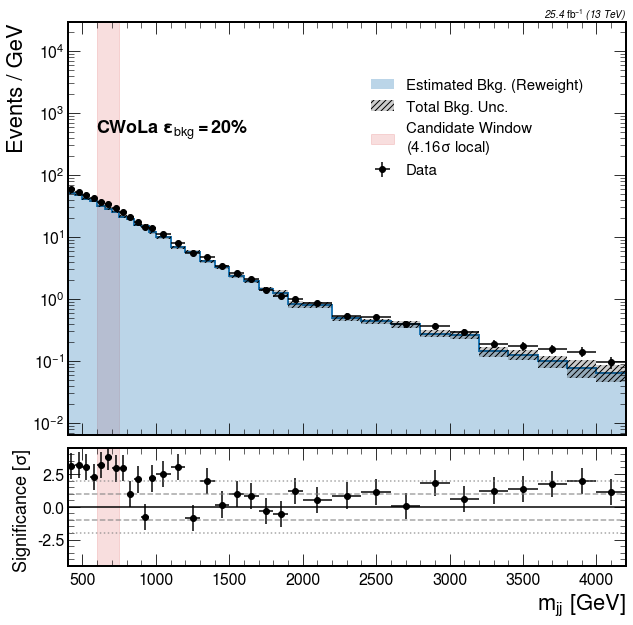

--- Plotting Background Efficiency: 0.100 ---
--- NOM Cut ---
Applying cut at NN Score > 0.5611 (Top 10.0% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5301 (Top 10.0% Background)


/tmp/ipykernel_875878/2777293546.py:97: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.atlas.label(exp="", data=True, lumi=25.4, com=13, label="Work in Progress", ax=ax_main, loc=1)


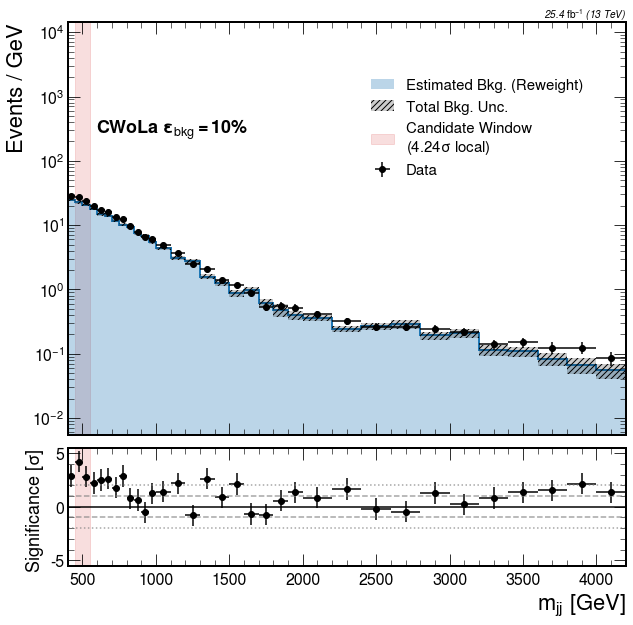

--- Plotting Background Efficiency: 0.050 ---
--- NOM Cut ---
Applying cut at NN Score > 0.5705 (Top 5.0% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5360 (Top 5.0% Background)


/tmp/ipykernel_875878/2777293546.py:97: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.atlas.label(exp="", data=True, lumi=25.4, com=13, label="Work in Progress", ax=ax_main, loc=1)


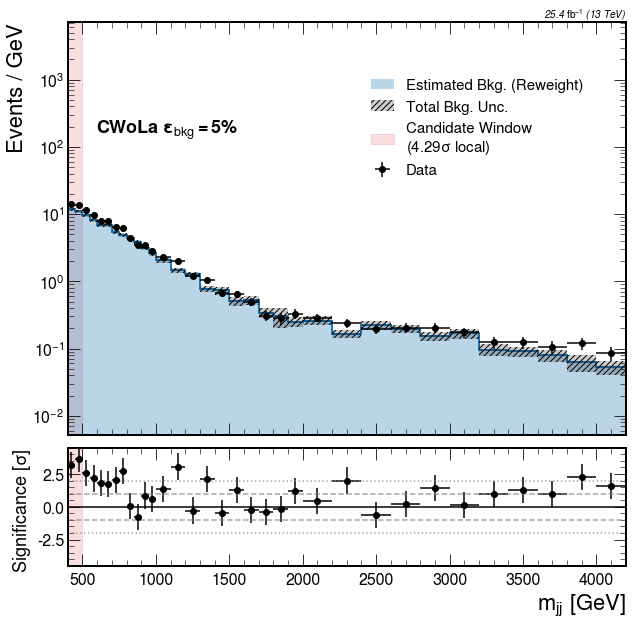

--- Plotting Background Efficiency: 0.030 ---
--- NOM Cut ---
Applying cut at NN Score > 0.5756 (Top 3.0% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5406 (Top 3.0% Background)


/tmp/ipykernel_875878/2777293546.py:97: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.atlas.label(exp="", data=True, lumi=25.4, com=13, label="Work in Progress", ax=ax_main, loc=1)


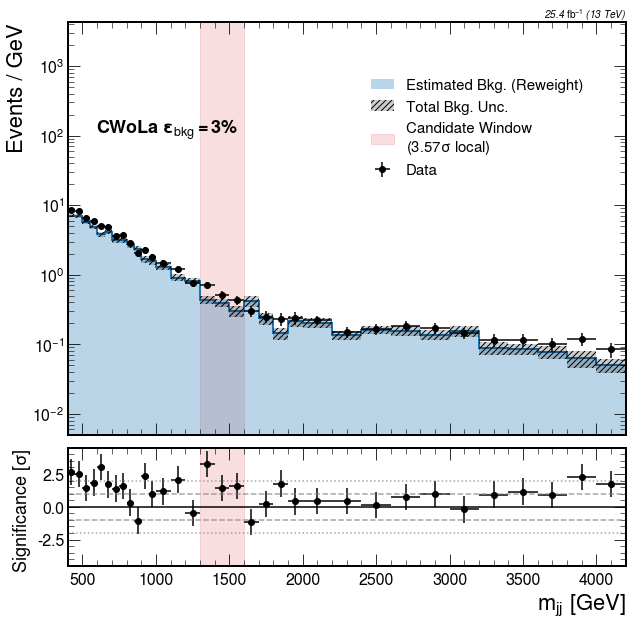

--- Plotting Background Efficiency: 0.020 ---
--- NOM Cut ---
Applying cut at NN Score > 0.5787 (Top 2.0% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5440 (Top 2.0% Background)


/tmp/ipykernel_875878/2777293546.py:97: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.atlas.label(exp="", data=True, lumi=25.4, com=13, label="Work in Progress", ax=ax_main, loc=1)


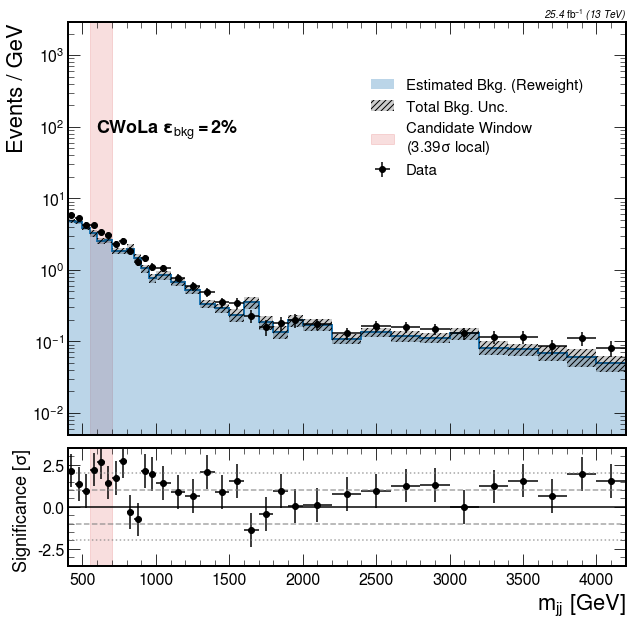

--- Plotting Background Efficiency: 0.010 ---
--- NOM Cut ---
Applying cut at NN Score > 0.5832 (Top 1.0% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5481 (Top 1.0% Background)


/tmp/ipykernel_875878/2777293546.py:97: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.atlas.label(exp="", data=True, lumi=25.4, com=13, label="Work in Progress", ax=ax_main, loc=1)


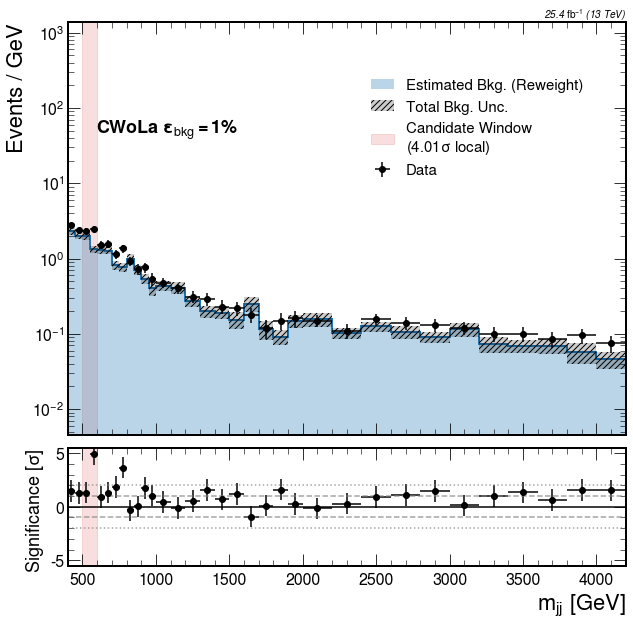

--- Plotting Background Efficiency: 0.005 ---
--- NOM Cut ---
Applying cut at NN Score > 0.5869 (Top 0.5% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5582 (Top 0.5% Background)


/tmp/ipykernel_875878/2777293546.py:97: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.atlas.label(exp="", data=True, lumi=25.4, com=13, label="Work in Progress", ax=ax_main, loc=1)


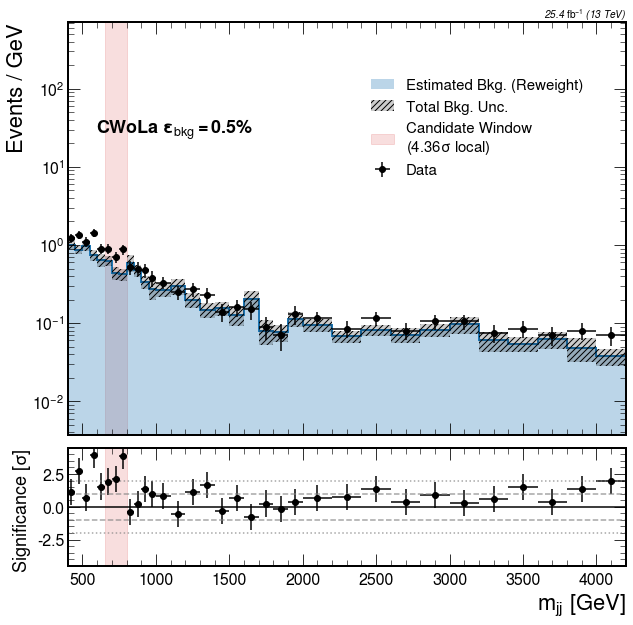

--- Plotting Background Efficiency: 0.001 ---
--- NOM Cut ---
Applying cut at NN Score > 0.5945 (Top 0.1% Background)
--- RW Cut ---
Applying cut at NN Score > 0.6255 (Top 0.1% Background)


/tmp/ipykernel_875878/2777293546.py:97: FutureWarning: kwarg `label` in function `label()` is deprecated and will be removed: Use `text="..."` instead.
  hep.atlas.label(exp="", data=True, lumi=25.4, com=13, label="Work in Progress", ax=ax_main, loc=1)


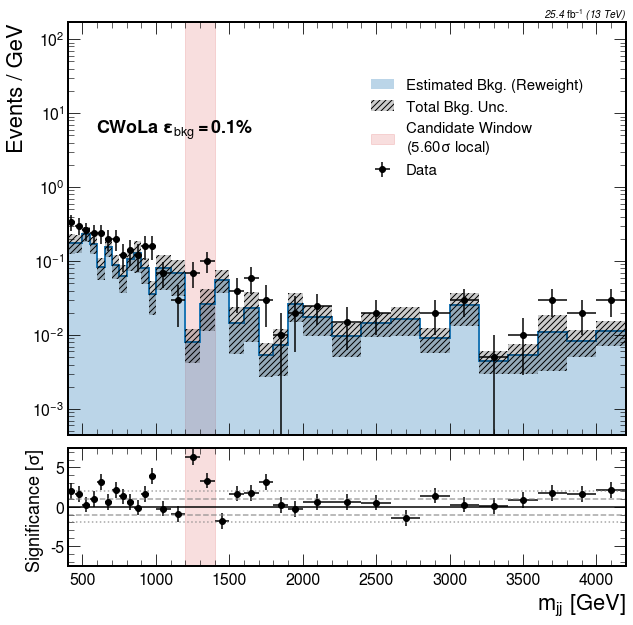

In [ ]:
for bkg_eff in [0.20, 0.10, 0.05, 0.03, 0.02, 0.01, 0.005, 0.001]:
    with open(f"Results/df_null_hypothesis_results_{bkg_eff}.pkl", "rb") as f:
        results = pickle.load(f)

    print(f"--- Plotting Background Efficiency: {bkg_eff:.3f} ---")
    
    # 1. GENERATE THE DATA/MC YIELDS
    post_cut_data_nom, post_cut_nom, nom_threshold = apply_hybrid_cut(df_data_unscaled, df_mc_rw_unscaled, bkg_type="NOM", target_eff=bkg_eff)
    post_cut_data_rw, post_cut_rw, rw_threshold = apply_hybrid_cut(df_data_unscaled, df_mc_rw_unscaled, bkg_type="RW", target_eff=bkg_eff)

    n_bins = len(mjj_bins) - 1
    mjj_data = np.asarray(post_cut_data_rw["mjj"].values, dtype=float)
    mjj_mc = np.asarray(post_cut_rw["mjj"].values, dtype=float)
    w_rw = np.asarray(post_cut_rw["rw_mediam_weights"].values, dtype=float)


    N, _ = np.histogram(mjj_data, bins=mjj_bins)
    B, _ = np.histogram(mjj_mc, bins=mjj_bins, weights=w_rw)

    N = N.astype(float)
    B = B.astype(float)

    # 2. EXTRACT EXACT PHYSICS DATA FROM THE DICTIONARY
    start_idx, end_idx = results["best_window"]
    z_local = results["z_local"]
    
    # --- CRITICAL FIX: Extract the covariance and variance from the loaded pickle! ---
    cov_sys_matrix = results["cov_sys_matrix"]
    var_stat_mc = results["var_stat_mc"]

    # The total background variance (systematic + finite-MC)
    bkg_variance = np.diag(cov_sys_matrix) + var_stat_mc
    bkg_err = np.sqrt(bkg_variance)

    # Calculate the bin-by-bin significance (Pulls)
    total_variance = np.maximum(B + bkg_variance, 1e-12)
    pulls = (N - B) / np.sqrt(total_variance)

    # =====================================================================
    # 3. CONVERT TO EVENTS / GEV
    # =====================================================================
    bin_centers = 0.5 * (mjj_bins[:-1] + mjj_bins[1:])
    bin_widths = np.diff(mjj_bins)

    # Scale Data
    plot_N = N / bin_widths
    plot_N_err = np.sqrt(N) / bin_widths

    # Scale Background
    plot_B = B / bin_widths
    plot_bkg_err = bkg_err / bin_widths

    # =====================================================================
    # 4. BUILD THE FIGURE
    # =====================================================================
    fig, (ax_main, ax_pull) = plt.subplots(
        nrows=2, ncols=1, figsize=(10, 10), 
        gridspec_kw={'height_ratios': [3.5, 1], 'hspace': 0.05},
        sharex=True
    )

    # ---------------------------------------------------
    # MAIN PANEL: m_jj SPECTRUM (EVENTS / GEV)
    # ---------------------------------------------------
    # 1. Plot Background Estimate
    hep.histplot(plot_B, bins=mjj_bins, ax=ax_main, histtype='fill', 
                color='tab:blue', alpha=0.3, label='Estimated Bkg. (Reweight)')
    hep.histplot(plot_B, bins=mjj_bins, ax=ax_main, histtype='step', color='tab:blue', linewidth=2)

    # 2. Plot Total Background Uncertainty Band
    ax_main.stairs(plot_B + plot_bkg_err, mjj_bins, baseline=plot_B - plot_bkg_err, 
                fill=True, color='black', alpha=0.2, hatch='////', 
                label='Total Bkg. Unc.')

    # 3. Highlight the Candidate Window
    ax_main.axvspan(mjj_bins[start_idx], mjj_bins[end_idx], 
                    color='tab:red', alpha=0.15, zorder=0,
                    label=f'Candidate Window\n({z_local:.2f}$\\sigma$ local)')

    # 4. Plot Observed Data
    ax_main.errorbar(bin_centers, plot_N, yerr=plot_N_err, xerr=bin_widths/2, 
                    fmt='ko', label='Data', zorder=5)

    # Formatting Main Panel
    ax_main.set_yscale('log')
    
    # Dynamically scale Y-axis based on the new Events/GeV values
    y_min = np.min(plot_B[plot_B > 0]) * 0.1 if np.any(plot_B > 0) else 1e-4
    y_max = np.max(plot_N) * 500 # Extra headroom for the legend and labels
    ax_main.set_ylim(y_min, y_max)
    
    # Updated Y-axis label
    ax_main.set_ylabel('Events / GeV', fontsize=22)
    ax_main.tick_params(axis='y', labelsize=16)

    # Generic HEP Label (No ATLAS brand, but retains lumi and COM)
    hep.atlas.label(exp="", data=True, lumi=25.4, com=13, label="Work in Progress", ax=ax_main, loc=1)

    cut_percentage = bkg_eff * 100
    ax_main.text(0.05, 0.73, f"CWoLa $\\varepsilon_{{\\text{{bkg}}}} = {cut_percentage:g}\\%$", 
                transform=ax_main.transAxes, fontsize=18, fontweight='bold')

    ax_main.legend(loc='upper right', bbox_to_anchor=(0.95, 0.90), 
                fontsize=15, frameon=False)

    # ---------------------------------------------------
    # LOWER PANEL: SIGNIFICANCE (PULLS)
    # ---------------------------------------------------
    # Plot pulls (Calculated previously on RAW counts, which is mathematically correct)
    ax_pull.errorbar(bin_centers, pulls, yerr=1.0, xerr=bin_widths/2, fmt='ko')

    # Guide lines
    ax_pull.axhline(0, color='black', linestyle='-', linewidth=1.5)
    ax_pull.axhline(1, color='gray', linestyle='--', alpha=0.7)
    ax_pull.axhline(-1, color='gray', linestyle='--', alpha=0.7)
    ax_pull.axhline(2, color='gray', linestyle=':', alpha=0.7)
    ax_pull.axhline(-2, color='gray', linestyle=':', alpha=0.7)

    ax_pull.axvspan(mjj_bins[start_idx], mjj_bins[end_idx], 
                    color='tab:red', alpha=0.15, zorder=0)

    # Formatting Pull Panel
    ax_pull.set_ylabel('Significance [$\\sigma$]', fontsize=18)
    ax_pull.set_xlabel('$m_{jj}$ [GeV]', fontsize=22)

    max_pull = np.max(np.abs(pulls))
    pull_lim = max(3.5, np.ceil(max_pull) + 0.5)
    ax_pull.set_ylim(-pull_lim, pull_lim)
    ax_pull.set_xlim(mjj_bins[0], mjj_bins[-1])
    ax_pull.tick_params(axis='both', labelsize=16)

    # =====================================================================
    # 5. FINALIZE AND SAVE
    # =====================================================================
    # plt.savefig(f"mjj_spectrum_{cut_percentage}_cut.pdf", bbox_inches='tight', dpi=300)
    plt.show()

## Phase 2: BSM Signal

In [ ]:
# h1_results = []

# for sig_id in SIGNAL_MODES:
#     df_sig = df_sig_def_unscaled[sig_id]
    
#     # --- 1. APPLY THE SIGNAL REGION CUT ---
#     # Apply the exact same 1% anomaly score threshold used for Data and Background
#     sig_sr = df_sig[df_sig['bsm_score_Reweight_Median'] > rw_threshold]
    
#     # --- 2. CALCULATE SIGNAL YIELDS & VARIANCE ---
#     # Bin the surviving signal events into the same mjj_bins
#     S_i, _ = np.histogram(sig_sr['mjj'].values, bins=mjj_bins, weights=sig_sr['final_weight'].values)
    
#     # Calculate the statistical variance of the signal (sum of squared weights)
#     var_sig_stat_i = np.histogram(sig_sr['mjj'].values, bins=mjj_bins, weights=sig_sr['final_weight'].values**2)[0]
    
#     # If the signal is entirely killed by the anomaly cut, record 0 and skip
#     if S_i.sum() <= 0:
#         h1_results.append({
#             "Model": sig_id, "Mass Window": "N/A", "Exp. B": 0, "Obs. Data": 0, 
#             "Data Excess": 0, "Signal (S)": 0, "Exp. Z": 0.0, "Pull (H1)": np.nan
#         })
#         continue
        
#     # --- 3. DYNAMICALLY DEFINE THE SIGNAL MASS WINDOW ---
#     # A resonance is narrow. We find the bins where the signal yield is at least 
#     # 5% of the peak signal bin to define the active signal window.
#     active_bins = np.where(S_i > 0.05 * np.max(S_i))[0]
#     start_idx = active_bins[0]
#     end_idx = active_bins[-1]
    
#     window_start_mass = mjj_bins[start_idx]
#     window_end_mass = mjj_bins[end_idx + 1]
    
#     # --- 4. EXTRACT YIELDS IN THE WINDOW ---
#     S_win = np.sum(S_i[start_idx : end_idx + 1])
#     B_win = np.sum(B[start_idx : end_idx + 1])
#     N_win = np.sum(N[start_idx : end_idx + 1])
    
#     # --- 5. EXTRACT & COMBINE VARIANCES IN THE WINDOW ---
#     # Background variances (using the logic fixed in the previous steps)
#     window_var_stat_bkg = np.sum(var_stat[start_idx : end_idx + 1])
#     window_std_sys_bkg = np.sum(np.sqrt(var_sys_total[start_idx : end_idx + 1]))
#     window_var_sys_bkg = window_std_sys_bkg**2  # Correlated squaring
    
#     window_var_bkg = window_var_stat_bkg + window_var_sys_bkg
    
#     # Signal statistical variance
#     window_var_sig = np.sum(var_sig_stat_i[start_idx : end_idx + 1])
    
#     # --- 6. CALCULATE HYPOTHESIS METRICS ---
#     # Expected Significance (Sensitivity): S / sqrt(B + Var_B)
#     Z_exp = S_win / np.sqrt(B_win + window_var_bkg) if (B_win + window_var_bkg) > 0 else 0
    
#     # H1 Pull: (Data - (B + S)) / sqrt(B + S + Var_B + Var_S)
#     # Note: B_win and S_win are included in the denominator as Poisson variance terms
#     total_variance_H1 = B_win + S_win + window_var_bkg + window_var_sig
#     pull_H1 = (N_win - (B_win + S_win)) / np.sqrt(total_variance_H1) if total_variance_H1 > 0 else 0
    
#     # Data excess for contextual comparison
#     excess_win = N_win - B_win
    
#     # Append to results
#     h1_results.append({
#         "Model": sig_id,
#         "Mass Window": f"{window_start_mass:.0f}-{window_end_mass:.0f}",
#         "Exp. B": B_win,
#         "Obs. Data": N_win,
#         "Data Excess": excess_win,
#         "Signal (S)": S_win,
#         "Exp. Z": Z_exp,
#         "Pull (H1)": pull_H1
#     })

# # --- 7. DISPLAY RESULTS ---
# df_h1 = pd.DataFrame(h1_results)
# print("\n--- Alternative Hypothesis (H1) Evaluation ---")
# print(df_h1.to_string(index=False, float_format=lambda x: f"{x:.2f}" if isinstance(x, float) else x))

In [ ]:
pyhf.set_backend("numpy")

print(f"\n--- Running pyhf Profile Likelihood Fits for BSM Models --- at Background Uncertainty {bkg_eff:.2%}")
# --- 1. PREPARE THE SYSTEMATICS ARRAYS ---
# We use the arrays we already built in the H0 step.
# pyhf requires strict avoidance of 0-background bins for stability.
valid_bins = B > 0

B_valid = B[valid_bins]
N_valid = N[valid_bins]
err_stat_valid = np.sqrt(var_stat[valid_bins])  # Absolute stat error
err_ml_valid = std_ml_sys[valid_bins]           # Absolute ML error

# For correlated shape systematics (histosys), pyhf needs the absolute yields of the Up/Down shifts
B_jes_up = B_jes_up[valid_bins]
B_jes_down = B_jes_down[valid_bins]
std_theory_sys = np.std(pdf_yields, axis=0)

B_theory_up = B_valid + std_theory_sys[valid_bins]
B_theory_down = np.clip(B_valid - std_theory_sys[valid_bins], a_min=1e-6, a_max=None)

# List to store our rigorous pyhf results
pyhf_results = []

print("--- Running pyhf Profile Likelihood Fits for BSM Models ---")

# --- 2. LOOP OVER SIGNALS & BUILD WORKSPACES ---
for sig_id in SIGNAL_MODES:
    df_sig = df_sig_def_unscaled[sig_id]
    
    
    sig_sr = df_sig[df_sig['bsm_score_Reweight_Median'] > rw_threshold]
    
    # Calculate Signal Yield
    S, _ = np.histogram(sig_sr['mjj'].values, bins=mjj_bins, weights=sig_sr['final_weight'].values)
    S_valid = S[valid_bins]
    
    # Skip models entirely killed by the anomaly cut
    if S_valid.sum() <= 1e-3:
        pyhf_results.append({
            "Model": sig_id, "Signal Yield": 0.0, 
            "Best-fit Mu": np.nan, "Observed CLs": np.nan, "Expected CLs": np.nan
        })
        continue


    # =====================================================================
    # NEW: DYNAMIC MU SCAN CALCULATION
    # =====================================================================
    # Approximate the background variance using a simple Poisson sqrt(B)
    approx_bkg_err = np.sqrt(B_valid.sum())
    
    # Estimate the mu needed to hit a ~2 sigma excess
    estimated_mu_limit = (2.0 * approx_bkg_err) / S_valid.sum()
    
    # Set the max scan range to 3 times the estimate to give pyhf plenty of room.
    # We clip it between 5.0 (for strong signals) and 200.0 (for impossibly weak signals).
    mu_max = float(np.clip(estimated_mu_limit * 3.0, a_min=5.0, a_max=None))
    
    # Create 51 points just within our custom, targeted range
    scan_mu = np.linspace(0.0, mu_max, 51)
    # =====================================================================


    # --- 3. CONSTRUCT THE PYHF WORKSPACE ---
    # This translates our arrays and uncertainties into a formal statistical model
    workspace_dict = {
        "channels": [
            {
                "name": "signal_region",
                "samples": [
                    {
                        "name": "background",
                        "data": B_valid.tolist(),
                        "modifiers": [
                            # 1. MC Statistical Error
                            {"name": "staterror", "type": "staterror", "data": err_stat_valid.tolist()},
                            # 2. Luminosity (5% normalization uncertainty)
                            {"name": "lumi", "type": "normsys", "data": {"hi": 1.05, "lo": 0.95}},
                            # 3. JES/JER (Correlated Shape uncertainty)
                            {"name": "jes_jer", "type": "histosys", "data": {"hi_data": B_jes_up.tolist(), "lo_data": B_jes_down.tolist()}},
                            # 4. Theory PDF/Scale (Correlated Shape uncertainty)
                            {"name": "theory", "type": "histosys", "data": {"hi_data": B_theory_up.tolist(), "lo_data": B_theory_down.tolist()}},
                            # 5. ML Epistemic Spread + Non-Closure (Uncorrelated bin-by-bin shape uncertainty)
                            {"name": "ml_systematics", "type": "shapesys", "data": err_ml_valid.tolist()}
                        ]
                    },
                    {
                        "name": "signal",
                        "data": S_valid.tolist(),
                        "modifiers": [
                            # The Parameter of Interest (POI)
                            {"name": "mu", "type": "normfactor", "data": None}
                        ]
                    }
                ]
            }
        ],
        "observations": [
            {"name": "signal_region", "data": N_valid.tolist()}
        ],
        "measurements": [
            {
                "name": "Measurement", 
                "config": {
                    "poi": "mu", 
                    "parameters": [
                        {
                            "name": "mu",
                            "bounds": [[0.0, float(mu_max * 1.2)]]
                        }
                    ]
                }
            }
        ],
        "version": "1.0.0"
    }
    
    # Build the model and data array (combining observations + auxiliary constraint data)
    workspace = pyhf.Workspace(workspace_dict)
    model = workspace.model()
    data = workspace.data(model)

    best_fit_pars = pyhf.infer.mle.fit(data, model)
    mu_hat = best_fit_pars[model.config.poi_index]

    
    obs_limit, exp_limits, details= pyhf.infer.intervals.upper_limits.upper_limit(
        data, 
        model, 
        scan_mu, 
        level=0.05, 
        return_results=True
    )
    
    try:
        # C. Safely extract ALL the expected limit bands
        if isinstance(exp_limits, (list, tuple, np.ndarray)) and len(exp_limits) >= 5:
            exp_m2  = float(np.asarray(exp_limits)[0]) # -2 sigma
            exp_m1  = float(np.asarray(exp_limits)[1]) # -1 sigma
            exp_med = float(np.asarray(exp_limits)[2]) # Median
            exp_p1  = float(np.asarray(exp_limits)[3]) # +1 sigma
            exp_p2  = float(np.asarray(exp_limits)[4]) # +2 sigma
        else:
            exp_m2 = exp_m1 = exp_med = exp_p1 = exp_p2 = np.nan
            
        # D. Safely extract the observed limit
        try:
            obs_limit = float(np.asarray(obs_limit))
        except (TypeError, ValueError):
            obs_limit = np.nan
        
        pyhf_results.append({
            "Model": sig_id,
            "Signal Yield": S_valid.sum(),
            "Best-fit Mu": mu_hat,
            "Obs_Limit": obs_limit,
            "Exp_m2": exp_m2,
            "Exp_m1": exp_m1,
            "Exp_med": exp_med,
            "Exp_p1": exp_p1,
            "Exp_p2": exp_p2
        })
    except Exception as e:
        print(f"Fit failed for {sig_id}: {e}")
        pyhf_results.append({
            "Model": sig_id, "Signal Yield": S_valid.sum(), 
            "Best-fit Mu": np.nan, "Obs_Limit": np.nan, "Exp_m2": np.nan, "Exp_m1": np.nan, "Exp_med": np.nan, "Exp_p1": np.nan, "Exp_p2": np.nan
        })

# --- 5. DISPLAY RESULTS ---
df_pyhf = pd.DataFrame(pyhf_results)
print("\n--- pyhf Profile Likelihood Results ---")
print(df_pyhf.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else x))


--- Running pyhf Profile Likelihood Fits for BSM Models --- at Background Uncertainty 0.10%
--- Running pyhf Profile Likelihood Fits for BSM Models ---


/home/aegis/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/home/aegis/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/home/aegis/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:493: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])



--- pyhf Profile Likelihood Results ---
 Model  Signal Yield  Best-fit Mu  Observed CLs  Expected CLs  Obs_Limit   Exp_m2    Exp_m1   Exp_med    Exp_p1    Exp_p2
1000_2        0.0000          NaN           NaN           NaN        NaN      NaN       NaN       NaN       NaN       NaN
1000_4        0.0000          NaN           NaN           NaN        NaN      NaN       NaN       NaN       NaN       NaN
1000_6        0.0000          NaN           NaN           NaN        NaN      NaN       NaN       NaN       NaN       NaN
1000_8        0.0000          NaN           NaN           NaN        NaN      NaN       NaN       NaN       NaN       NaN
2000_2        0.0000          NaN           NaN           NaN        NaN      NaN       NaN       NaN       NaN       NaN
2000_4        0.0373      92.0868           NaN           NaN   254.9157  92.0187  122.2262  174.8504  255.8360  371.9415
2000_6        0.0371      92.5193           NaN           NaN   256.1366  92.4578  122.8091  175.6855  25

In [ ]:
df_pyhf.to_csv(f"Results/df_alter_hypothesis_results_{bkg_eff}.csv", index=False)

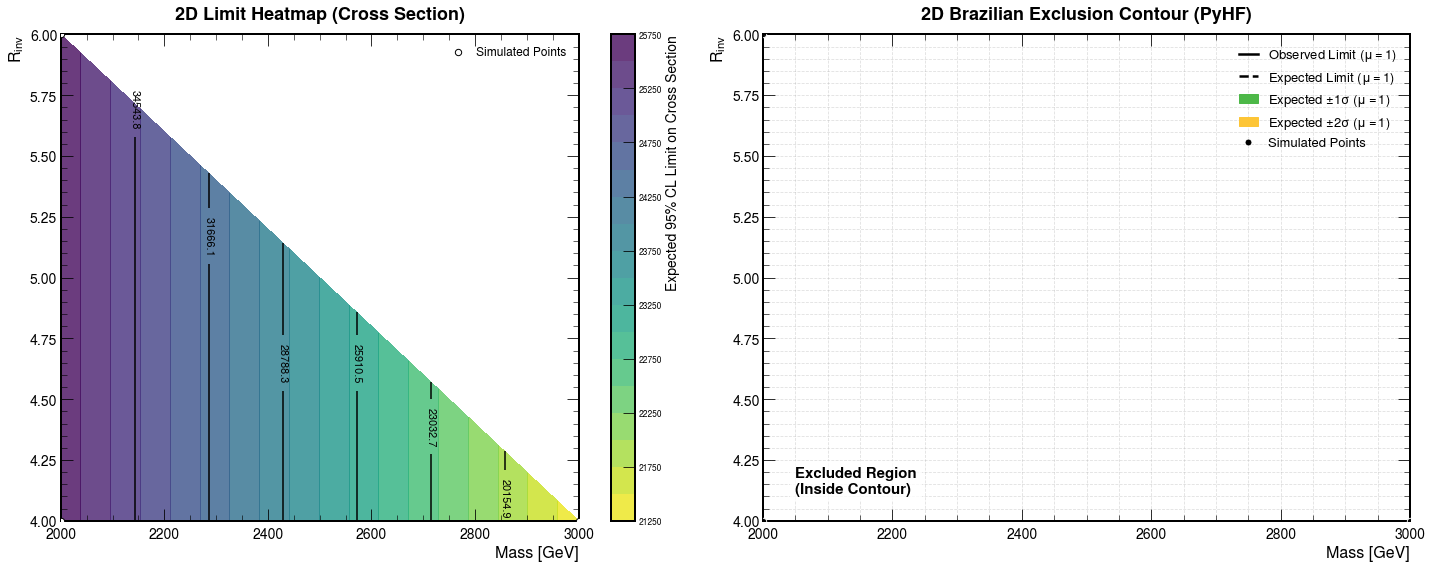

In [ ]:
def plot_2d_bsm_limits_corrected(df, 
                                 mass_col='Mass', 
                                 rinv_col='Rinv', 
                                 xs_col='XS',
                                 obs_col='Obs_Limit', 
                                 med_col='Exp_med',
                                 m1_col='Exp_m1', 
                                 p1_col='Exp_p1', 
                                 m2_col='Exp_m2', 
                                 p2_col='Exp_p2',
                                 exclusion_threshold=1.0,
                                 title_suffix="(PyHF)"):
    """
    Plots a 2D Heatmap (in Cross Section) and a 2D Brazilian Contour (in mu) side-by-side.
    """
    # Drop rows where limits or theoretical XS could not be found
    df_plot = df.dropna(subset=[med_col, obs_col, xs_col]).copy()
    
    x = df_plot[mass_col].values
    y = df_plot[rinv_col].values
    
    # Create the 2D Interpolation Grid (300x300 density)
    xi = np.linspace(x.min(), x.max(), 300)
    yi = np.linspace(y.min(), y.max(), 300)
    X, Y = np.meshgrid(xi, yi)
    
    # =====================================================================
    # INTERPOLATE FOR HEATMAP (CROSS SECTION)
    # =====================================================================
    # Multiply the mu limits by the theoretical cross section
    z_med_xs = df_plot[med_col].values * df_plot[xs_col].values
    z_obs_xs = df_plot[obs_col].values * df_plot[xs_col].values
    
    Z_med_XS = griddata((x, y), z_med_xs, (X, Y), method='linear')
    Z_obs_XS = griddata((x, y), z_obs_xs, (X, Y), method='linear')
    
    # =====================================================================
    # INTERPOLATE FOR BRAZILIAN CONTOUR (SIGNAL STRENGTH MU)
    # =====================================================================
    Z_obs = griddata((x, y), df_plot[obs_col].values, (X, Y), method='linear')
    Z_med = griddata((x, y), df_plot[med_col].values, (X, Y), method='linear')
    Z_m1  = griddata((x, y), df_plot[m1_col].values, (X, Y), method='linear')
    Z_p1  = griddata((x, y), df_plot[p1_col].values, (X, Y), method='linear')
    Z_m2  = griddata((x, y), df_plot[m2_col].values, (X, Y), method='linear')
    Z_p2  = griddata((x, y), df_plot[p2_col].values, (X, Y), method='linear')
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # =====================================================================
    # PLOT 1: 2D LIMIT HEATMAP (CROSS SECTION)
    # =====================================================================
    ax1 = axes[0]
    
    # Draw expected limit heatmap in XS
    cf1 = ax1.contourf(X, Y, Z_med_XS, cmap='viridis_r', levels=20, alpha=0.8)
    cbar = fig.colorbar(cf1, ax=ax1)
    cbar.set_label('Expected 95% CL Limit on Cross Section', fontsize=14)
    
    # Draw observed limit contours in XS
    try:
        if not np.isnan(Z_obs_XS).all():
            obs_levels = np.linspace(np.nanmin(Z_obs_XS), np.nanmax(Z_obs_XS), 8)
            cs1 = ax1.contour(X, Y, Z_obs_XS, colors='black', linestyles='solid', linewidths=1.5, levels=obs_levels)
            ax1.clabel(cs1, inline=True, fontsize=11, fmt='%1.1f')
    except Exception:
        pass
        
    ax1.scatter(x, y, color='white', edgecolor='black', s=40, zorder=5, label='Simulated Points')
    ax1.set_xlabel('Mass [GeV]', fontsize=16)
    ax1.set_ylabel(r'$R_{inv}$', fontsize=16)
    ax1.set_title(f'2D Limit Heatmap (Cross Section)', fontsize=18, fontweight='bold', pad=15)
    ax1.legend(loc='upper right', fontsize=12)
    ax1.tick_params(axis='both', labelsize=14)
    
    # =====================================================================
    # PLOT 2: 2D BRAZILIAN CONTOUR (SIGNAL STRENGTH MU)
    # =====================================================================
    ax2 = axes[1]
    
    band_grid = np.zeros_like(X)
    band_grid[(Z_m2 <= exclusion_threshold) & (Z_m1 > exclusion_threshold)] = 1
    band_grid[(Z_p1 <= exclusion_threshold) & (Z_p2 > exclusion_threshold)] = 1
    band_grid[(Z_m1 <= exclusion_threshold) & (Z_p1 > exclusion_threshold)] = 2
    
    ax2.contourf(X, Y, band_grid, levels=[0.5, 1.5, 2.5], colors=['#FDC536', '#4DB848'], alpha=0.8)
    
    try:
        ax2.contour(X, Y, Z_med, levels=[exclusion_threshold], colors='black', linestyles='dashed', linewidths=2.5)
    except ValueError:
        pass 
        
    try:
        ax2.contour(X, Y, Z_obs, levels=[exclusion_threshold], colors='black', linestyles='solid', linewidths=2.5)
    except ValueError:
        pass 
        
    ax2.scatter(x, y, color='black', s=40, edgecolor='white', alpha=0.9, zorder=5, label='Simulated Points')
    
    yellow_patch = mpatches.Patch(color='#FDC536', label=r'Expected $\pm 2\sigma$ ($\mu=1$)')
    green_patch  = mpatches.Patch(color='#4DB848', label=r'Expected $\pm 1\sigma$ ($\mu=1$)')
    exp_line     = mlines.Line2D([], [], color='black', linestyle='dashed', linewidth=2.5, label='Expected Limit ($\mu=1$)')
    obs_line     = mlines.Line2D([], [], color='black', linestyle='solid', linewidth=2.5, label='Observed Limit ($\mu=1$)')
    points       = mlines.Line2D([], [], color='black', marker='o', markeredgecolor='white', linestyle='None', markersize=7, label='Simulated Points')
    
    ax2.legend(handles=[obs_line, exp_line, green_patch, yellow_patch, points], loc='upper right', fontsize=13, framealpha=0.95)
    
    ax2.set_xlabel('Mass [GeV]', fontsize=16)
    ax2.set_ylabel(r'$R_{inv}$', fontsize=16)
    ax2.set_title(f'2D Brazilian Exclusion Contour {title_suffix}', fontsize=18, fontweight='bold', pad=15)
    
    ax2.text(0.05, 0.05, "Excluded Region\n(Inside Contour)", transform=ax2.transAxes, 
            fontsize=15, fontweight='bold', color='black', verticalalignment='bottom', 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=5))
            
    ax2.tick_params(axis='both', labelsize=14)
    ax2.grid(True, which='both', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.savefig(f"Results/2D_BSM_Limits_{bkg_eff}.pdf")
    plt.show()


df_pyhf = pd.read_csv(f'Results/df_alter_hypothesis_results_{bkg_eff}.csv')
df_pyhf[['Mass', 'Rinv']] = df_pyhf['Model'].str.split('_', expand=True).astype(float)
df_merged = pd.merge(df_pyhf, DF_META, on=['Mass', 'Rinv'])
plot_2d_bsm_limits_corrected(df_merged)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy.interpolate import griddata
import pyhf

# Set pyhf backend for fast numpy operations
pyhf.set_backend("numpy")

# =====================================================================
# 1. PLOTTING FUNCTION DEFINITION
# =====================================================================
def plot_2d_bsm_limits_corrected(df, 
                                 mass_col='Mass', 
                                 rinv_col='Rinv', 
                                 xs_col='XS',
                                 obs_col='Obs_Limit', 
                                 med_col='Exp_med',
                                 m1_col='Exp_m1', 
                                 p1_col='Exp_p1', 
                                 m2_col='Exp_m2', 
                                 p2_col='Exp_p2',
                                 exclusion_threshold=1.0,
                                 title_suffix="(PyHF)",
                                 bkg_eff_label=""):
    """
    Plots a 2D Heatmap (in Cross Section) and a 2D Brazilian Contour (in mu) side-by-side.
    """
    df_plot = df.dropna(subset=[med_col, obs_col, xs_col]).copy()
    if df_plot.empty:
        print(f"Skipping plot for {bkg_eff_label}: No valid limits found.")
        return

    x = df_plot[mass_col].values
    y = df_plot[rinv_col].values
    
    # Create the 2D Interpolation Grid (300x300 density)
    xi = np.linspace(x.min(), x.max(), 300)
    yi = np.linspace(y.min(), y.max(), 300)
    X, Y = np.meshgrid(xi, yi)
    
    # --- INTERPOLATE FOR HEATMAP (CROSS SECTION) ---
    z_med_xs = df_plot[med_col].values * df_plot[xs_col].values
    z_obs_xs = df_plot[obs_col].values * df_plot[xs_col].values
    
    Z_med_XS = griddata((x, y), z_med_xs, (X, Y), method='linear')
    Z_obs_XS = griddata((x, y), z_obs_xs, (X, Y), method='linear')
    
    # --- INTERPOLATE FOR BRAZILIAN CONTOUR (SIGNAL STRENGTH MU) ---
    # Using 'cubic' for smoother, publication-ready contour lines
    Z_obs = griddata((x, y), df_plot[obs_col].values, (X, Y), method='cubic')
    Z_med = griddata((x, y), df_plot[med_col].values, (X, Y), method='cubic')
    Z_m1  = griddata((x, y), df_plot[m1_col].values, (X, Y), method='cubic')
    Z_p1  = griddata((x, y), df_plot[p1_col].values, (X, Y), method='cubic')
    Z_m2  = griddata((x, y), df_plot[m2_col].values, (X, Y), method='cubic')
    Z_p2  = griddata((x, y), df_plot[p2_col].values, (X, Y), method='cubic')
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # --- PLOT 1: 2D LIMIT HEATMAP (CROSS SECTION) ---
    ax1 = axes[0]
    cf1 = ax1.contourf(X, Y, Z_med_XS, cmap='viridis_r', levels=20, alpha=0.8)
    cbar = fig.colorbar(cf1, ax=ax1)
    cbar.set_label('Expected 95% CL Limit on Cross Section', fontsize=14)
    
    try:
        if not np.isnan(Z_obs_XS).all():
            obs_levels = np.linspace(np.nanmin(Z_obs_XS), np.nanmax(Z_obs_XS), 8)
            cs1 = ax1.contour(X, Y, Z_obs_XS, colors='black', linestyles='solid', linewidths=1.5, levels=obs_levels)
            ax1.clabel(cs1, inline=True, fontsize=11, fmt='%1.1f')
    except Exception:
        pass
        
    ax1.scatter(x, y, color='white', edgecolor='black', s=40, zorder=5, label='Simulated Points')
    ax1.set_xlabel('Mass [GeV]', fontsize=16)
    ax1.set_ylabel(r'$R_{inv}$', fontsize=16)
    ax1.set_title(f'2D Limit Heatmap (Cross Section) - {bkg_eff_label}', fontsize=18, fontweight='bold', pad=15)
    ax1.legend(loc='upper right', fontsize=12)
    ax1.tick_params(axis='both', labelsize=14)
    
    # --- PLOT 2: 2D BRAZILIAN CONTOUR (SIGNAL STRENGTH MU) ---
    ax2 = axes[1]
    
    band_grid = np.zeros_like(X)
    band_grid[(Z_m2 <= exclusion_threshold) & (Z_m1 > exclusion_threshold)] = 1
    band_grid[(Z_p1 <= exclusion_threshold) & (Z_p2 > exclusion_threshold)] = 1
    band_grid[(Z_m1 <= exclusion_threshold) & (Z_p1 > exclusion_threshold)] = 2
    
    ax2.contourf(X, Y, band_grid, levels=[0.5, 1.5, 2.5], colors=['#FDC536', '#4DB848'], alpha=0.8)
    
    try:
        ax2.contour(X, Y, Z_med, levels=[exclusion_threshold], colors='black', linestyles='dashed', linewidths=2.5)
        ax2.contour(X, Y, Z_obs, levels=[exclusion_threshold], colors='black', linestyles='solid', linewidths=2.5)
    except ValueError:
        pass 
        
    ax2.scatter(x, y, color='black', s=40, edgecolor='white', alpha=0.9, zorder=5, label='Simulated Points')
    
    yellow_patch = mpatches.Patch(color='#FDC536', label=r'Expected $\pm 2\sigma$ ($\mu=1$)')
    green_patch  = mpatches.Patch(color='#4DB848', label=r'Expected $\pm 1\sigma$ ($\mu=1$)')
    exp_line     = mlines.Line2D([], [], color='black', linestyle='dashed', linewidth=2.5, label='Expected Limit ($\mu=1$)')
    obs_line     = mlines.Line2D([], [], color='black', linestyle='solid', linewidth=2.5, label='Observed Limit ($\mu=1$)')
    points       = mlines.Line2D([], [], color='black', marker='o', markeredgecolor='white', linestyle='None', markersize=7, label='Simulated Points')
    
    ax2.legend(handles=[obs_line, exp_line, green_patch, yellow_patch, points], loc='upper right', fontsize=13, framealpha=0.95)
    
    ax2.set_xlabel('Mass [GeV]', fontsize=16)
    ax2.set_ylabel(r'$R_{inv}$', fontsize=16)
    ax2.set_title(f'2D Exclusion Contour {title_suffix} - {bkg_eff_label}', fontsize=18, fontweight='bold', pad=15)
    
    ax2.text(0.05, 0.05, "Excluded Region\n(Inside Contour)", transform=ax2.transAxes, 
            fontsize=15, fontweight='bold', color='black', verticalalignment='bottom', 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=5))
            
    ax2.tick_params(axis='both', labelsize=14)
    ax2.grid(True, which='both', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    # Replace decimal point in filename to avoid extension issues (e.g., 0.05 -> 0p05)
    safe_eff = str(bkg_eff_label).replace(".", "p")
    plt.savefig(f"Results/2D_BSM_Limits_{safe_eff}.pdf")
    plt.show()

# =====================================================================
# 2. MAIN LIMIT SETTING LOOP
# =====================================================================
# (Assumes N, B, var_stat, B_jes_up, B_jes_down, pdf_yields, etc., are updated per bkg_eff in your master script)

for bkg_eff in [0.20, 0.10, 0.05, 0.03, 0.02, 0.01, 0.005, 0.001]:
    print(f"\n{'='*60}")
    print(f"--- Running pyhf Fit at Background Efficiency {bkg_eff:.2%} ---")
    print(f"{'='*60}")
    
    # --- PREPARE THE SYSTEMATICS ARRAYS ---
    # pyhf requires strict avoidance of 0-background bins for stability.
    valid_bins = B > 0

    B_valid = B[valid_bins]
    N_valid = N[valid_bins]
    var_stat_valid = var_stat_mc[valid_bins]
    
    # 1. Evaluate explicit ML closure error derived from CR validation (3.3% of B)
    err_ml_valid = 0.033 * B_valid
    
    # 2. COMBINE THE UNCORRELATED BIN-BY-BIN ERRORS IN QUADRATURE (CRITICAL FIX)
    combined_bin_variance = var_stat_valid + (err_ml_valid**2)
    combined_bin_err = np.sqrt(combined_bin_variance)

    # Correlated shape systematics (histosys)
    b_jes_up_valid = B_jes_up[valid_bins]
    b_jes_down_valid = B_jes_down[valid_bins]
    
    std_theory_sys = np.std(pdf_yields, axis=0)
    B_theory_up = B_valid + std_theory_sys[valid_bins]
    B_theory_down = np.clip(B_valid - std_theory_sys[valid_bins], a_min=1e-6, a_max=None)

    pyhf_results = []

    # --- LOOP OVER SIGNALS & BUILD WORKSPACES ---
    for sig_id in SIGNAL_MODES:
        df_sig = df_sig_def_unscaled[sig_id]
        
        # Apply CWoLa cut exactly as performed on Data/MC
        sig_sr = df_sig[df_sig['bsm_score_Reweight_Median'] > rw_threshold]
        
        # Calculate Signal Yield
        S, _ = np.histogram(sig_sr['mjj'].values, bins=mjj_bins, weights=sig_sr['final_weight'].values)
        S_valid = S[valid_bins]
        
        # Skip models entirely killed by the anomaly cut
        if S_valid.sum() <= 1e-3:
            pyhf_results.append({
                "Model": sig_id, "Signal Yield": 0.0, 
                "Best-fit Mu": np.nan, "Obs_Limit": np.nan, 
                "Exp_m2": np.nan, "Exp_m1": np.nan, "Exp_med": np.nan, "Exp_p1": np.nan, "Exp_p2": np.nan
            })
            continue

        # --- DYNAMIC MU SCAN CALCULATION ---
        approx_bkg_err = np.sqrt(B_valid.sum())
        estimated_mu_limit = (2.0 * approx_bkg_err) / S_valid.sum()
        mu_max = float(np.clip(estimated_mu_limit * 3.0, a_min=5.0, a_max=200.0))
        scan_mu = np.linspace(0.0, mu_max, 51)

        # --- CONSTRUCT THE PYHF WORKSPACE ---
        workspace_dict = {
            "channels": [
                {
                    "name": "signal_region",
                    "samples": [
                        {
                            "name": "background",
                            "data": B_valid.tolist(),
                            "modifiers": [
                                # Combined Stat + ML Closure Error to prevent degeneracy
                                {"name": "staterror", "type": "staterror", "data": combined_bin_err.tolist()},
                                # Luminosity (5% normalization uncertainty)
                                {"name": "lumi", "type": "normsys", "data": {"hi": 1.05, "lo": 0.95}},
                                # JES/JER (Correlated Shape uncertainty)
                                {"name": "jes_jer", "type": "histosys", "data": {"hi_data": b_jes_up_valid.tolist(), "lo_data": b_jes_down_valid.tolist()}},
                                # Theory PDF/Scale (Correlated Shape uncertainty)
                                {"name": "theory", "type": "histosys", "data": {"hi_data": B_theory_up.tolist(), "lo_data": B_theory_down.tolist()}}
                            ]
                        },
                        {
                            "name": "signal",
                            "data": S_valid.tolist(),
                            "modifiers": [
                                {"name": "mu", "type": "normfactor", "data": None}
                            ]
                        }
                    ]
                }
            ],
            "observations": [
                {"name": "signal_region", "data": N_valid.tolist()}
            ],
            "measurements": [
                {
                    "name": "Measurement", 
                    "config": {
                        "poi": "mu", 
                        "parameters": [
                            {"name": "mu", "bounds": [[0.0, float(mu_max * 1.2)]]}
                        ]
                    }
                }
            ],
            "version": "1.0.0"
        }
        
        try:
            workspace = pyhf.Workspace(workspace_dict)
            model = workspace.model()
            data = workspace.data(model)

            best_fit_pars = pyhf.infer.mle.fit(data, model)
            mu_hat = best_fit_pars[model.config.poi_index]

            obs_limit, exp_limits = pyhf.infer.intervals.upper_limits.upper_limit(
                data, model, scan_mu, level=0.05, return_expected=True
            )
            
            # Safely extract expected limits
            if isinstance(exp_limits, (list, tuple, np.ndarray)) and len(exp_limits) >= 5:
                exp_m2  = float(np.asarray(exp_limits)[0])
                exp_m1  = float(np.asarray(exp_limits)[1])
                exp_med = float(np.asarray(exp_limits)[2])
                exp_p1  = float(np.asarray(exp_limits)[3])
                exp_p2  = float(np.asarray(exp_limits)[4])
            else:
                exp_m2 = exp_m1 = exp_med = exp_p1 = exp_p2 = np.nan
                
            try:
                obs_limit = float(np.asarray(obs_limit))
            except (TypeError, ValueError):
                obs_limit = np.nan
            
            pyhf_results.append({
                "Model": sig_id,
                "Signal Yield": S_valid.sum(),
                "Best-fit Mu": mu_hat,
                "Obs_Limit": obs_limit,
                "Exp_m2": exp_m2,
                "Exp_m1": exp_m1,
                "Exp_med": exp_med,
                "Exp_p1": exp_p1,
                "Exp_p2": exp_p2
            })
        except Exception as e:
            print(f"Fit failed for {sig_id}: {e}")
            pyhf_results.append({
                "Model": sig_id, "Signal Yield": S_valid.sum(), 
                "Best-fit Mu": np.nan, "Obs_Limit": np.nan, 
                "Exp_m2": np.nan, "Exp_m1": np.nan, "Exp_med": np.nan, "Exp_p1": np.nan, "Exp_p2": np.nan
            })

    # --- DISPLAY & SAVE RESULTS ---
    df_pyhf = pd.DataFrame(pyhf_results)
    
    # Save raw CSV
    csv_filename = f'Results/df_alter_hypothesis_results_{bkg_eff}.csv'
    df_pyhf.to_csv(csv_filename, index=False)
    
    print(f"\n--- pyhf Profile Likelihood Results (Eff {bkg_eff:.2%}) ---")
    print(df_pyhf.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else x))

    # --- MERGE AND PLOT ---
    # Parse the Mass and Rinv assuming the Model string is formatted like "1000_0.2" or "M1000_R0.2"
    try:
        # Adjust the string splitting based on how your SIGNAL_MODES are named.
        # This assumes formatting: "1000_0.2"
        df_pyhf[['Mass', 'Rinv']] = df_pyhf['Model'].str.split('_', expand=True).astype(float)
        
        # DF_META must exist in your global scope containing XS info
        df_merged = pd.merge(df_pyhf, DF_META, on=['Mass', 'Rinv'])
        
        plot_2d_bsm_limits_corrected(df_merged, title_suffix="(PyHF)", bkg_eff_label=f"{bkg_eff}")
    except Exception as e:
        print(f"Could not automatically plot for {bkg_eff} due to formatting/merge error: {e}")